# 用 hscredit 把决策树变成可解释、可调整、可评估的信贷规则

在信贷风控里，很多规则不是“模型越复杂越好”，而是要能被业务、策略、审批、贷后和管理层共同理解。

一条好规则至少要回答四个问题：

1. 它为什么这样切？
2. 它命中了多少人？
3. 命中的人坏账率、LIFT、风险拒绝比如何？
4. 如果业务专家觉得树切得不合理，能不能人工改树，再自动生成新规则和新评估？

传统机器学习工具通常只能完成前两步：训练一棵 `DecisionTreeClassifier`，画一张树图，最多导出一些文本规则。真正到了金融信贷策略落地时，大家还要手工整理规则、回算规则命中效果、验证不同逾期口径、写报告、复制粘贴到策略系统。

`hscredit` 的 `ManualTreeExtractor` 正是为这个环节设计的：它不仅能自动训练决策树、自动提取规则，还能让策略人员手动调整树结构，把业务经验注入模型，再一键输出规则表、规则对象、规则评估报告和决策树可视化图。

这篇文章重点讲四件事：

1. 如何用决策树自动挖掘信贷规则。
2. 如何手动调整树结构，让业务经验加持规则生成。
3. 如何用 `plot_tree` 系列函数画出适合汇报的决策树图。
4. 如何把挖掘出的规则接入 `Rule.report`、`RulesClassifier`，做规则集分类和效果评估。

> 文章示例基于 `examples/hscredit_yyp.xlsx`，字段使用真实放款数据中的信贷变量，例如 `衡枢鉴真分老客版`、`近六个月非银多头机构数`、`衡枢斟信分`、`FPD`、`MOB1`、`放款金额`。

## 一、为什么信贷行业需要“可调整的决策树规则挖掘”

决策树天然适合做风控规则挖掘。

它的每个路径都是一条规则：



它的每个叶子节点都代表一个客群：



但在真实业务中，自动决策树经常会遇到几个问题：

- 树自动找到的阈值可能统计上最优，但业务上不好解释。
- 树可能选择了一个“短期有效”的变量，却不符合长期策略稳定性。
- 某些节点样本太少，看起来坏账率很高，但不适合直接落地。
- 监管、策略、产品、渠道会要求使用更容易沟通的阈值，比如 600 分、3 家多头、15 次查询。
- 专家已经知道某些变量在业务上非常关键，但自动树未必优先选择它。

这就是 `ManualTreeExtractor` 最有价值的地方。

它不是只让你“接受算法训练出来的树”，而是允许你：

- 先自动训练一棵基础树。
- 指定某个节点，用业务认可的变量和阈值重新分裂。
- 删除不合理的子树。
- 对某个节点继续向下分裂。
- 每调整一次，都重新生成规则、重新统计命中效果、重新画图。

这在开源工具里非常少见。市面上常见的决策树工具大多停留在模型训练和可视化层面，很少把“人工改树 + 规则生成 + 信贷指标评估 + 规则分类器”打通成一个完整工作流。对于金融信贷策略来说，这个能力非常实用。

## 二、核心 API：ManualTreeExtractor 能做什么

`ManualTreeExtractor` 位于：

`hscredit.report.mining.manual_tree_extractor.ManualTreeExtractor`

In [108]:
# 基础导入
import sys
import os

# 将 examples 目录加入路径
sys.path.insert(0, "../")

In [109]:
pd.set_option('display.max_columns', None)


常用入口：


In [110]:
from hscredit.report.mining import ManualTreeExtractor


它支持的核心方法如下：

| 方法 | 作用 |
|------|------|
| `fit()` | 训练基础决策树，兼容 sklearn 风格和 scorecardpipeline 风格 |
| `manual_split()` | 在指定节点人工分裂，可传入固定阈值，也可令系统自动寻找最优阈值 |
| `delete_node()` | 删除指定节点及其子树，把该节点变回叶子 |
| `get_rule_table()` | 输出当前树每个节点的规则效果表 |
| `report()` | 在训练集、测试集、多个数据集上评估当前树节点规则 |
| `get_rules()` | 将叶子节点转换为 `Rule` 对象 |
| `plot()` | 绘制当前树结构 |
| `display()` | 在 Jupyter 中同时展示树图和美化后的规则表 |
| `from_sklearn()` | 从已训练好的 sklearn 决策树创建可调整的提取器 |

它背后的设计非常关键：`get_rule_table()` 和 `report()` 不是简单读取 sklearn 树内部的节点统计，而是把每个节点路径转换成 `Rule` 对象，再调用 `Rule.report()` 在数据集上重新评估“真实命中效果”。

这意味着：

- 自动分裂节点和人工分裂节点口径一致。
- 训练集和测试集口径一致。
- 节点样本数、坏样本数、坏样本率与规则实际命中一致。
- 规则最终落地时，可以直接复用同一套 `Rule` 逻辑。

这对信贷策略非常重要。策略讨论时，大家关心的不是树对象内部怎么存，而是这条规则真实命中了哪些客户，以及命中后的风险表现。

## 三、准备数据：用真实放款样本做规则挖掘

下面示例使用 `examples/hscredit_yyp.xlsx`。目标变量用 `FPD`，特征选用三个常见风控变量：

- `衡枢鉴真分老客版`：综合信用/风险评分。
- `近六个月非银多头机构数`：多头借贷强度。
- `衡枢斟信分`：外部风险评分或行为变量。


In [111]:
import pandas as pd
from sklearn.model_selection import train_test_split

DATA_PATH = "hscredit_yyp.xlsx"
df = pd.read_excel(DATA_PATH).rename(columns={"青云24": "衡枢斟信分"})

target = "FPD"
feature_list = [
    "衡枢鉴真分老客版",
    "近六个月非银多头机构数",
    "衡枢斟信分",
]

model_df = df[feature_list + [target, "MOB1", "放款金额"]].dropna(subset=[target]).copy()

df_train, df_test = train_test_split(
    model_df,
    test_size=0.3,
    random_state=42,
    stratify=model_df[target],
)


如果你的 sklearn 版本较旧，不支持决策树原生缺失值，可以在初始化时传入 `missing=-999`，让训练、人工分裂和规则评估使用同一套缺失处理口径：


In [112]:
ext = ManualTreeExtractor(target=target, missing=-999)


如果 sklearn 版本支持原生缺失值，`missing=None` 时会尽量沿用原生缺失路由。对于策略落地，我仍然建议明确制定缺失值口径，因为线上规则系统通常也需要固定缺失处理逻辑。

## 四、第一步：自动训练一棵基础决策树

先让数据说话，训练一棵浅树。


In [113]:
from hscredit.report.mining import ManualTreeExtractor

ext = ManualTreeExtractor(
    target=target,
    max_depth=2,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42,
)

ext.fit(df_train, features=feature_list)

ManualTreeExtractor(target='FPD', features=['衡枢鉴真分老客版', '近六个月非银多头机构数', '衡枢斟信分'], samples=679, leaves=4)


这里推荐树不要太深。信贷规则不是竞赛模型，越复杂越难解释、越难复核、越难上线。常见策略分析中，`max_depth=2` 或 `max_depth=3` 已经能产生很有业务价值的客群切分。

训练完后，可以直接看规则表：


In [114]:
rule_table = ext.get_rule_table()
rule_table

,节点编号,是否叶子,规则分类,指标名称,指标含义,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,1,否,验证规则,((衡枢鉴真分老客版 <= 0.15976090729236603) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),衡枢鉴真分老客版 <= 0.1598(含缺失),命中,589,0.8675,522,0.8938,67,0.7053,0.1138,0.8130,-1.2236,-1.4106,0.1900,0.1138,0.7053,0.1959
1,2,是,验证规则,(衡枢斟信分 <= 552.5) & ((衡枢鉴真分老客版 <= 0.15976090729236603) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),衡枢斟信分 <= 552.5000 且 衡枢鉴真分老客版 <= 0.1598(含缺失),命中,110,0.1620,89,0.1524,21,0.2211,0.1909,1.3645,0.0705,0.4350,0.7599,0.1909,0.2211,0.2049
2,3,是,验证规则,((衡枢斟信分 > 552.5) | (衡枢斟信分 != 衡枢斟信分)) & ((衡枢鉴真分老客版 <= 0.15976090729236603) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),衡枢斟信分 > 552.5000(含缺失) 且 衡枢鉴真分老客版 <= 0.1598(含缺失),命中,479,0.7054,433,0.7414,46,0.4842,0.0960,0.6864,-0.7511,-1.0647,0.2901,0.0960,0.4842,0.1603
3,4,否,验证规则,(衡枢鉴真分老客版 > 0.15976090729236603),衡枢鉴真分老客版 > 0.1598,命中,90,0.1325,62,0.1062,28,0.2947,0.3111,2.2236,0.1870,1.4106,0.8100,0.3111,0.2947,0.3027
4,5,是,验证规则,(衡枢斟信分 <= 538.5) & (衡枢鉴真分老客版 > 0.15976090729236603),衡枢斟信分 <= 538.5000 且 衡枢鉴真分老客版 > 0.1598,命中,20,0.0295,17,0.0291,3,0.0316,0.1500,1.0721,0.0022,0.0743,0.8395,0.1500,0.0316,0.0522
5,6,是,验证规则,((衡枢斟信分 > 538.5) | (衡枢斟信分 != 衡枢斟信分)) & (衡枢鉴真分老客版 > 0.15976090729236603),衡枢斟信分 > 538.5000(含缺失) 且 衡枢鉴真分老客版 > 0.1598,命中,70,0.1031,45,0.0771,25,0.2632,0.3571,2.5526,0.1785,1.7311,0.8306,0.3571,0.2632,0.3030



`get_rule_table()` 会返回每个节点对应规则在训练数据上的命中效果，核心字段包括：

| 字段 | 业务含义 |
|------|----------|
| `节点编号` | 树节点 ID，后续人工分裂时会用到 |
| `是否叶子` | 是否为叶子节点 |
| `规则分类` | 通常为验证规则 |
| `指标名称` | 规则名称 |
| `指标含义` | 规则中文描述 |
| `分箱` | 命中/未命中/合计等 |
| `样本总数` | 该规则命中的样本量 |
| `样本占比` | 命中样本占整体比例 |
| `好样本数` | 命中客群中的好样本数量 |
| `坏样本数` | 命中客群中的坏样本数量 |
| `坏样本率` | 命中客群坏账率 |
| `LIFT值` | 命中客群坏账率相对整体坏账率的倍数 |
| `坏账改善` | 拒绝命中客群后，剩余客群坏账率相对整体的改善幅度 |
| `风险拒绝比` | 坏账改善 / 样本占比，用于衡量拒绝效率 |
| `准确率`、`精确率`、`召回率`、`F1分数` | 将规则命中视为预测坏样本时的分类指标 |

其中最值得策略人员关注的是四个指标：

- `样本占比`：规则覆盖面有多大。
- `坏样本率`：命中客群到底有多坏。
- `LIFT值`：是否明显高于整体平均风险。
- `风险拒绝比`：拒绝这批人是否划算。

一个命中率 0.5%、坏账率极高的规则，适合做强拒绝或人工复核，但不能解决大盘风险。一个命中率 20%、坏账率略高的规则，可能更适合作为降额、提价、二次验证或组合规则的一部分。

## 五、第二步：画出基础树，看懂规则来自哪里

`hscredit` 提供统一的决策树画图入口：


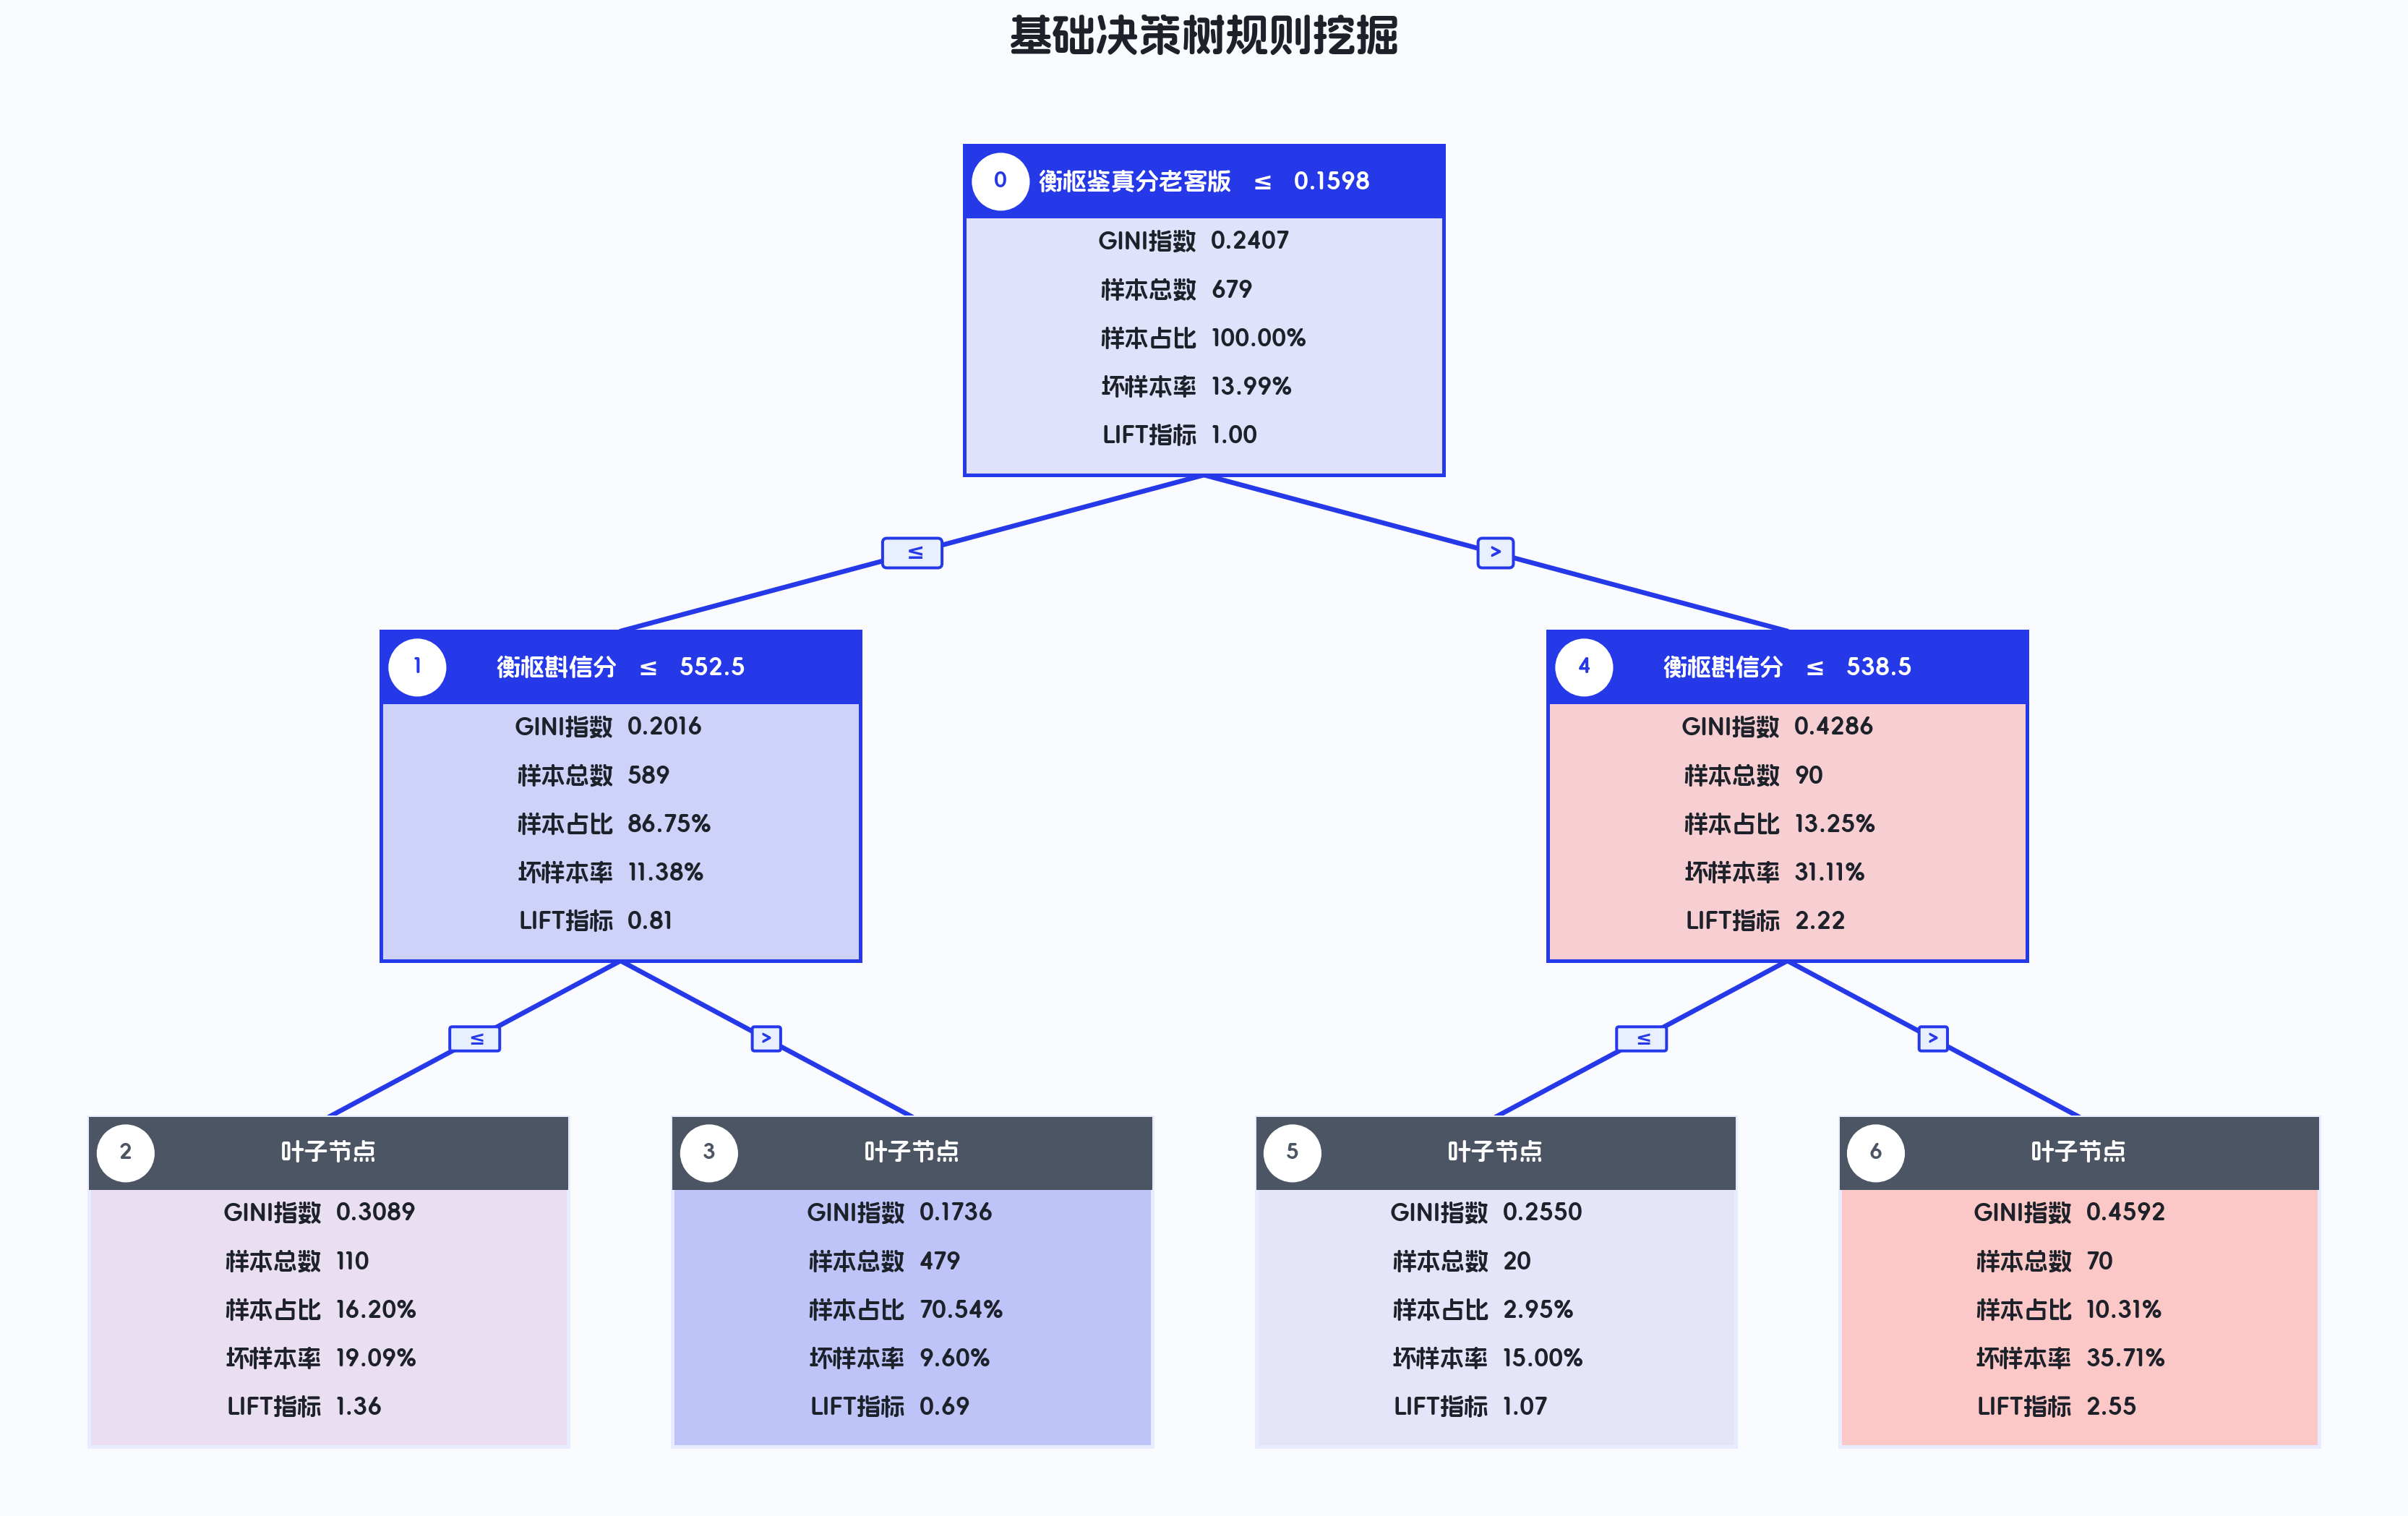

In [115]:
from hscredit.core.viz import plot_tree

fig = plot_tree(
    ext,
    backend="matplotlib",
    save="model_report/manual_tree_base.png",
    title="基础决策树规则挖掘",
)


也可以直接使用 `ManualTreeExtractor.plot()`：


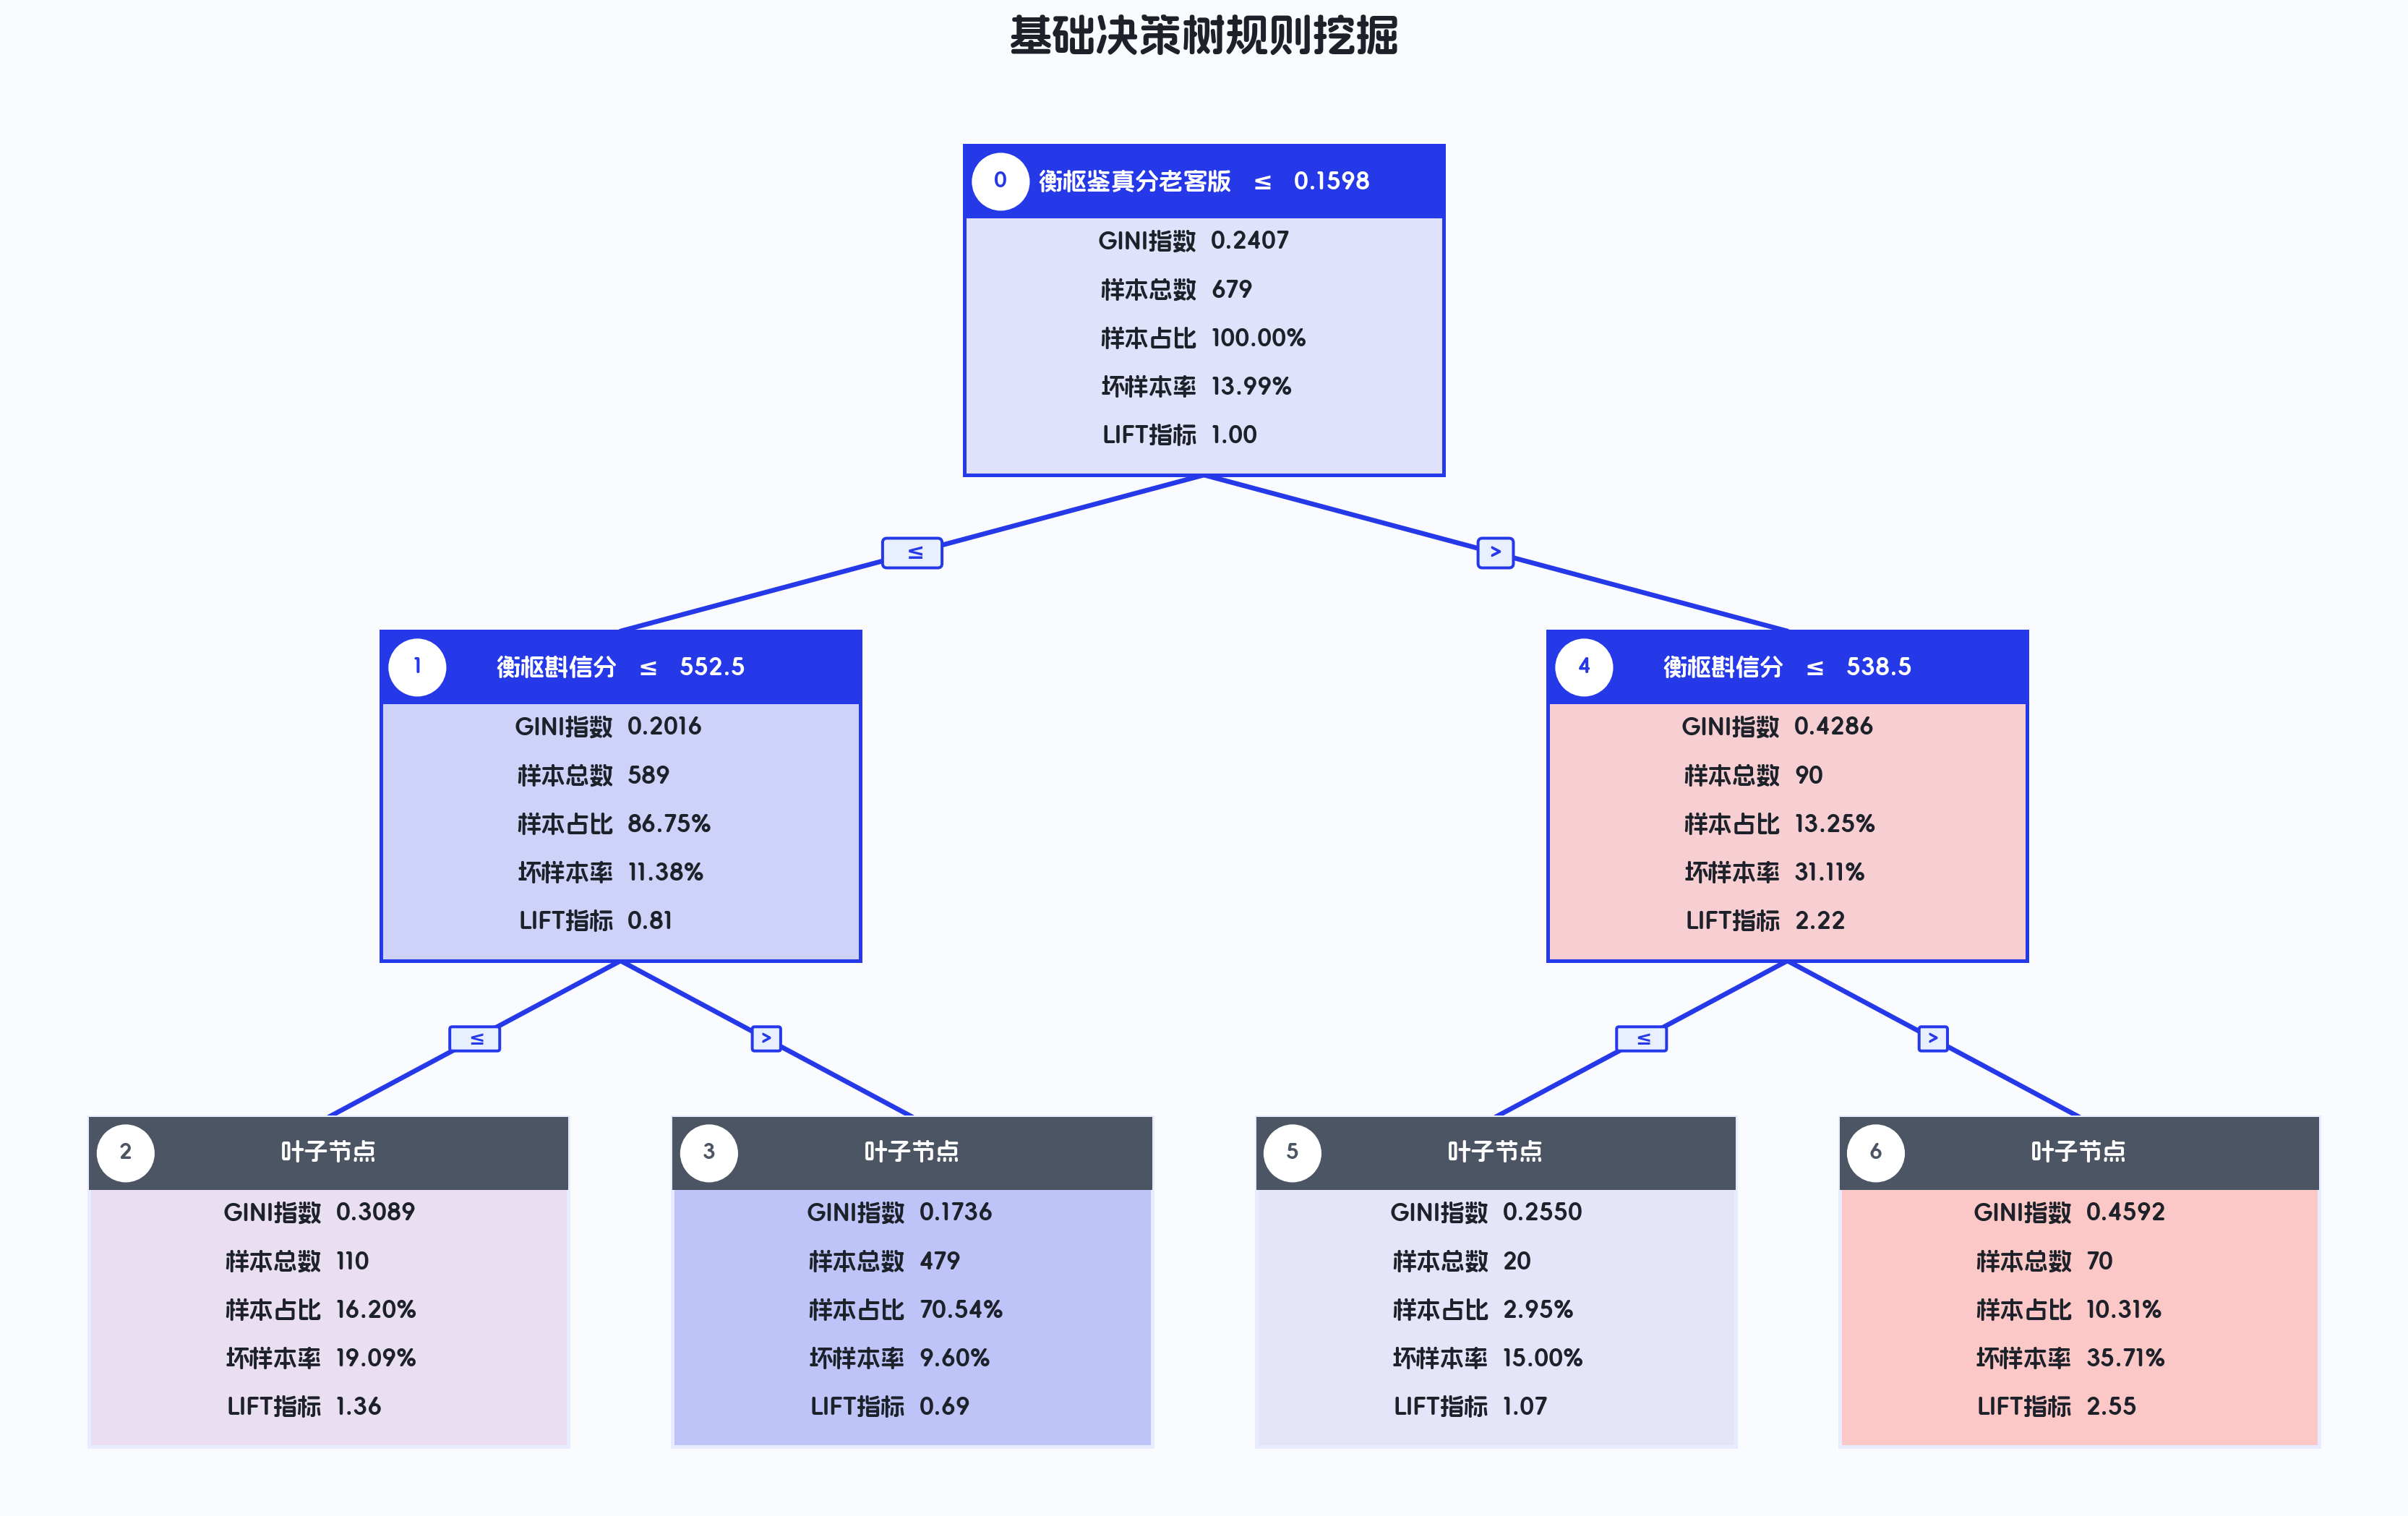

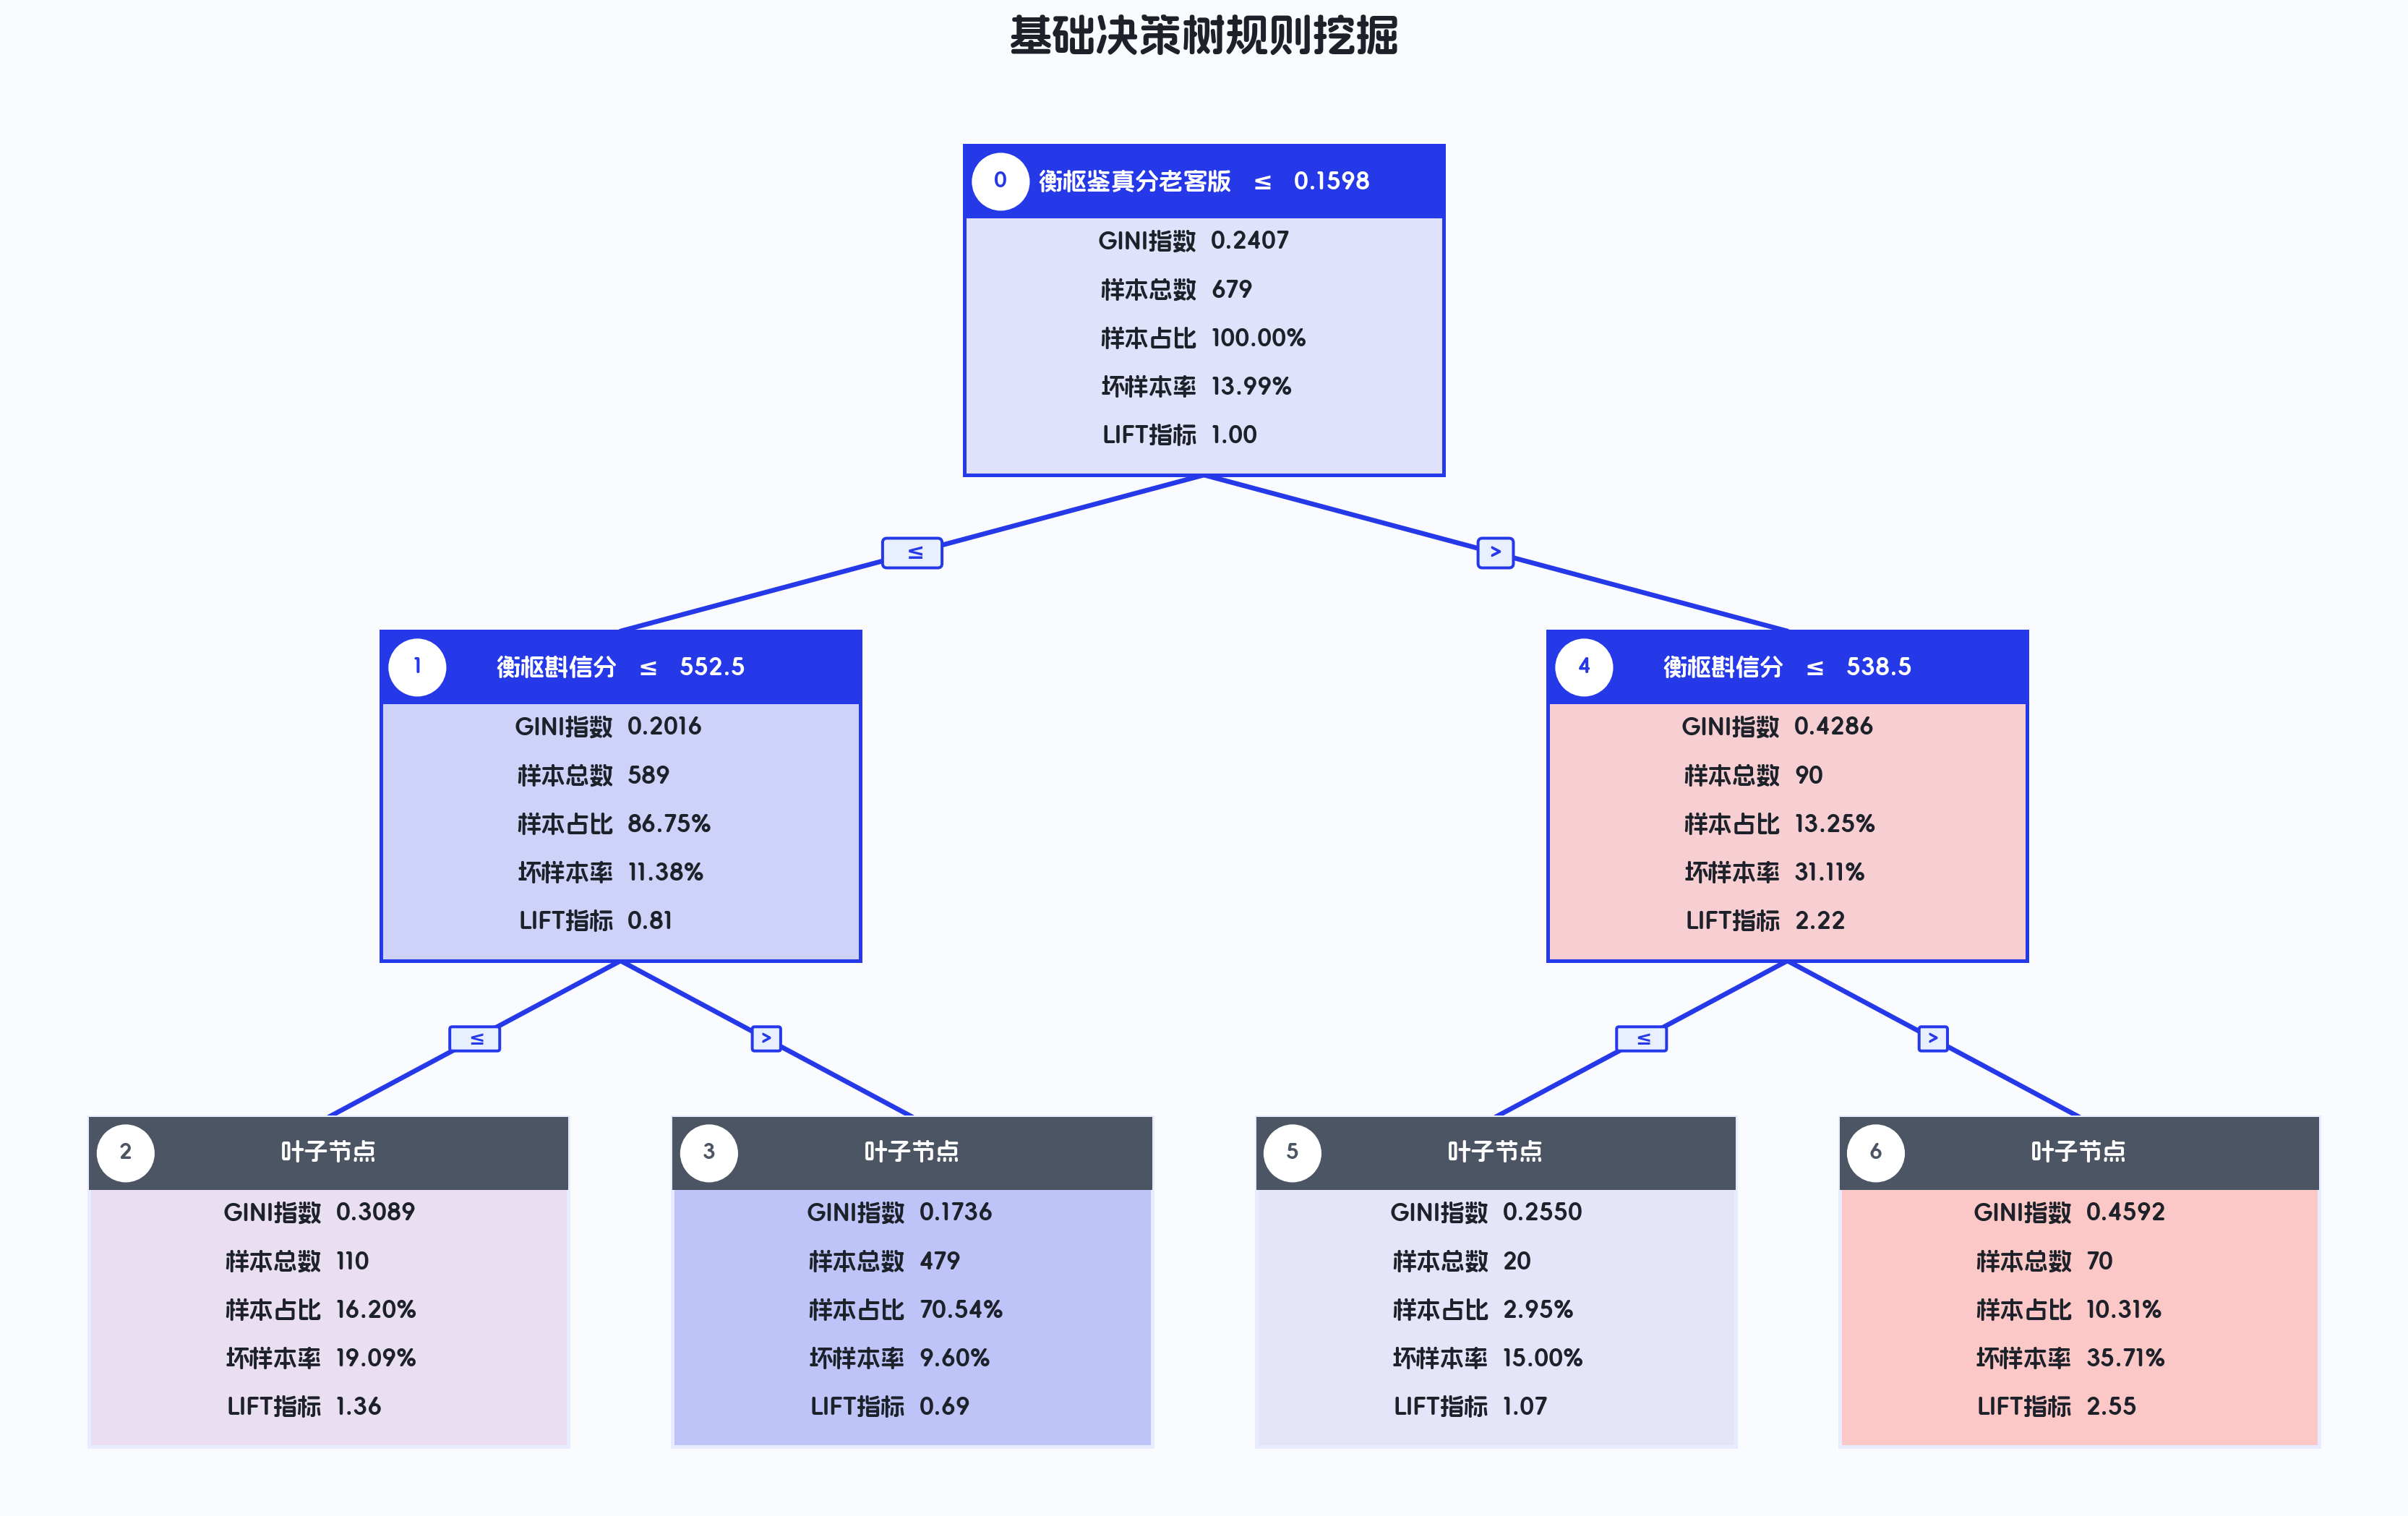

In [116]:
ext.plot(
    backend="matplotlib",
    save="model_report/manual_tree_base.png",
    title="基础决策树规则挖掘",
)


图上的每个节点都是一张卡片，通常包含：

- 节点编号。
- 分裂条件或“叶子节点”。
- GINI 指数。
- 样本总数。
- 样本占比。
- 坏样本率。
- LIFT 指标。

颜色按风险语义变化：低风险偏浅蓝，高风险偏浅红。人工调整过的节点会用副主题色标记，便于在汇报时说明“这里是业务专家干预后的节点”。

这张图非常适合策略讨论。大家不需要看代码，只需要沿着树从上往下读：



## 六、三种画图方式：预览、交互、报告

`hscredit.core.viz.tree_plots` 提供三种后端：


In [117]:
from hscredit.core.viz import (
    plot_tree_matplotlib,
    plot_tree_pyecharts,
    plot_tree_graphviz,
)


### 1. matplotlib：最快速的本地预览


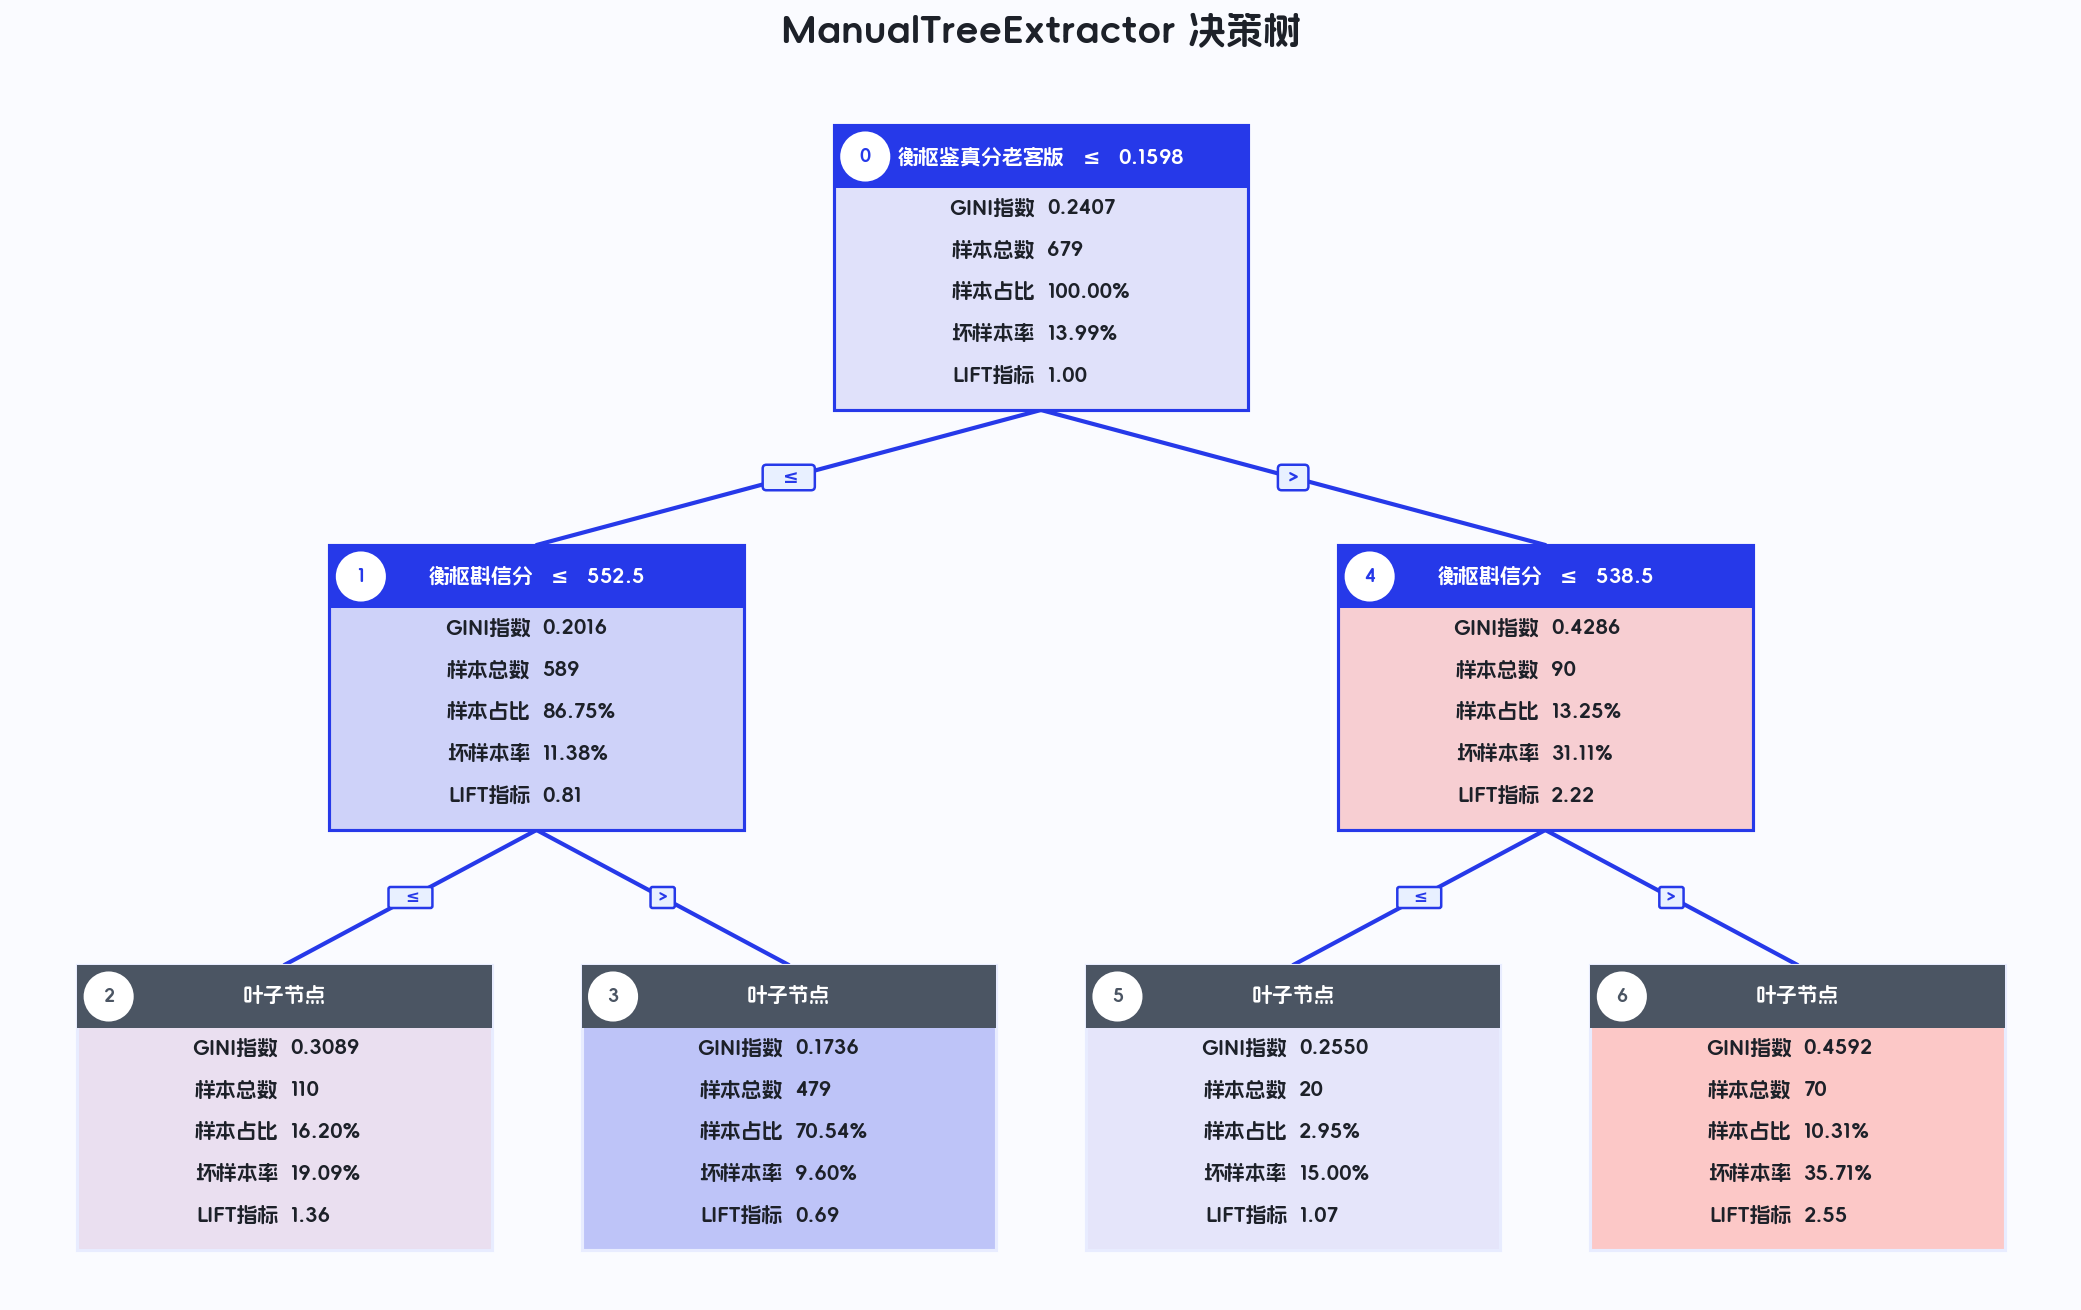

In [118]:
fig = plot_tree_matplotlib(
    ext,
    figsize=(18, 12),
    dpi=150,
    save="model_report/tree_matplotlib.png",
    title="ManualTreeExtractor 决策树",
)


适合 Notebook、脚本运行和快速检查。

### 2. pyecharts：交互式 HTML


In [119]:
chart = plot_tree_pyecharts(
    ext,
    title="交互式决策树规则图",
    save="model_report/tree_interactive.html",
    width="1400px",
    height="900px",
)


适合业务评审会。HTML 可以缩放、拖动、查看 tooltip，对较大的树更友好。

### 3. graphviz：高质量矢量图


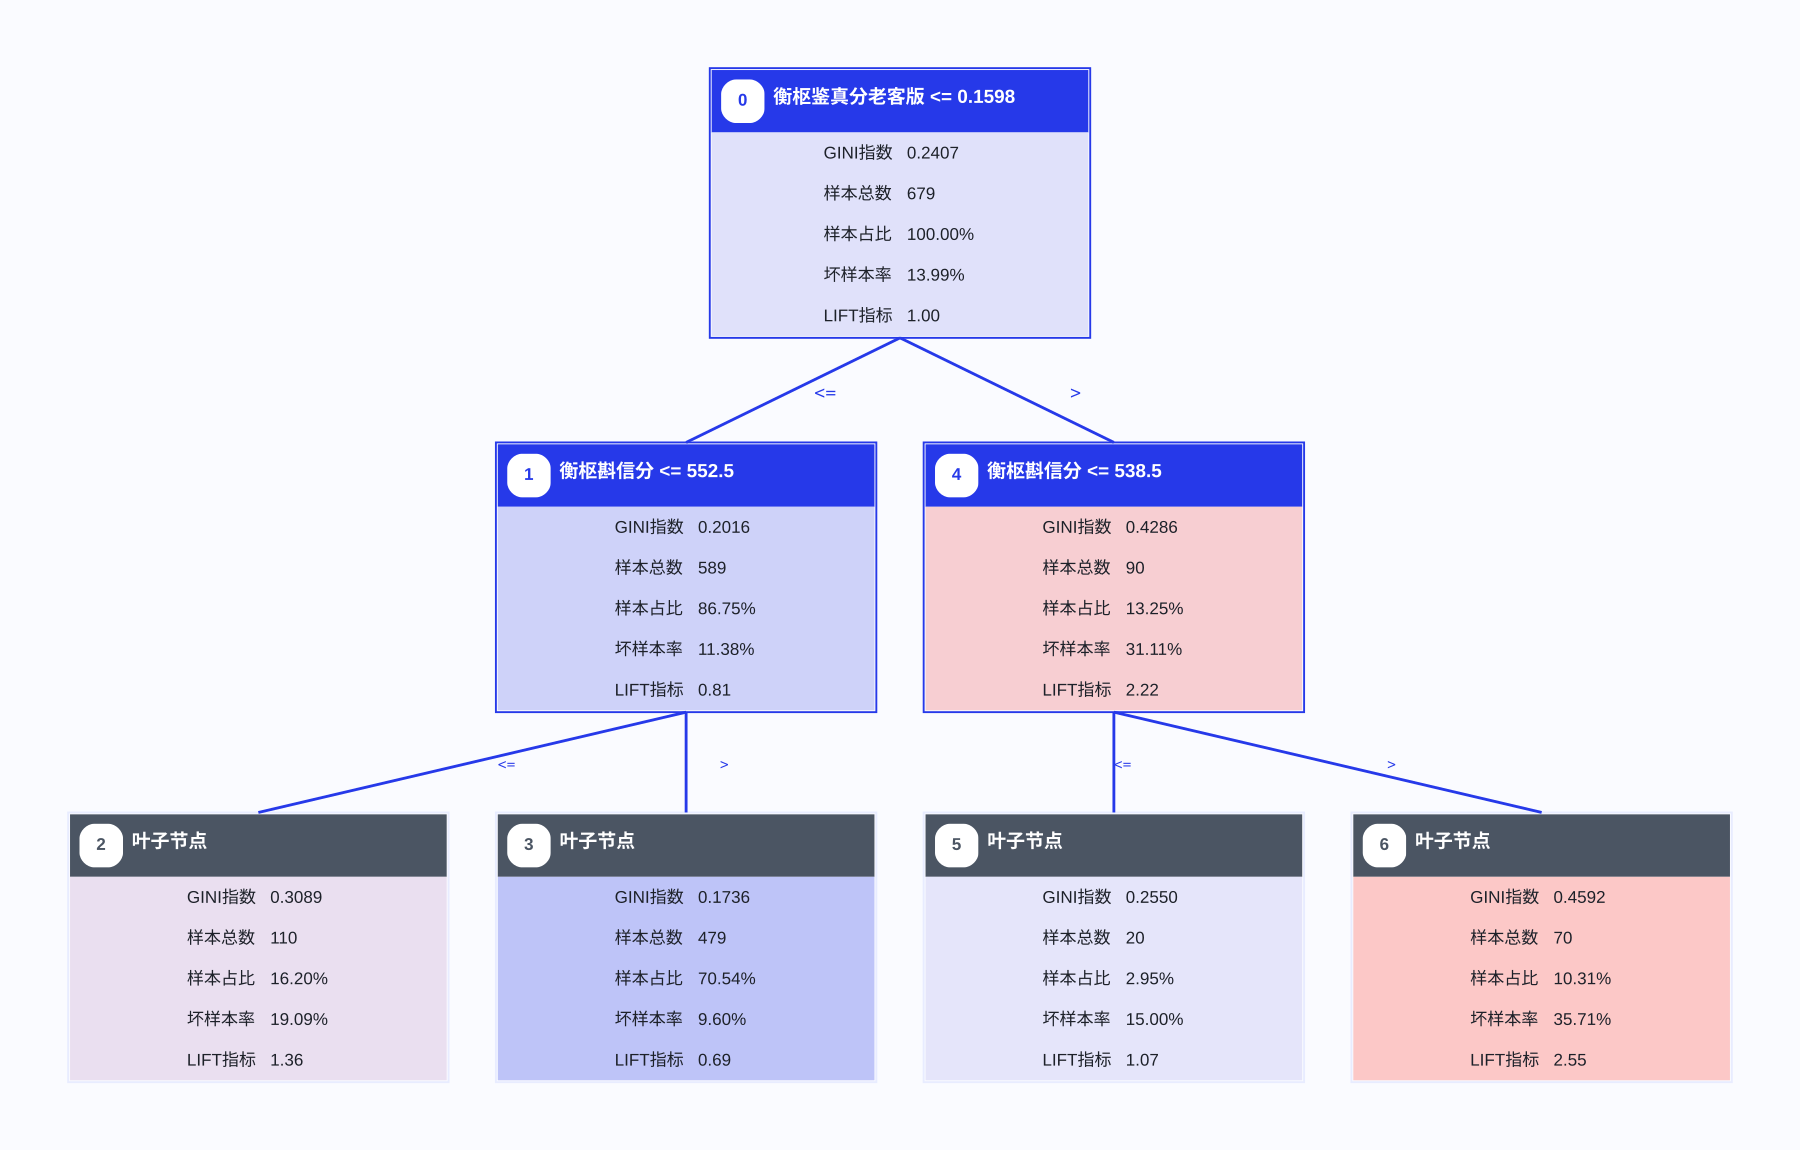

In [120]:
src = plot_tree_graphviz(
    ext,
    save="model_report/tree_graphviz.png",
    figsize=(12, 8),
    dpi=150,
)
src


适合嵌入正式报告、策略文档或归档材料。`save` 的后缀决定输出格式，例如 `.png`、`.pdf`、`.svg`。

### 4. 统一入口：plot_tree

如果你不想记多个函数，直接用：


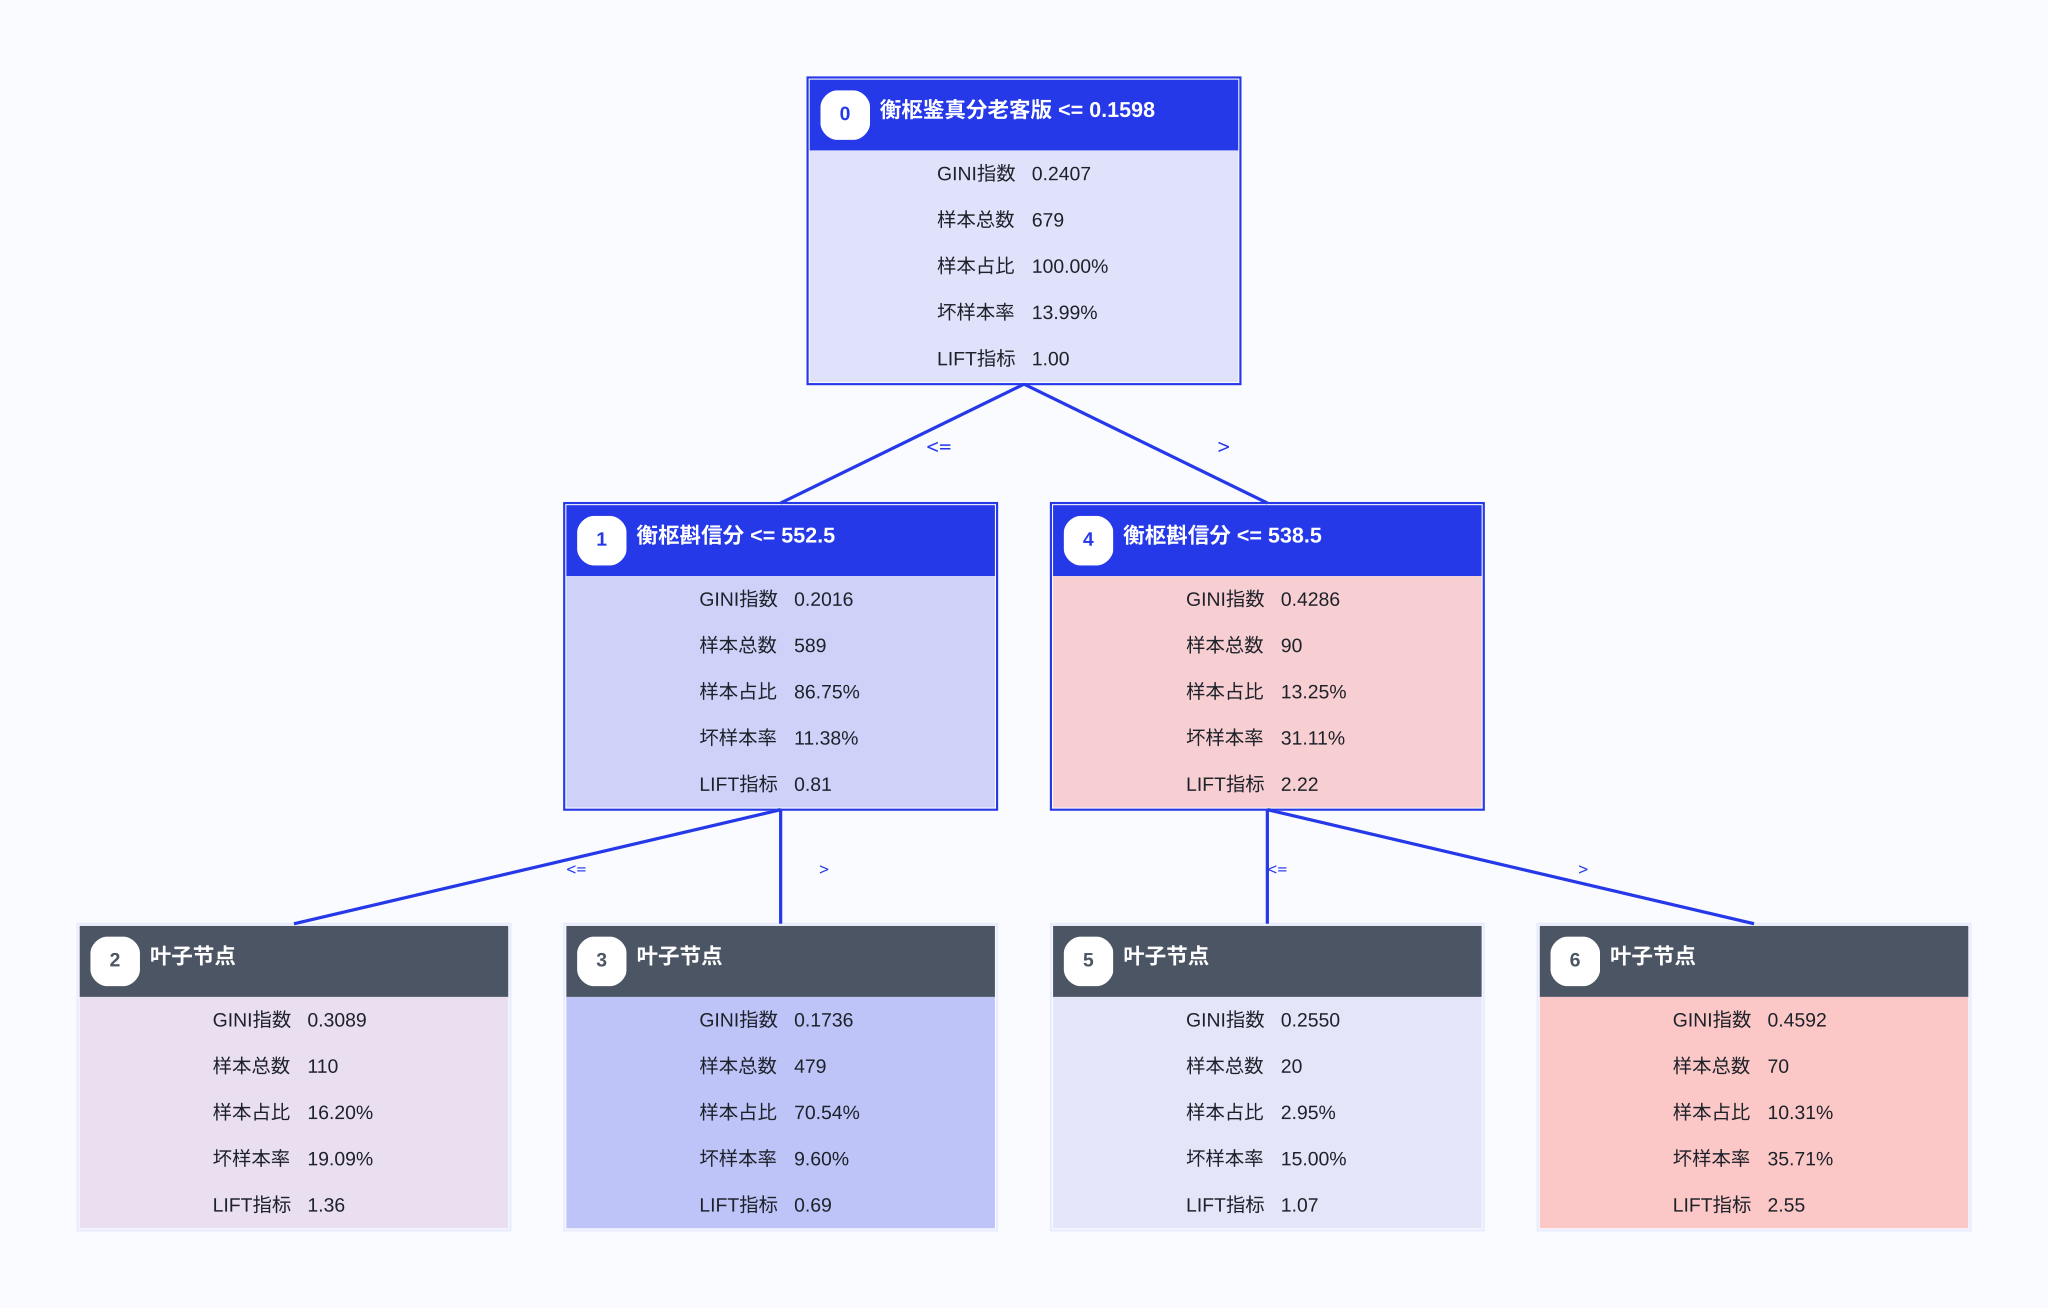

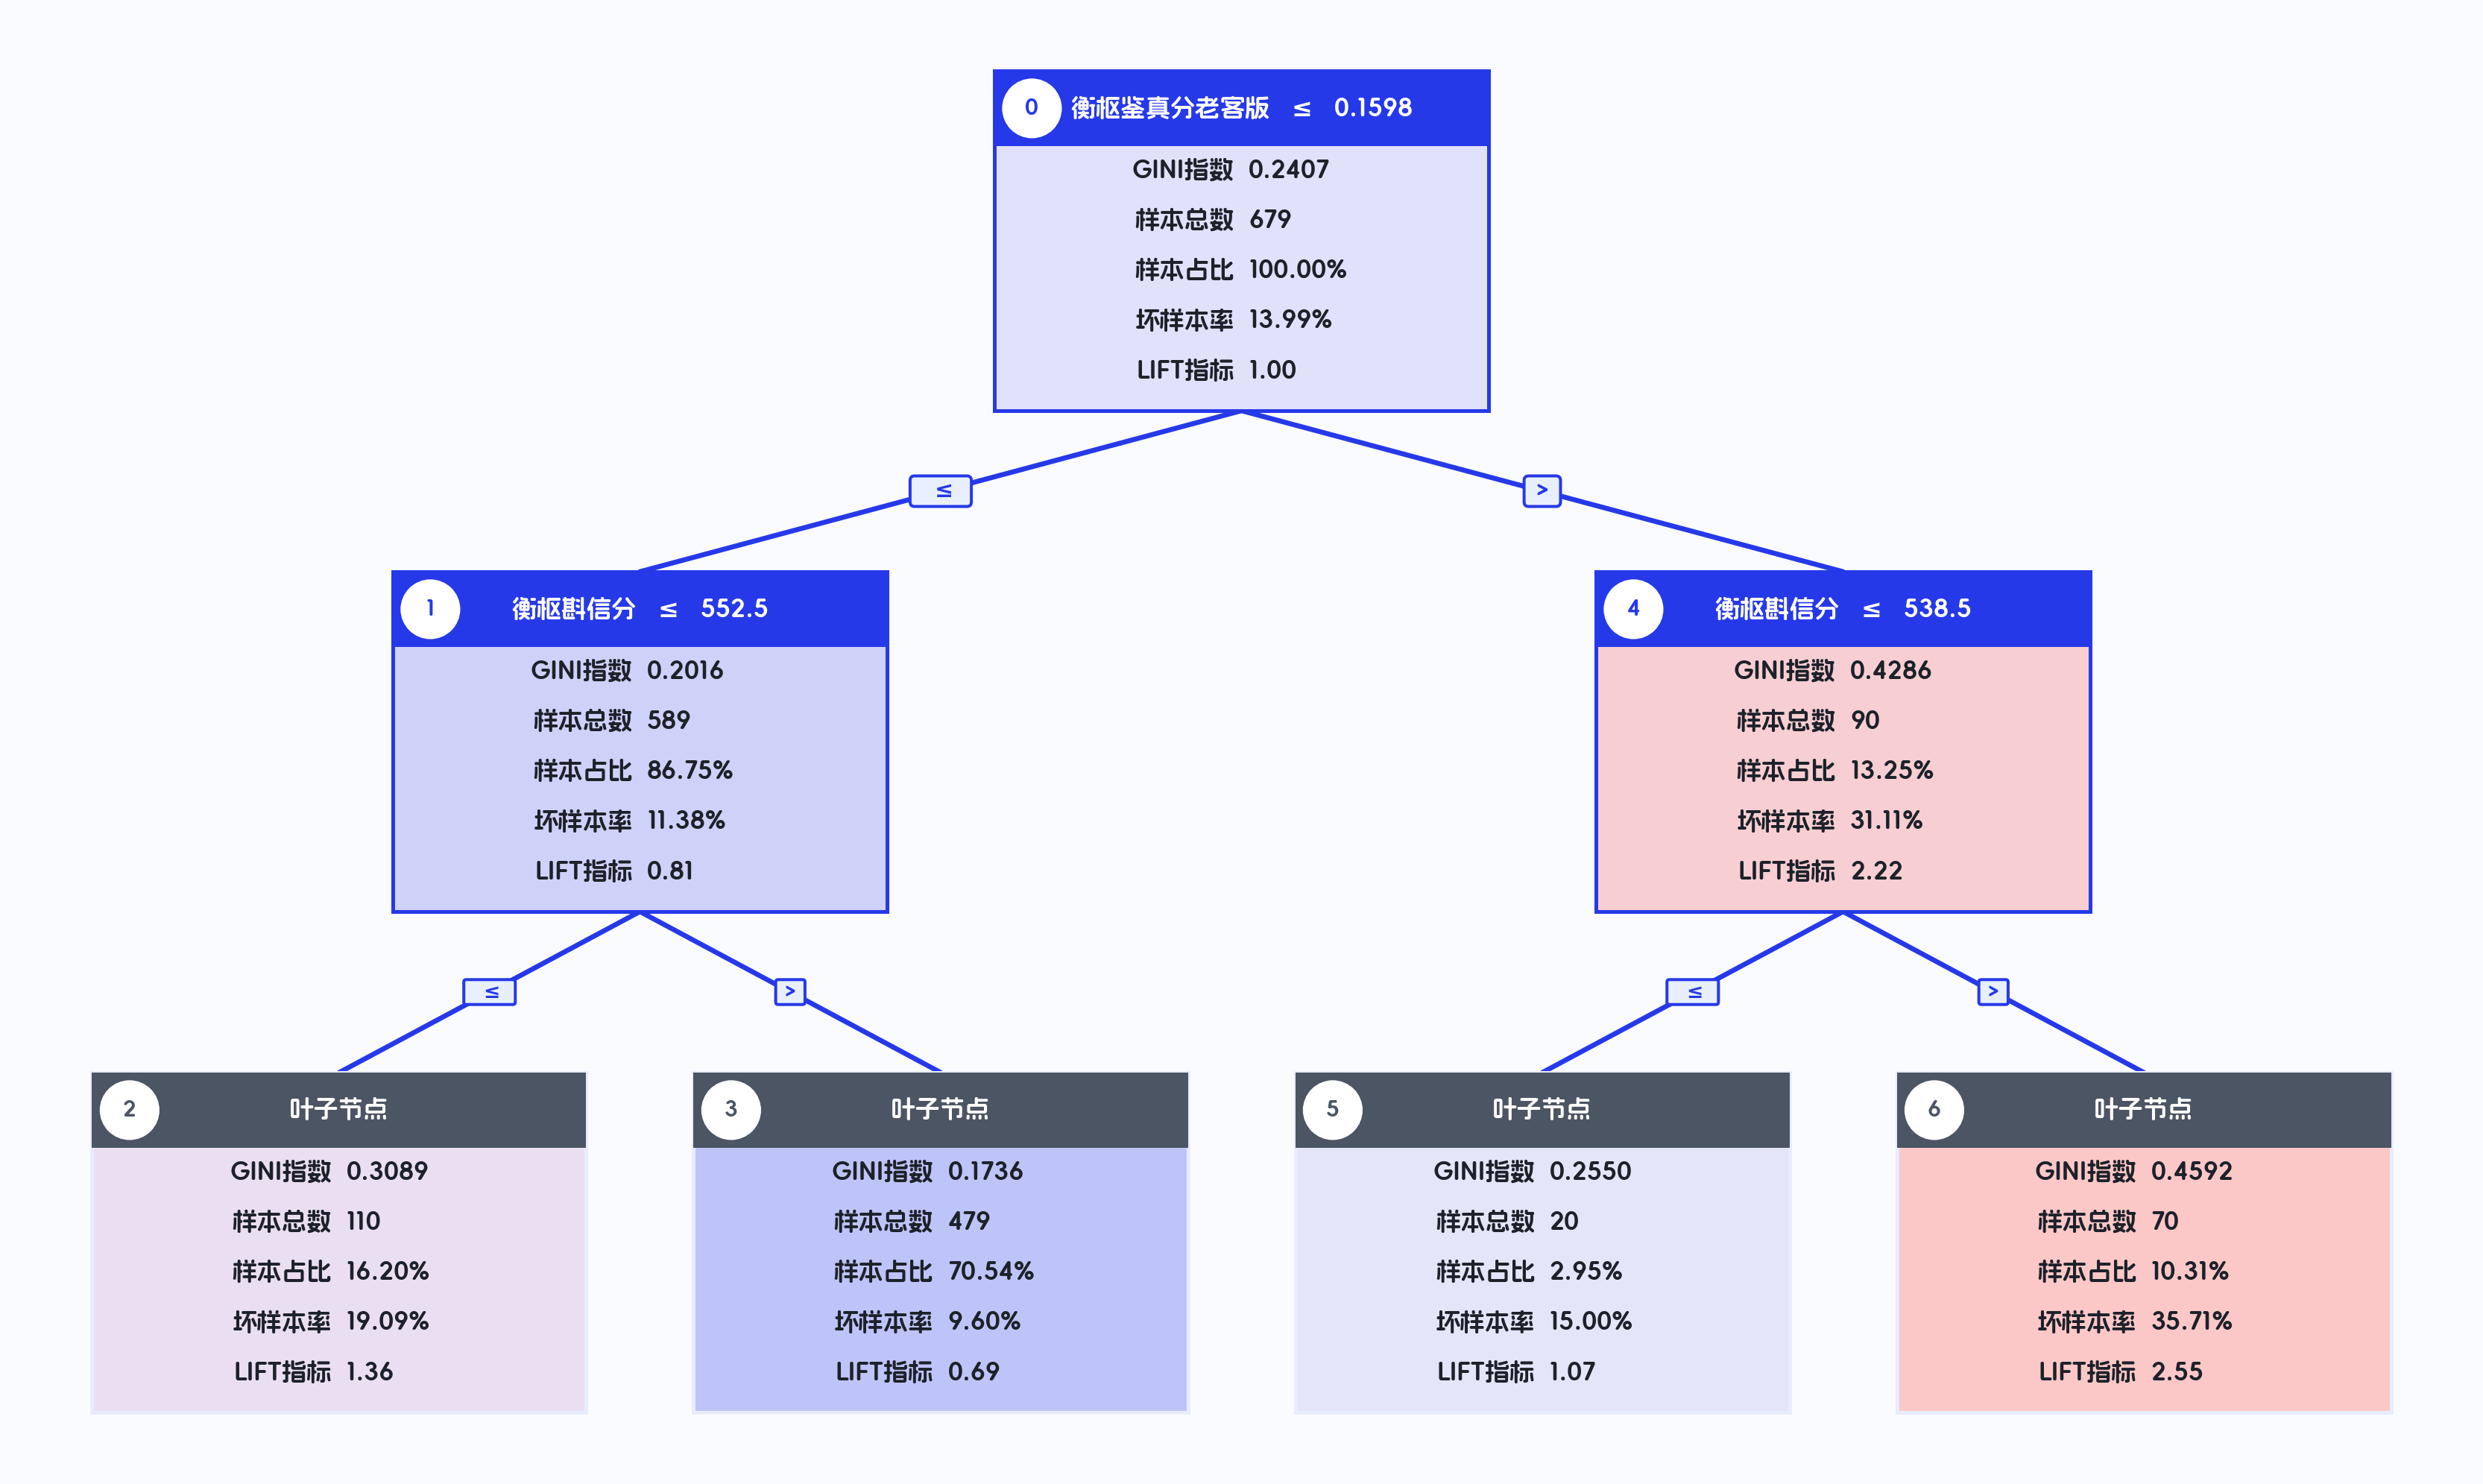

In [121]:
plot_tree(ext, backend="matplotlib", save="model_report/tree.png")
plot_tree(ext, backend="pyecharts", save="model_report/tree.html")
plot_tree(ext, backend="graphviz", save="model_report/tree.pdf")


`plot_tree` 不仅支持 `ManualTreeExtractor`，也支持 `DecisionTreeAnalyzer` 和 sklearn 的 `DecisionTreeClassifier`。如果传入 sklearn 原生树，建议指定 `feature_names`，否则图中可能显示 `特征[0]` 这类占位名：


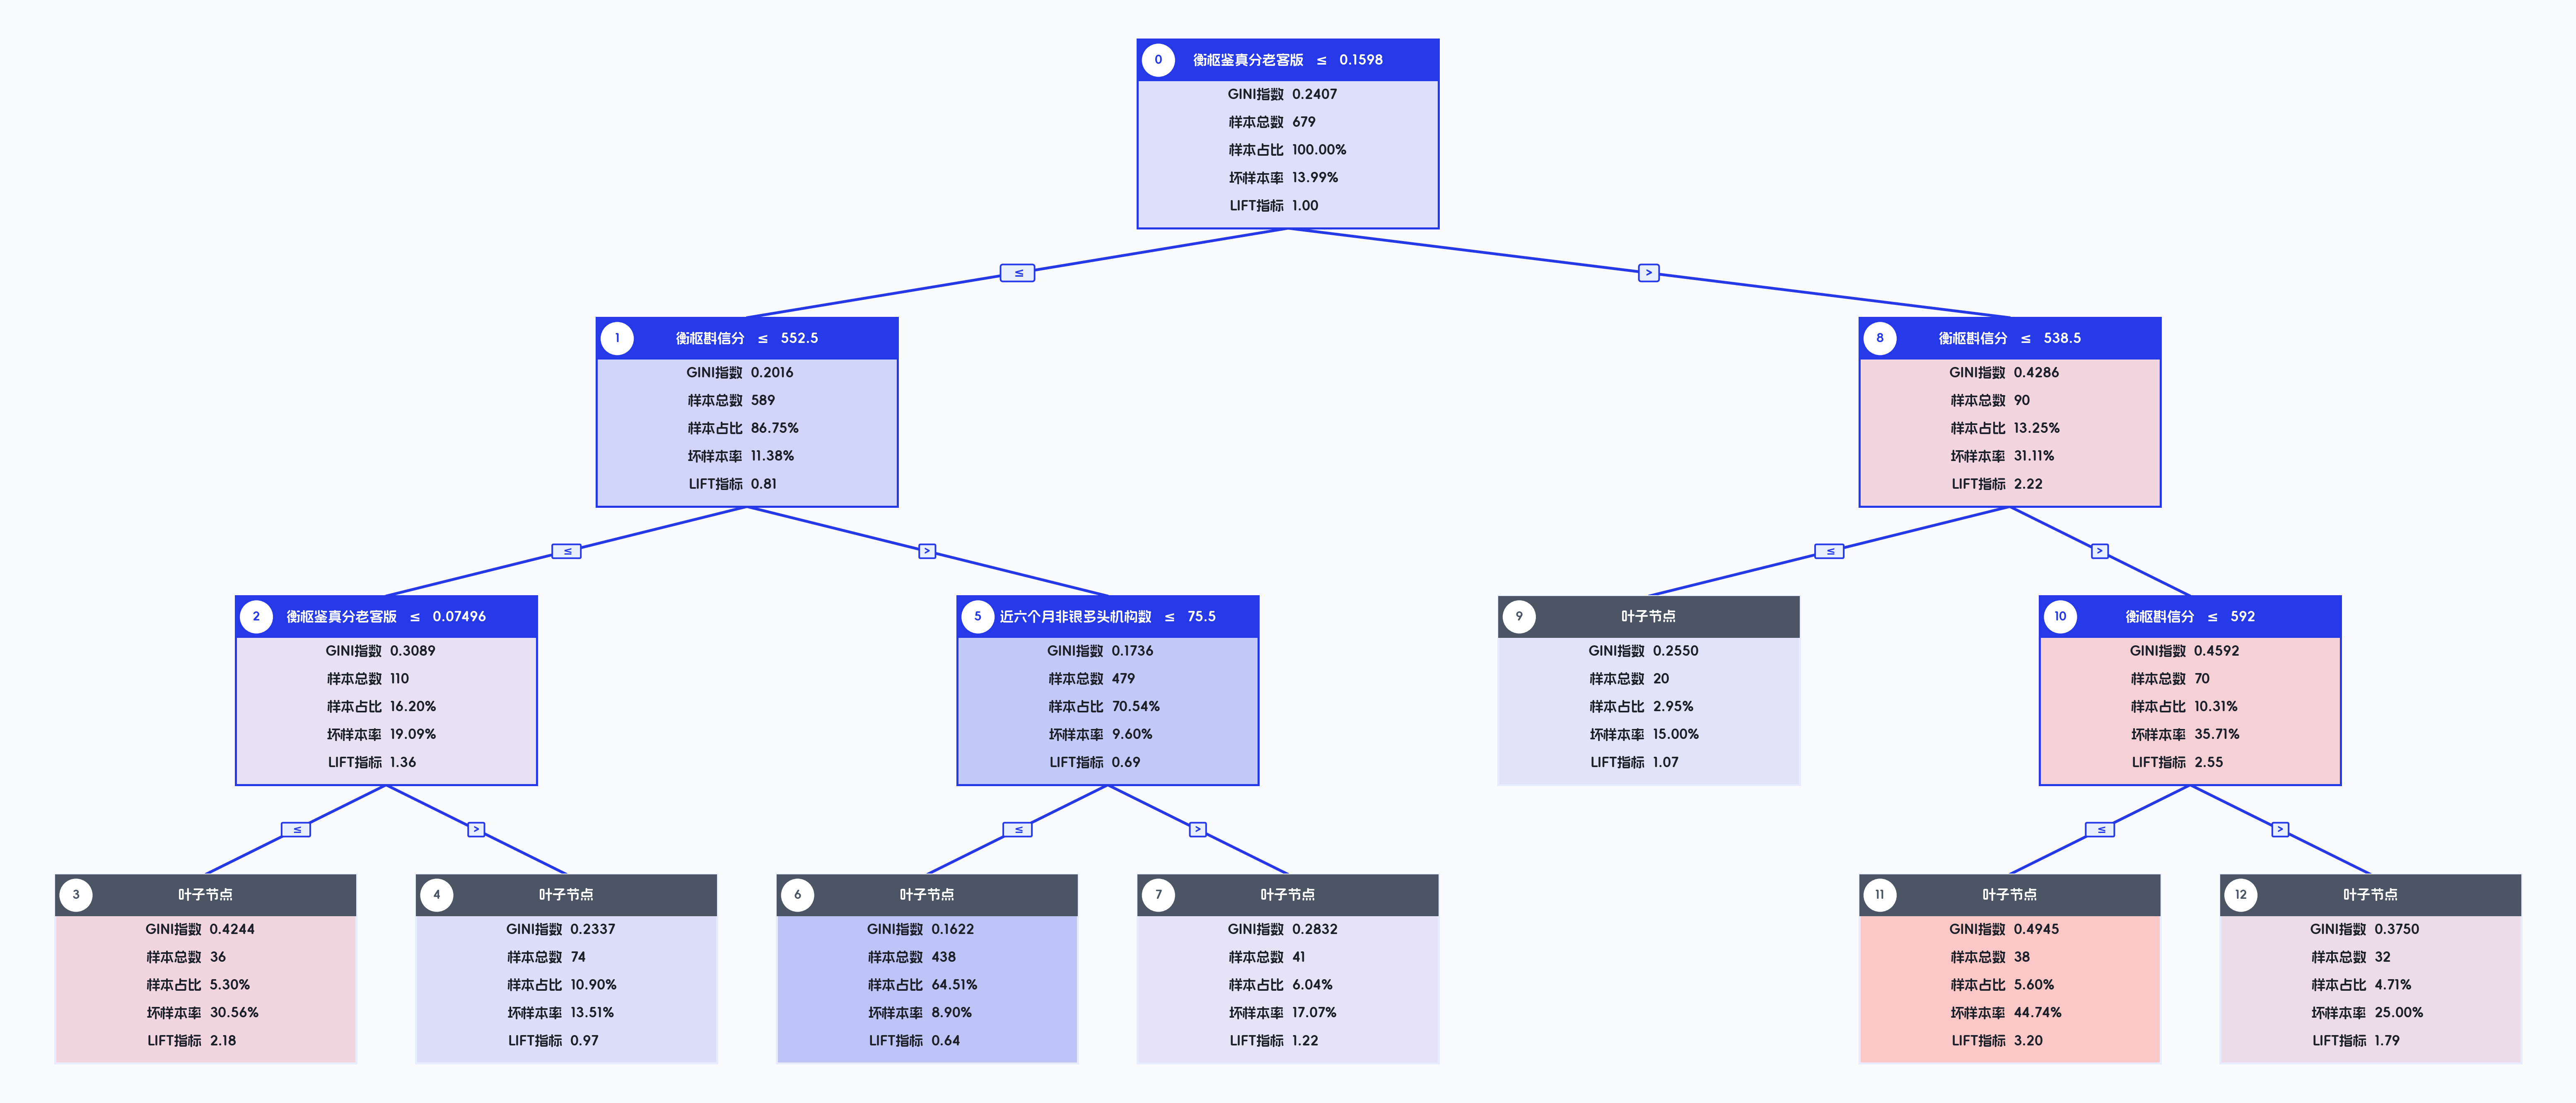

In [122]:
from sklearn.tree import DecisionTreeClassifier

sklearn_clf = DecisionTreeClassifier(max_depth=3, min_samples_split=50, min_samples_leaf=20, random_state=42)
sklearn_clf.fit(df_train[feature_list], df_train['FPD'])

sk_tree = plot_tree(
    sklearn_clf,
    backend="matplotlib",
    # feature_names=feature_list,
    save="model_report/sklearn_tree.png",
)


## 七、第三步：人工调整树结构，把业务经验注入规则

自动树训练完后，真正的策略分析才开始。

假设自动树在根节点没有选择 `衡枢鉴真分老客版`，或者它给出的切分点是 `587.4321`。从统计角度看这可能有效，但业务讨论时很难解释。策略人员可能更认可：



因为 600 分是一个更容易沟通、监控和上线的策略阈值。

这时可以用 `manual_split()` 手动替换根节点：


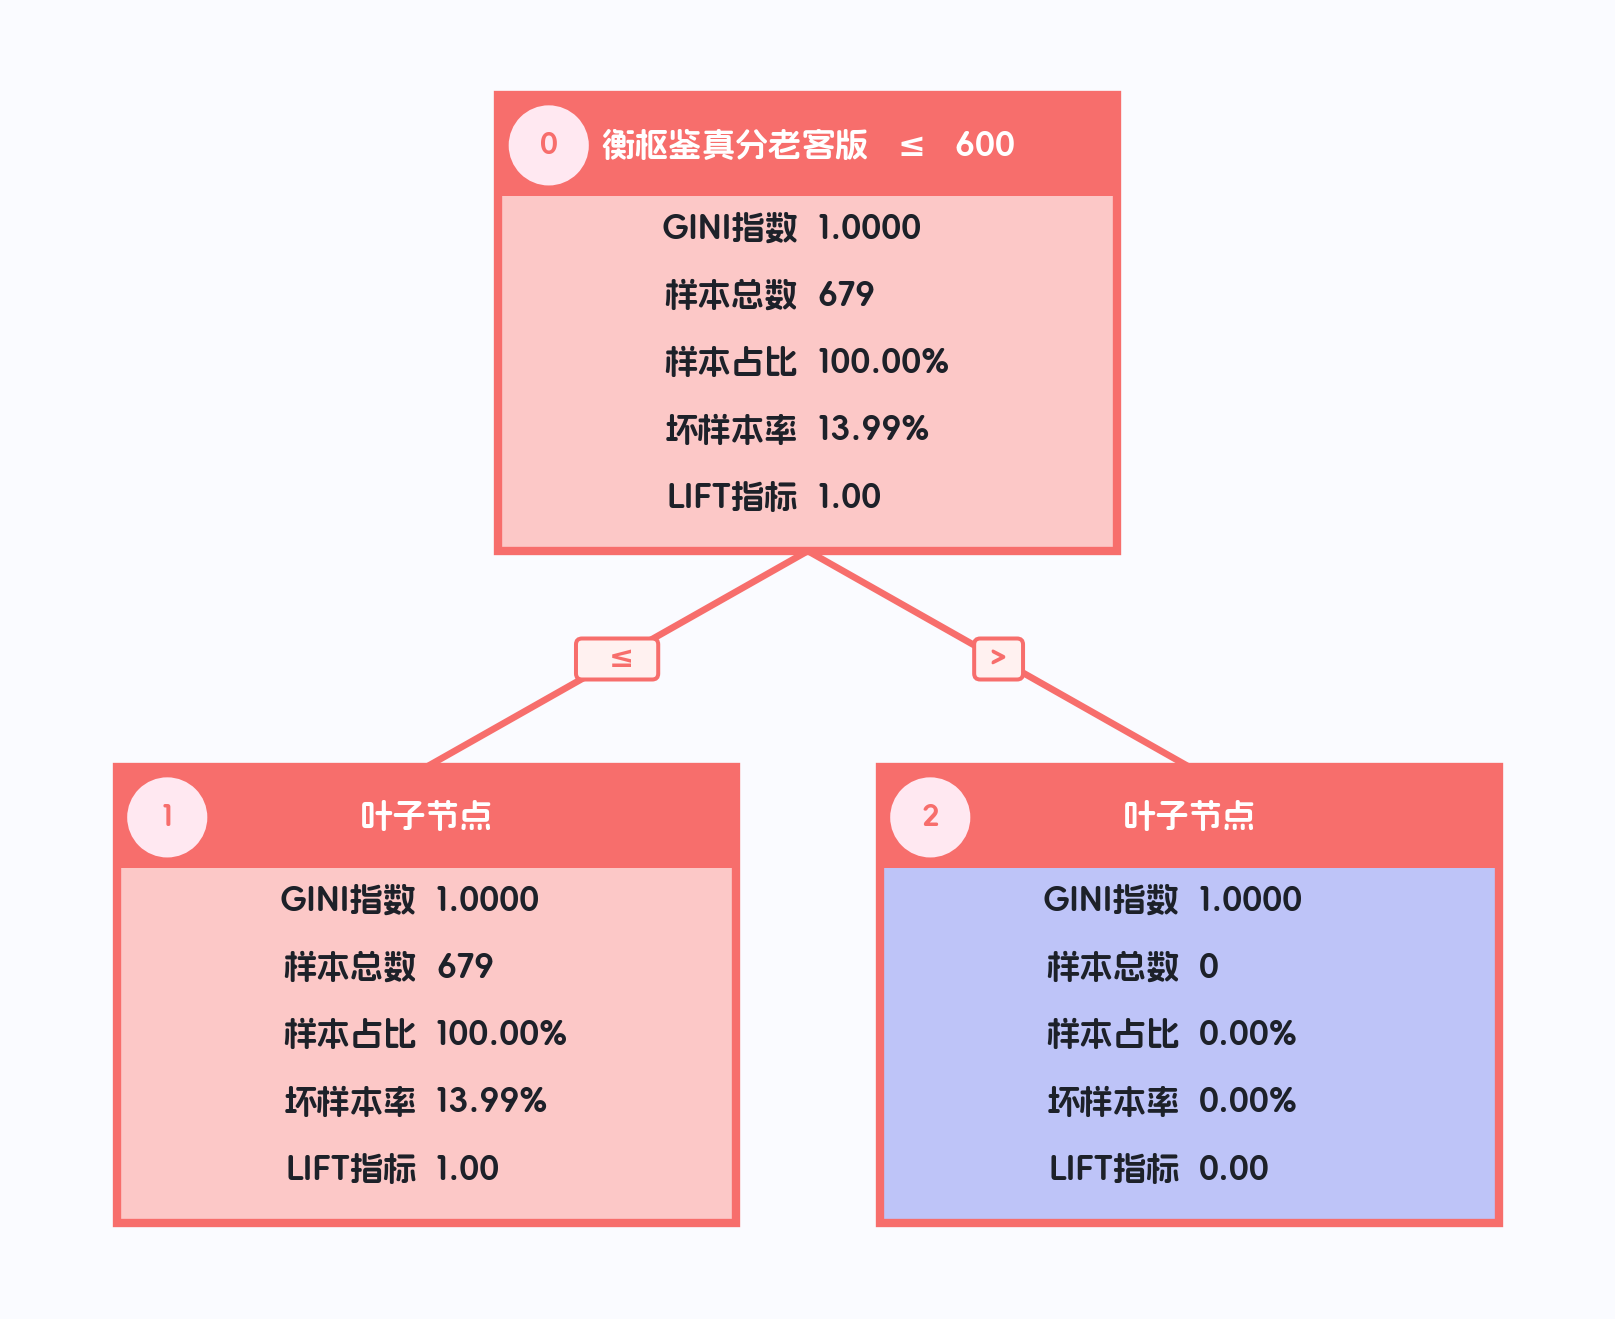

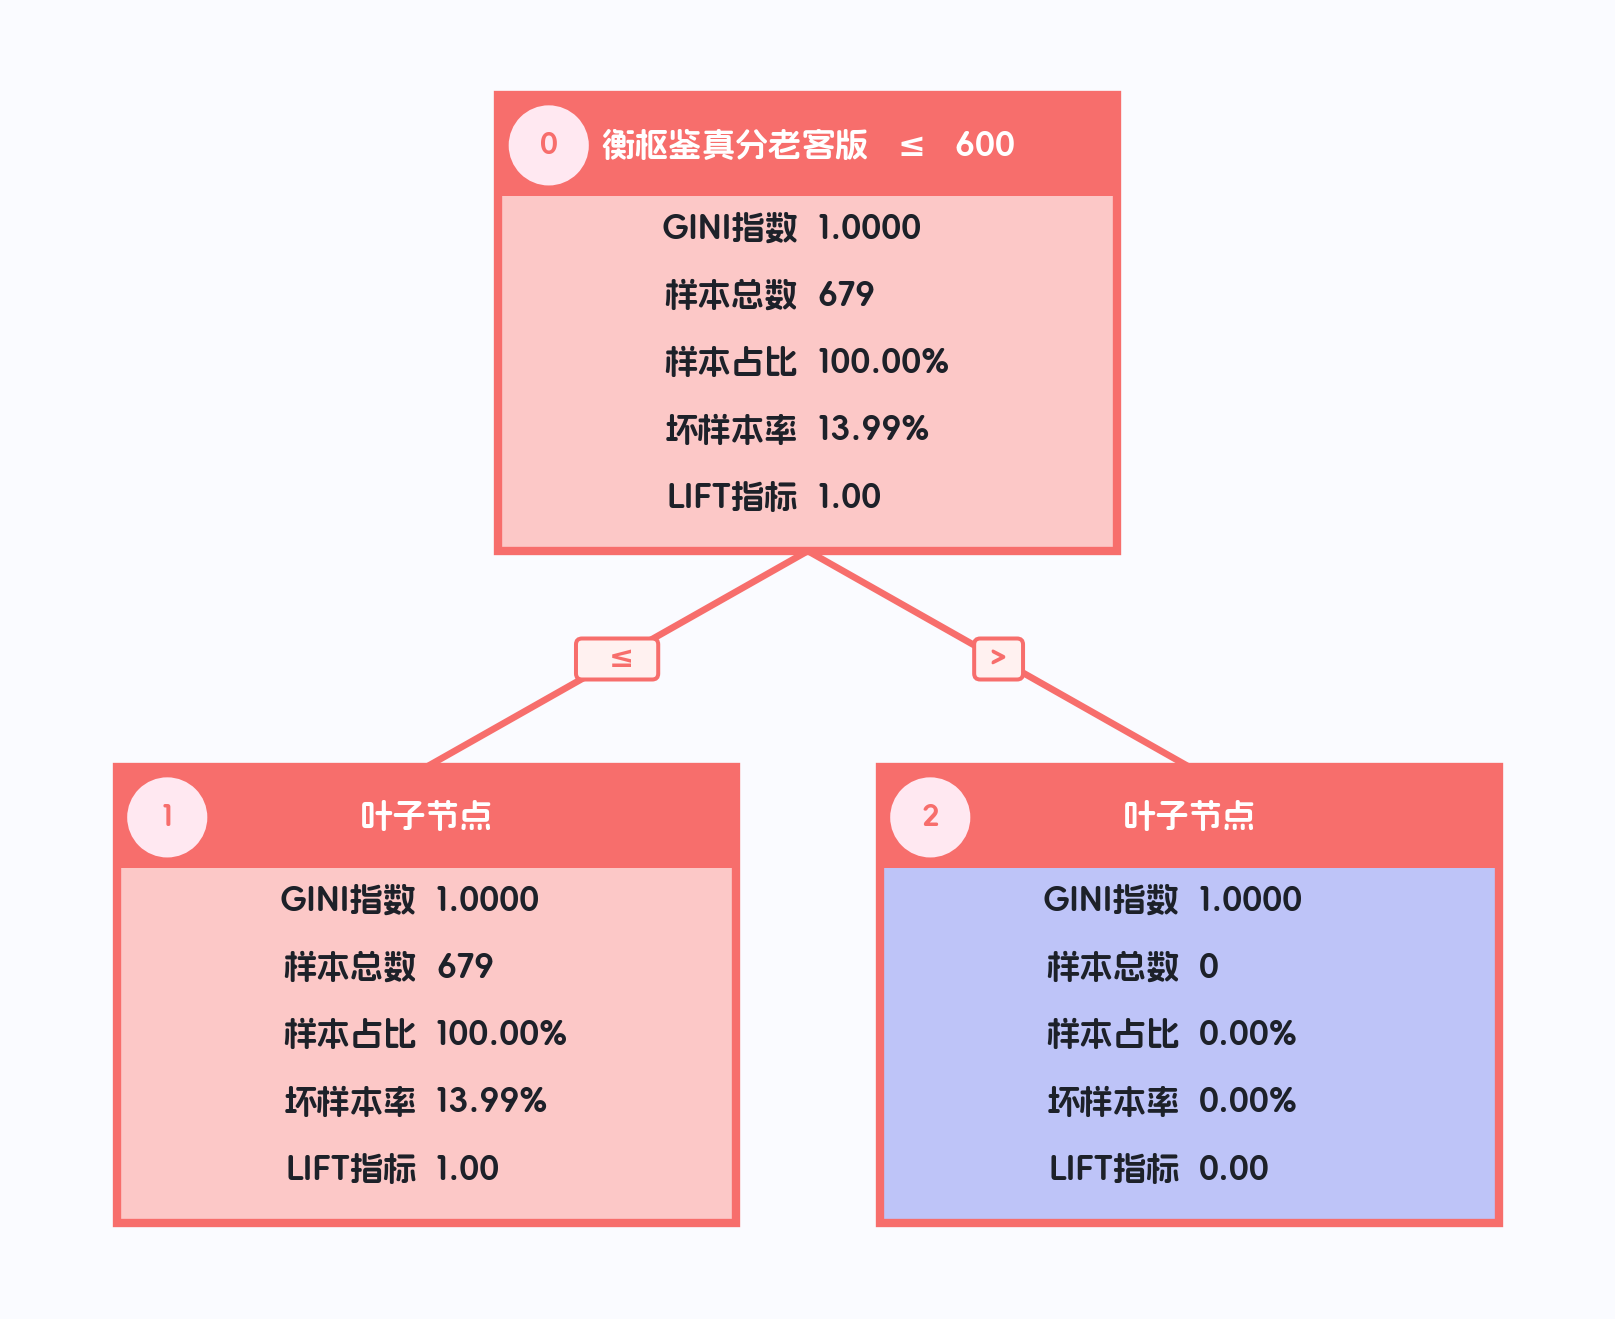

In [123]:
ext.manual_split(
    data=df_train,
    feature="衡枢鉴真分老客版",
    threshold=600,
    node=0,
)

ext.get_rule_table()
ext.plot(save="model_report/manual_split_score_600.png")


`node=0` 表示根节点。`ManualTreeExtractor` 会先删除该节点原来的子树，再按指定变量和阈值生成新的左右子节点。

这一步非常适合体现业务经验的价值：

- 模型告诉我们哪些变量有区分度。
- 业务告诉我们哪些阈值可解释、可运营、可上线。
- `ManualTreeExtractor` 把两者结合成一棵可以继续评估和绘图的树。

这不是简单“拍脑袋改规则”。每次人工调整后，`get_rule_table()` 都会重新用规则在数据上回算命中表现。业务经验如果真的有效，会体现在坏账率、LIFT、风险拒绝比上；如果只是主观偏好，数据也会立刻暴露出来。

## 八、人工分裂也可以自动找阈值

有时业务专家知道应该用哪个变量，但不确定阈值。

例如，我们认为某个节点下应该继续看 `近六个月非银多头机构数`，但不知道切 `3`、`5` 还是 `7` 更合适。这时可以把 `threshold` 设为 `None`：


In [124]:
ext.manual_split(
    data=df_train,
    feature="近六个月非银多头机构数",
    threshold=None,
    node=1,
)

ManualTreeExtractor(target='FPD', features=['衡枢鉴真分老客版', '近六个月非银多头机构数', '衡枢斟信分'], samples=679, leaves=3)


这表示：在指定节点 `node=1` 上，由系统用单变量决策树自动寻找该特征的最优切分点。

这个功能非常适合“半自动策略开发”：



在金融信贷里，这种方式往往比完全自动建树更可靠。业务人员可以避免模型选到不可解释或不可落地的变量，同时又不用完全手工试阈值。

## 九、多轮链式分裂：构建一棵业务规则树

`manual_split()` 支持链式调用，也支持对不同节点连续分裂。

例如我们希望构建这样一棵策略树：

1. 根节点先看 `衡枢鉴真分老客版 <= 600`。
2. 低分客群继续看 `近六个月非银多头机构数 > 3`。
3. 另一个节点继续看 `衡枢斟信分 <= 50`。

可以这样写：


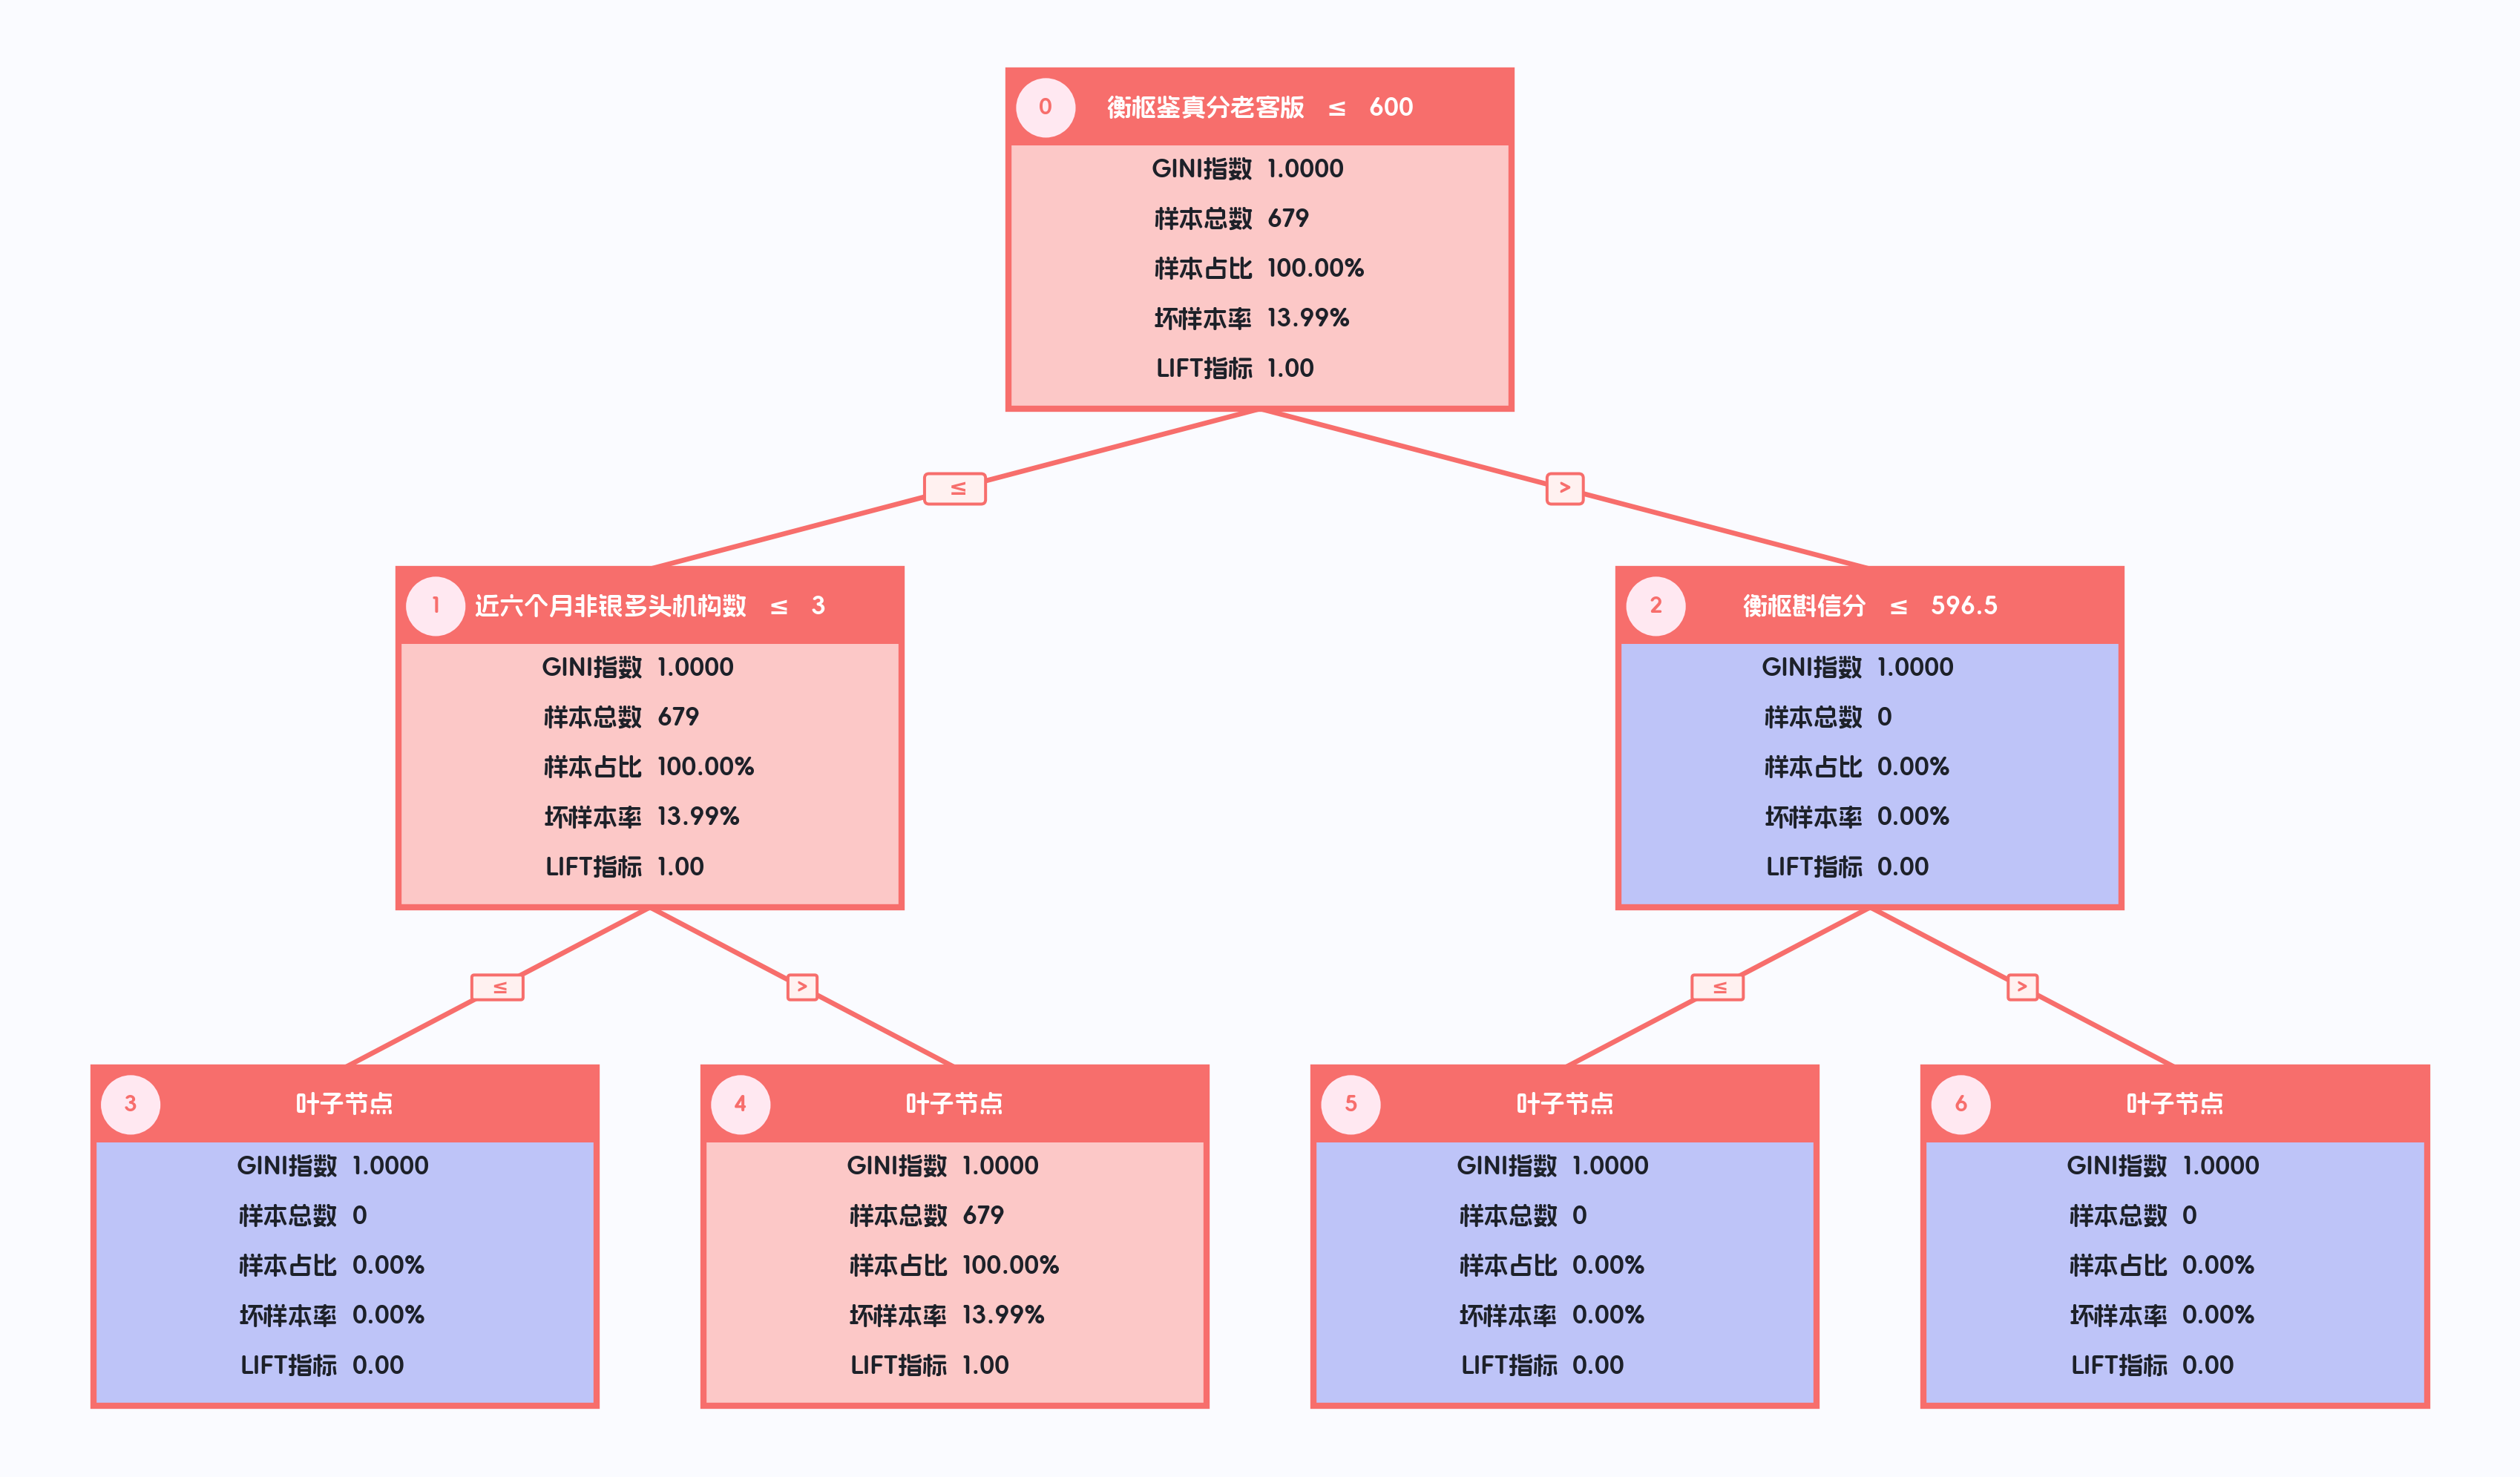

In [125]:
ext_chain = ManualTreeExtractor(
    target=target,
    max_depth=4,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42,
)

ext_chain.fit(df_train, features=feature_list)

ext_chain.manual_split(
    data=df_train,
    feature="衡枢鉴真分老客版",
    threshold=600,
    node=0,
)

ext_chain.manual_split(
    data=df_train,
    feature="近六个月非银多头机构数",
    threshold=3,
    node=1,
)

ext_chain.manual_split(
    data=df_train,
    feature="衡枢斟信分",
    threshold=None,
    node=2,
)

rule_table = ext_chain.get_rule_table()
fig = ext_chain.plot(save="model_report/manual_tree_chain.png")


这段代码表达的是一个非常典型的信贷策略思路：

- 先按主风险评分分层。
- 再在不同风险层内使用不同变量。
- 低分层更关注多头压力。
- 高分层再看补充风险信号。

这比单条规则更像真实策略。真实授信策略往往不是“一刀切”，而是分层分群：不同客群用不同变量解释，不同节点使用不同策略动作。

## 十、删除子树：把过拟合节点剪掉

如果某个节点样本量太小、坏账率不稳定，或者业务认为该分裂不应落地，可以用 `delete_node()` 删除该节点及其子树。


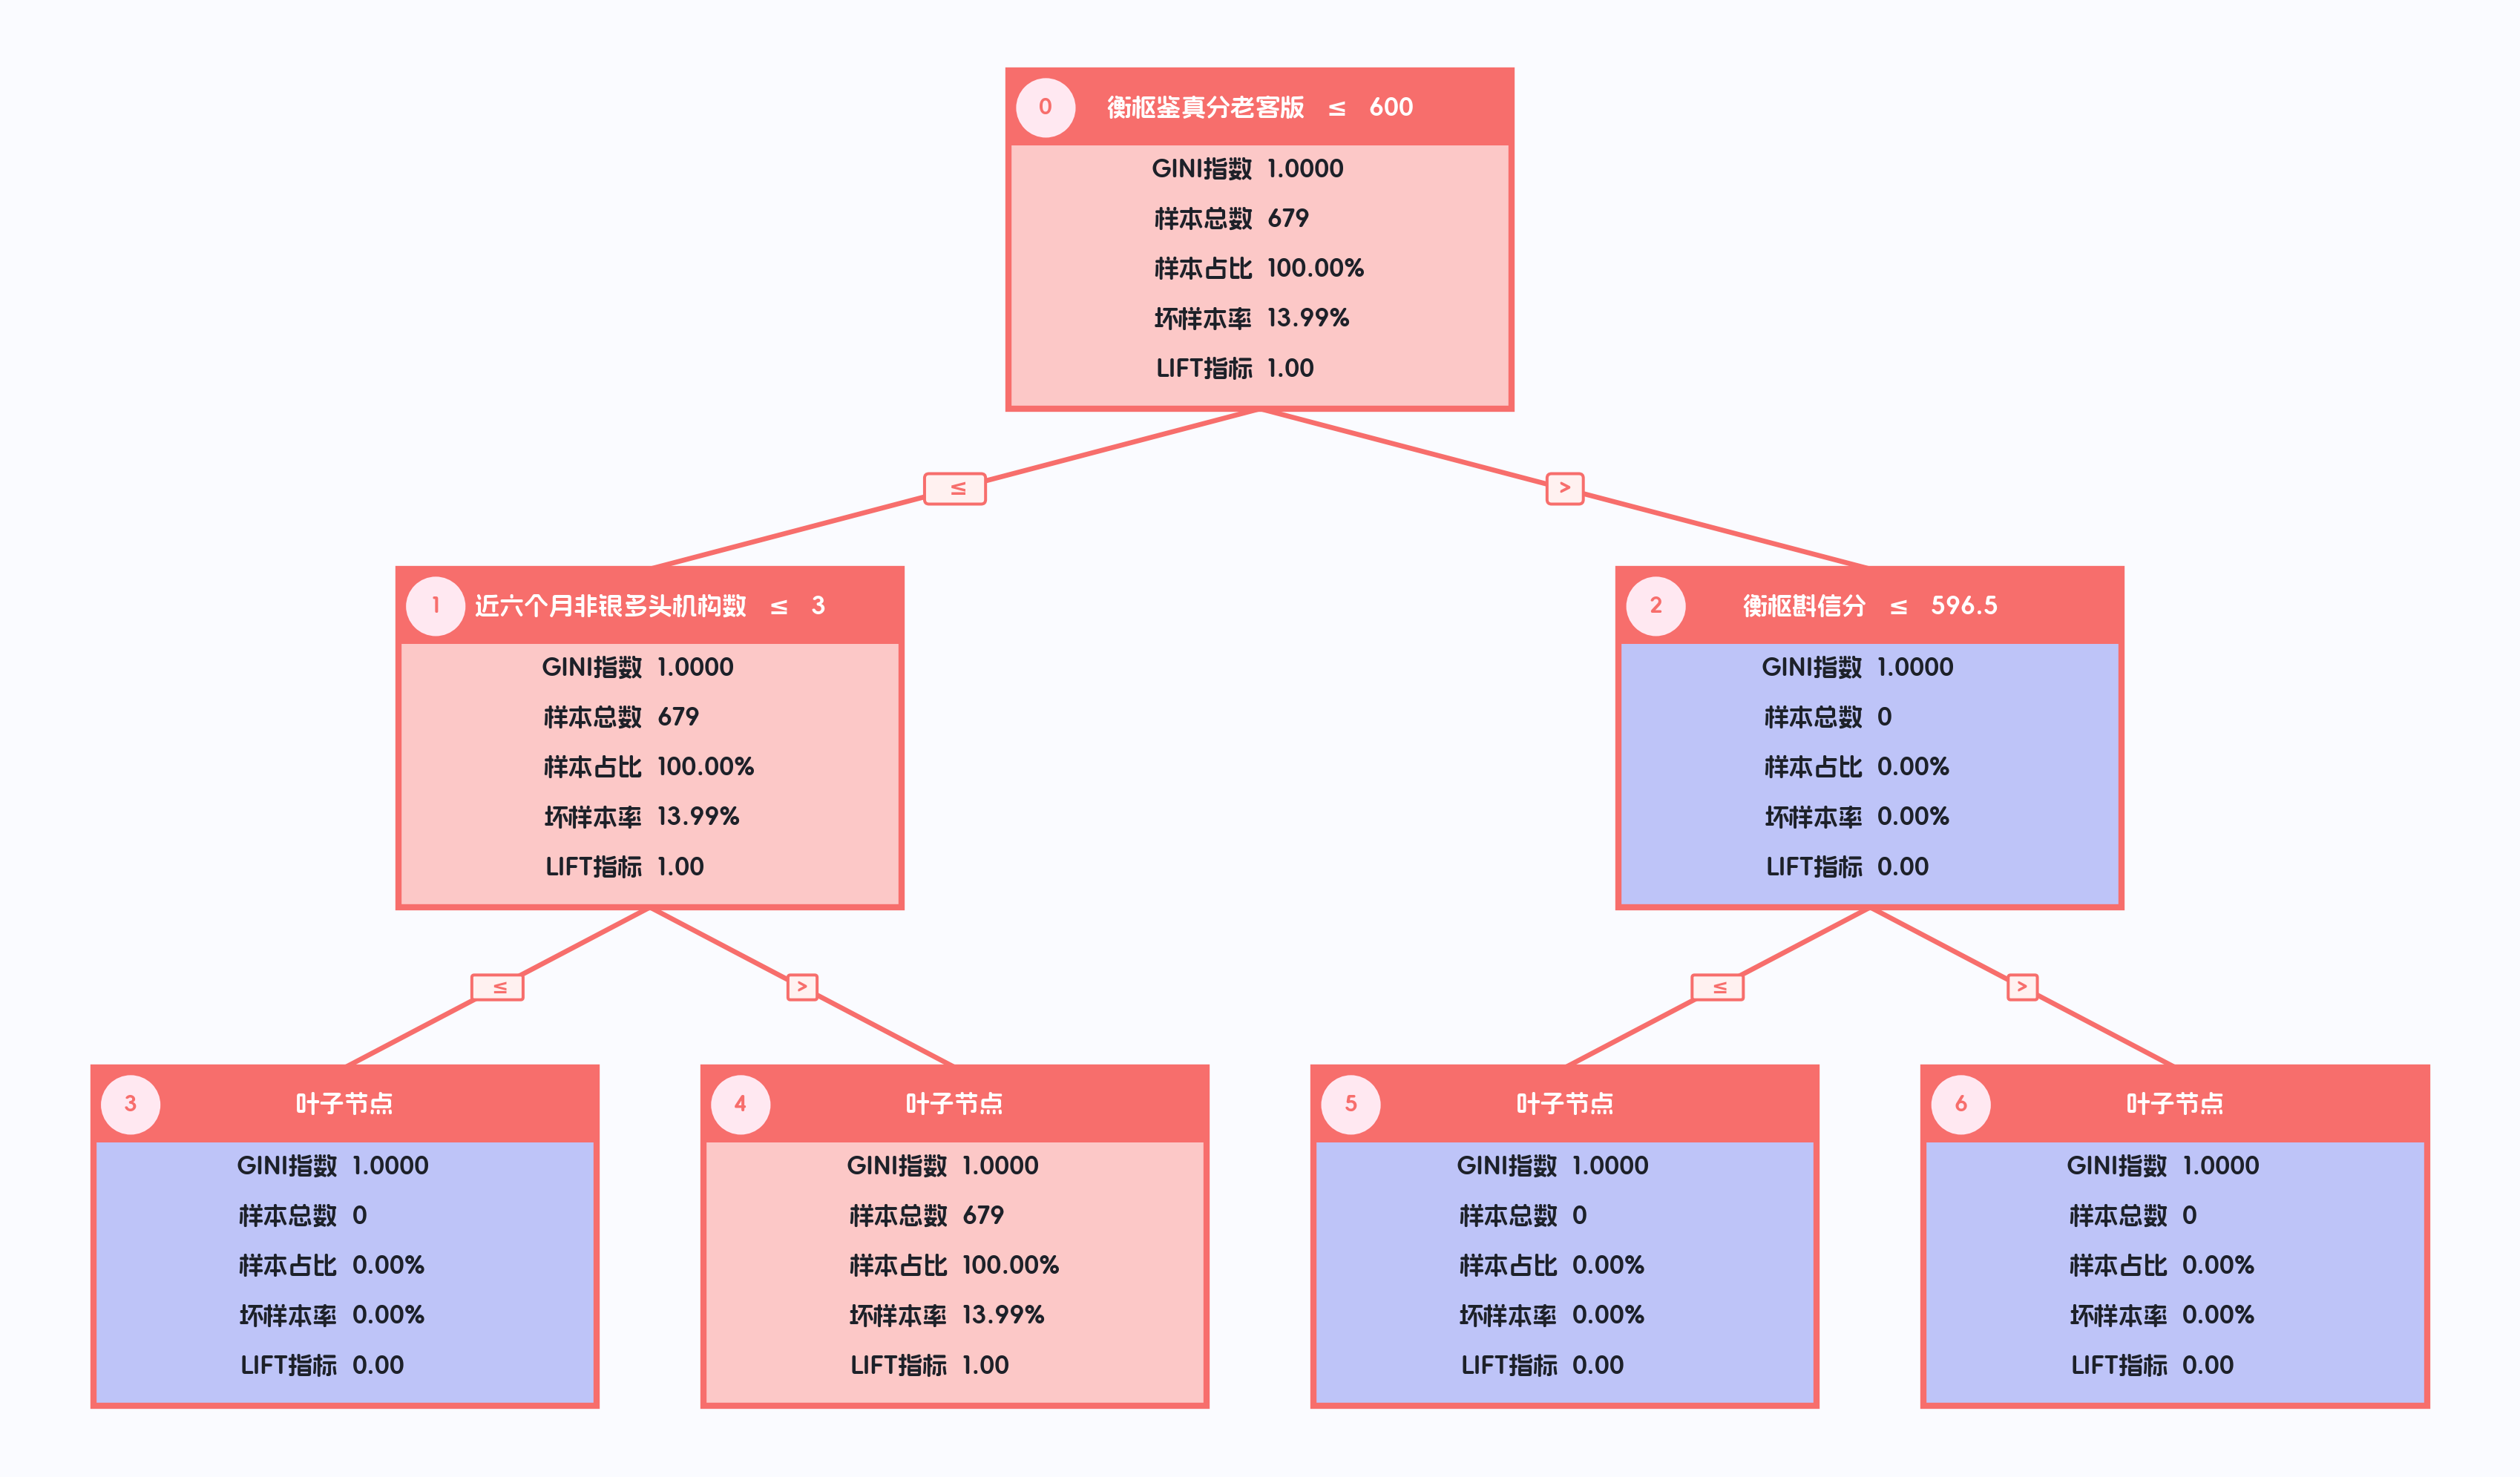

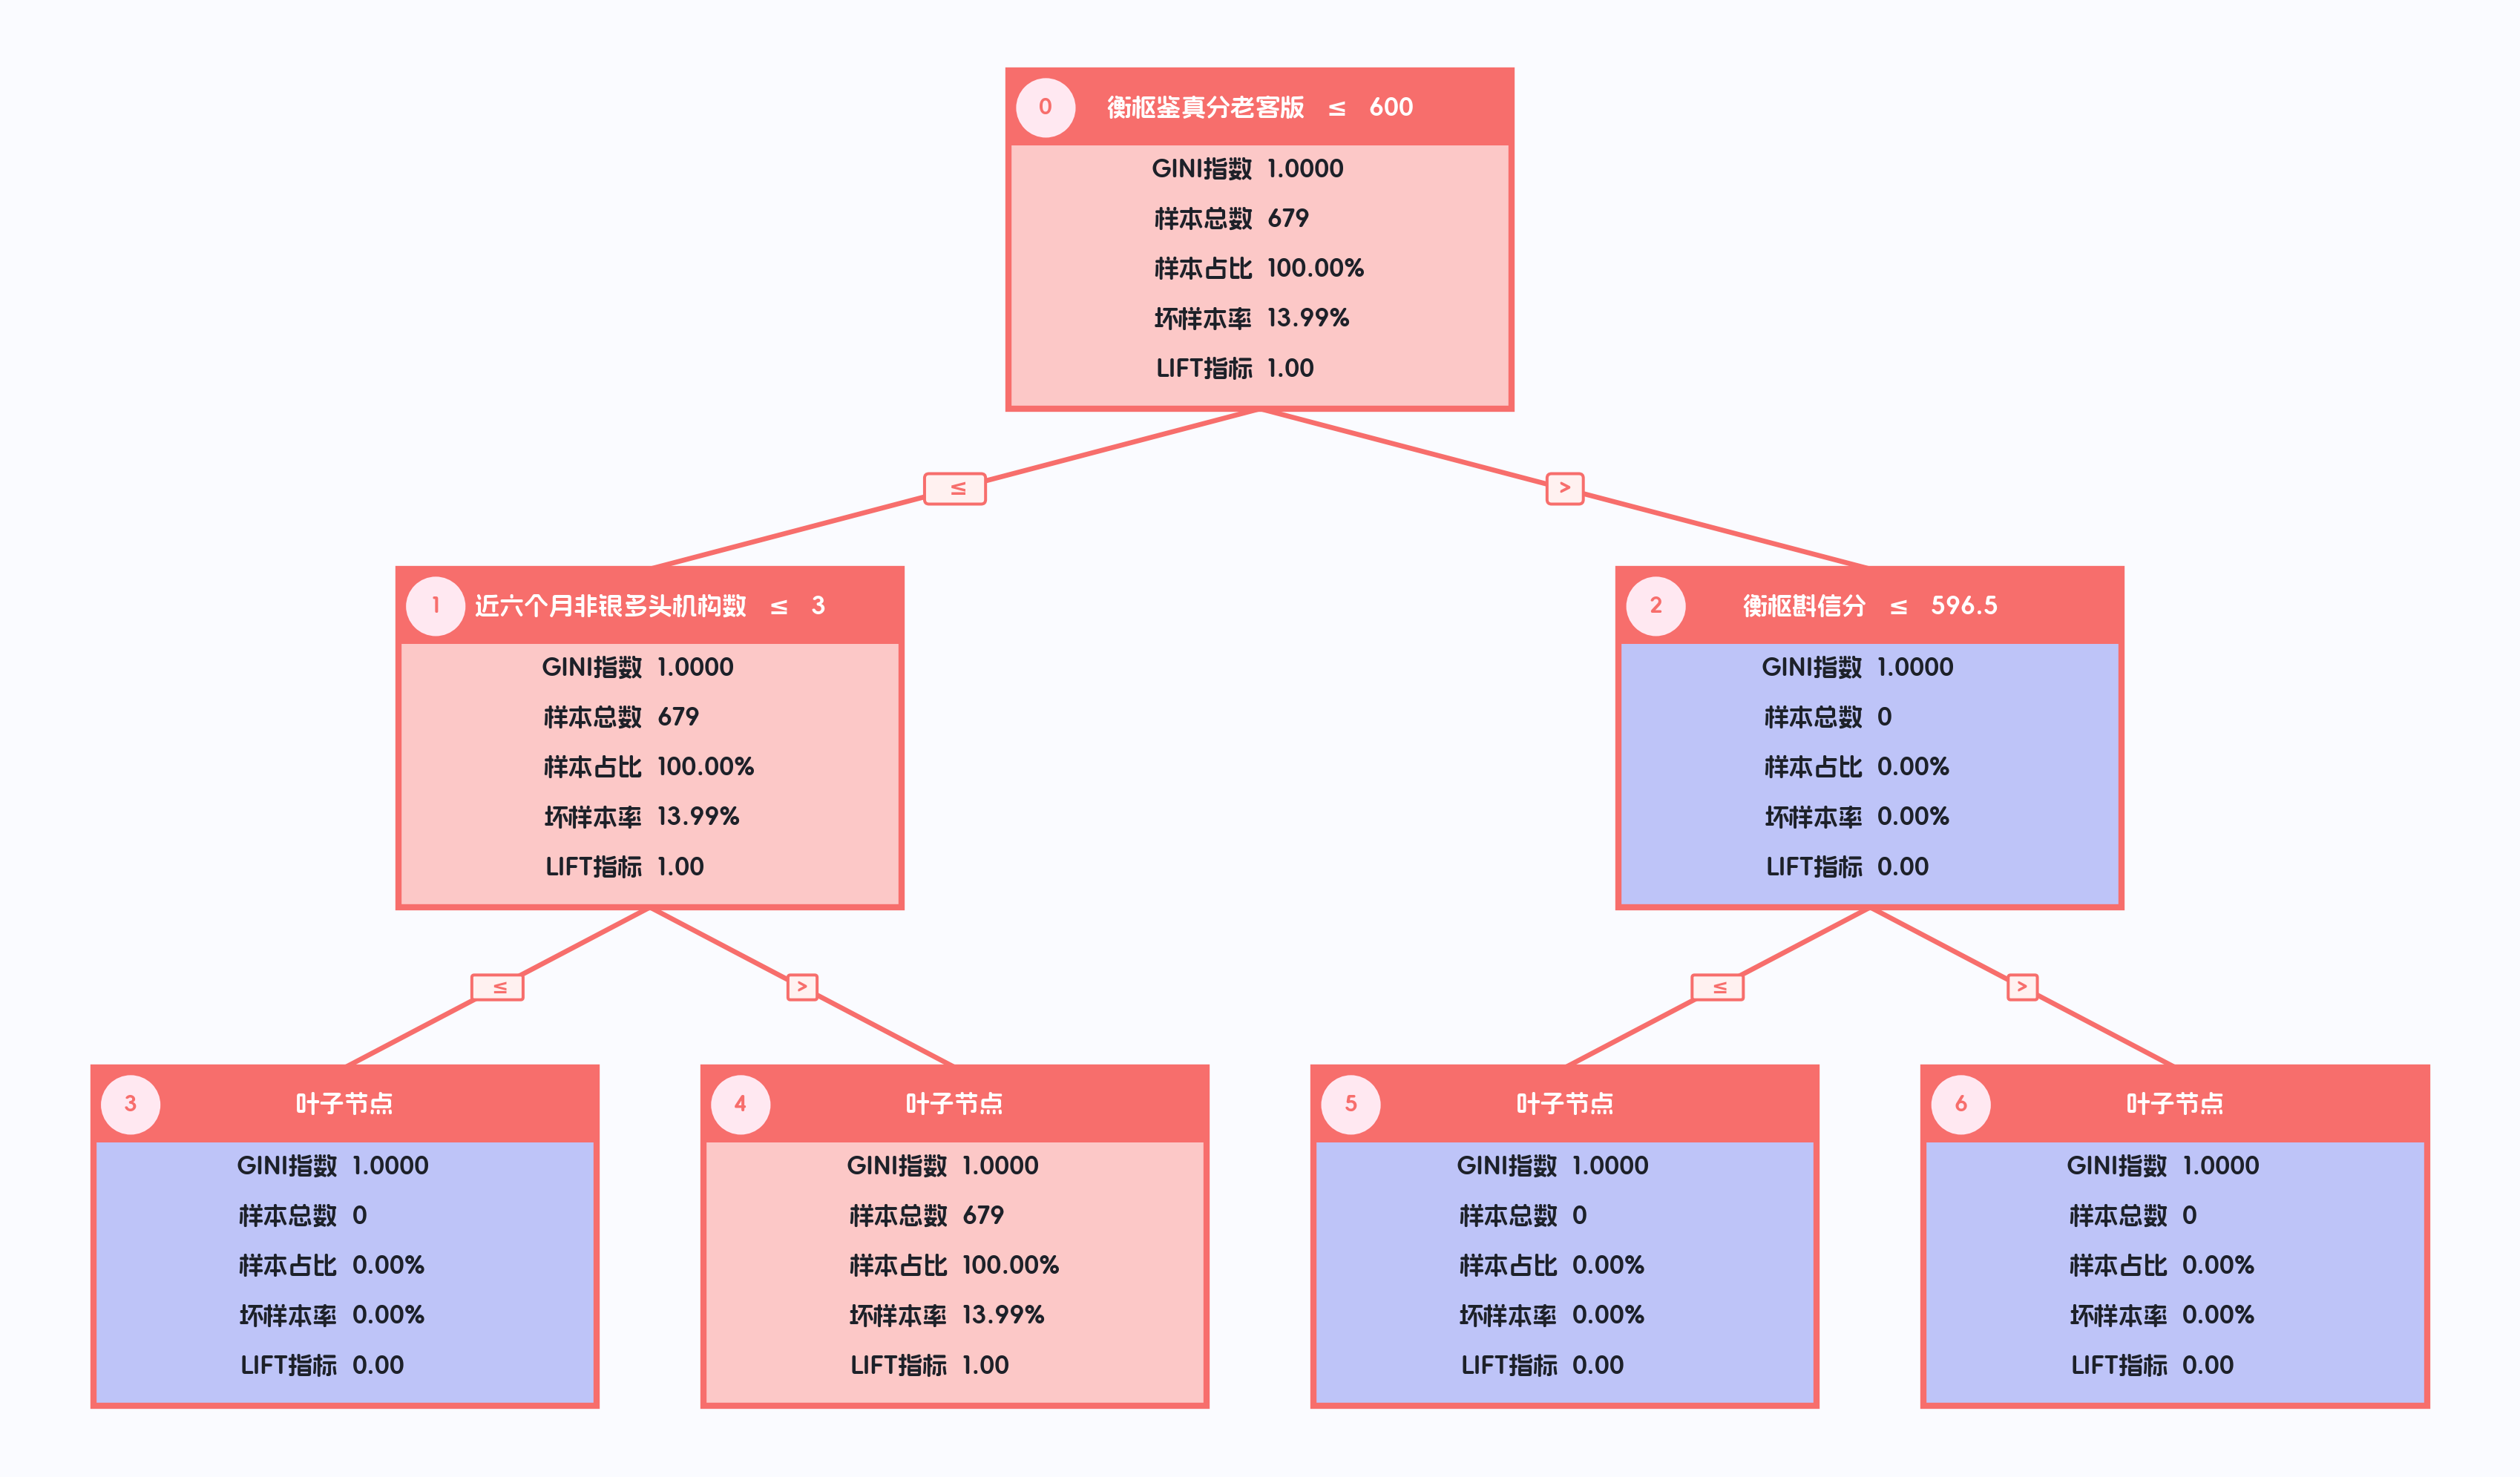

In [126]:
ext_chain.delete_node(node=3)

ext_chain.get_rule_table()
ext_chain.plot(save="model_report/manual_tree_pruned.png")


删除后，该节点会变回叶子节点。

这在策略迭代中很常见。自动树为了提升训练集区分度，可能会切出一些很细的小客群。但上线规则需要稳定、可解释、可监控。对于不稳定节点，宁可剪掉，也不要让策略变得过细。

## 十一、规则表怎么读：从“命中”行看策略价值

`ManualTreeExtractor.get_rule_table()` 的本质是对树中每个节点做一次规则评估。

内部流程可以理解为：



所以你看到的每一行都可以理解为：



策略分析时，可以重点筛选叶子节点：


In [127]:
leaf_table = ext_chain.get_rule_table(leaf_only=True)
leaf_table

,节点编号,是否叶子,规则分类,指标名称,指标含义,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,3,是,验证规则,(衡枢鉴真分老客版 <= 600.0) & (近六个月非银多头机构数 <= 3.0),衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 <= 3.0000,命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8601,0.0000,0.0000,0.0000
1,4,是,验证规则,(衡枢鉴真分老客版 <= 600.0) & ((近六个月非银多头机构数 > 3.0) | (近六个月非银多头机构数 != 近六个月非银多头机构数)),衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 > 3.0000(含缺失),命中,679,1.0000,584,1.0000,95,1.0000,0.1399,1.0000,1.0000,1.0000,0.1399,0.1399,1.0000,0.2455
2,5,是,验证规则,(衡枢斟信分 <= 596.5) & ((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),衡枢斟信分 <= 596.5000 且 衡枢鉴真分老客版 > 600.0000(含缺失),命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8601,0.0000,0.0000,0.0000
3,6,是,验证规则,((衡枢斟信分 > 596.5) | (衡枢斟信分 != 衡枢斟信分)) & ((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),衡枢斟信分 > 596.5000(含缺失) 且 衡枢鉴真分老客版 > 600.0000(含缺失),命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8601,0.0000,0.0000,0.0000



也可以在测试集上评估：


In [128]:
test_leaf_table = ext_chain.get_rule_table(df_test, leaf_only=True)
test_leaf_table

,节点编号,是否叶子,规则分类,指标名称,指标含义,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,3,是,验证规则,(衡枢鉴真分老客版 <= 600.0) & (近六个月非银多头机构数 <= 3.0),衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 <= 3.0000,命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8591,0.0000,0.0000,0.0000
1,4,是,验证规则,(衡枢鉴真分老客版 <= 600.0) & ((近六个月非银多头机构数 > 3.0) | (近六个月非银多头机构数 != 近六个月非银多头机构数)),衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 > 3.0000(含缺失),命中,291,1.0000,250,1.0000,41,1.0000,0.1409,1.0000,1.0000,1.0000,0.1409,0.1409,1.0000,0.2470
2,5,是,验证规则,(衡枢斟信分 <= 596.5) & ((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),衡枢斟信分 <= 596.5000 且 衡枢鉴真分老客版 > 600.0000(含缺失),命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8591,0.0000,0.0000,0.0000
3,6,是,验证规则,((衡枢斟信分 > 596.5) | (衡枢斟信分 != 衡枢斟信分)) & ((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),衡枢斟信分 > 596.5000(含缺失) 且 衡枢鉴真分老客版 > 600.0000(含缺失),命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8591,0.0000,0.0000,0.0000



训练集好看不够，测试集也稳定才有意义。

建议对每个候选叶子规则至少看四个维度：

| 维度 | 解读 |
|------|------|
| 覆盖面 | 样本占比太小，可能只适合观察或人工复核 |
| 风险度 | 坏样本率和 LIFT 是否明显高于整体 |
| 拒绝效率 | 风险拒绝比越高，越说明拒绝少量人能改善较多坏账 |
| 稳定性 | 训练集、测试集、时间外样本是否方向一致 |

`ManualTreeExtractor.report()` 支持一次评估多个数据集：


In [129]:
reports = ext_chain.report(
    {
        "训练集": df_train,
        "测试集": df_test,
    },
    target=target,
    leaf_only=True,
)

reports["训练集"]
reports["测试集"]

,节点编号,是否叶子,规则分类,指标名称,指标含义,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,3,是,验证规则,(衡枢鉴真分老客版 <= 600.0) & (近六个月非银多头机构数 <= 3.0),衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 <= 3.0000,命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8591,0.0000,0.0000,0.0000
1,4,是,验证规则,(衡枢鉴真分老客版 <= 600.0) & ((近六个月非银多头机构数 > 3.0) | (近六个月非银多头机构数 != 近六个月非银多头机构数)),衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 > 3.0000(含缺失),命中,291,1.0000,250,1.0000,41,1.0000,0.1409,1.0000,1.0000,1.0000,0.1409,0.1409,1.0000,0.2470
2,5,是,验证规则,(衡枢斟信分 <= 596.5) & ((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),衡枢斟信分 <= 596.5000 且 衡枢鉴真分老客版 > 600.0000(含缺失),命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8591,0.0000,0.0000,0.0000
3,6,是,验证规则,((衡枢斟信分 > 596.5) | (衡枢斟信分 != 衡枢斟信分)) & ((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),衡枢斟信分 > 596.5000(含缺失) 且 衡枢鉴真分老客版 > 600.0000(含缺失),命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8591,0.0000,0.0000,0.0000



如果你有跨月份样本，也可以传入：


In [130]:
month_reports = ext_chain.report(
    {
        "2024-01": df_train,
        "2024-02": df_test,
    },
    target=target,
    leaf_only=True,
)

In [131]:

month_reports["2024-01"]

,节点编号,是否叶子,规则分类,指标名称,指标含义,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,3,是,验证规则,(衡枢鉴真分老客版 <= 600.0) & (近六个月非银多头机构数 <= 3.0),衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 <= 3.0000,命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8601,0.0000,0.0000,0.0000
1,4,是,验证规则,(衡枢鉴真分老客版 <= 600.0) & ((近六个月非银多头机构数 > 3.0) | (近六个月非银多头机构数 != 近六个月非银多头机构数)),衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 > 3.0000(含缺失),命中,679,1.0000,584,1.0000,95,1.0000,0.1399,1.0000,1.0000,1.0000,0.1399,0.1399,1.0000,0.2455
2,5,是,验证规则,(衡枢斟信分 <= 596.5) & ((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),衡枢斟信分 <= 596.5000 且 衡枢鉴真分老客版 > 600.0000(含缺失),命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8601,0.0000,0.0000,0.0000
3,6,是,验证规则,((衡枢斟信分 > 596.5) | (衡枢斟信分 != 衡枢斟信分)) & ((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),衡枢斟信分 > 596.5000(含缺失) 且 衡枢鉴真分老客版 > 600.0000(含缺失),命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8601,0.0000,0.0000,0.0000


In [132]:
month_reports["2024-02"]

,节点编号,是否叶子,规则分类,指标名称,指标含义,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,3,是,验证规则,(衡枢鉴真分老客版 <= 600.0) & (近六个月非银多头机构数 <= 3.0),衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 <= 3.0000,命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8591,0.0000,0.0000,0.0000
1,4,是,验证规则,(衡枢鉴真分老客版 <= 600.0) & ((近六个月非银多头机构数 > 3.0) | (近六个月非银多头机构数 != 近六个月非银多头机构数)),衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 > 3.0000(含缺失),命中,291,1.0000,250,1.0000,41,1.0000,0.1409,1.0000,1.0000,1.0000,0.1409,0.1409,1.0000,0.2470
2,5,是,验证规则,(衡枢斟信分 <= 596.5) & ((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),衡枢斟信分 <= 596.5000 且 衡枢鉴真分老客版 > 600.0000(含缺失),命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8591,0.0000,0.0000,0.0000
3,6,是,验证规则,((衡枢斟信分 > 596.5) | (衡枢斟信分 != 衡枢斟信分)) & ((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),衡枢斟信分 > 596.5000(含缺失) 且 衡枢鉴真分老客版 > 600.0000(含缺失),命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8591,0.0000,0.0000,0.0000



这就能直接观察规则在不同月份是否稳定。

## 十二、多逾期口径评估：MOB1、DPD7、DPD3、DPD0 一起看

很多信贷策略不是只看一个 `target`。同一条规则可能对首逾、轻微逾期、严重逾期表现不同。

`Rule.report()` 和 `ManualTreeExtractor.report()` 支持通过 `overdue` 和 `dpds` 做多标签评估。

例如，用 `MOB1` 逾期天数字段，同时看 DPD7、DPD3、DPD0：


In [133]:
multi_dpd_report = ext_chain.report(
    df_test,
    overdue=["MOB1"],
    dpds=[7, 3, 0],
    leaf_only=True,
)

multi_dpd_report

分箱详情                                                                                                                                                                    MOB1 7+                                                                            MOB1 3+                                                                            MOB1 0+                                                                           
  节点编号 是否叶子  规则分类                                                                                  指标名称                                              指标含义  分箱 样本总数   样本占比    好样本数  好样本占比 坏样本数  坏样本占比   坏样本率  LIFT值   坏账改善  风险拒绝比    准确率    精确率    召回率   F1分数    好样本数  好样本占比 坏样本数  坏样本占比   坏样本率  LIFT值   坏账改善  风险拒绝比    准确率    精确率    召回率   F1分数    好样本数  好样本占比 坏样本数  坏样本占比   坏样本率  LIFT值   坏账改善  风险拒绝比    准确率    精确率    召回率   F1分数
0    3    是  验证规则                                            (衡枢鉴真分老客版 <= 600.0) & (近六个月非银多头机构数 <= 3.0)      衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 <= 3.0000  命中    0 0.0000       0 0.0000    0 0.0000 0.0000 0.0000 0.0000 0.0000 0.8419 0.0000 0.0000 0.0000       0 0.0000    0 0.0000 0.0000 0.0000 0.0000 0.0000 0.8247 0.0000 0.0000 0.0000       0 0.0000    0 0.0000 0.0000 0.0000 0.0000 0.0000 0.7973 0.0000 0.0000 0.0000
1    4    是  验证规则            (衡枢鉴真分老客版 <= 600.0) & ((近六个月非银多头机构数 > 3.0) | (近六个月非银多头机构数 != 近六个月非银多头机构数))  衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 > 3.0000(含缺失)  命中  291 1.0000     245 1.0000   46 1.0000 0.1581 1.0000 1.0000 1.0000 0.1581 0.1581 1.0000 0.2730     240 1.0000   51 1.0000 0.1753 1.0000 1.0000 1.0000 0.1753 0.1753 1.0000 0.2982     232 1.0000   59 1.0000 0.2027 1.0000 1.0000 1.0000 0.2027 0.2027 1.0000 0.3371
2    5    是  验证规则                      (衡枢斟信分 <= 596.5) & ((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版))      衡枢斟信分 <= 596.5000 且 衡枢鉴真分老客版 > 600.0000(含缺失)  命中    0 0.0000       0 0.0000    0 0.0000 0.0000 0.0000 0.0000 0.0000 0.8419 0.0000 0.0000 0.0000       0 0.0000    0 0.0000 0.0000 0.0000 0.0000 0.0000 0.8247 0.0000 0.0000 0.0000       0 0.0000    0 0.0000 0.0000 0.0000 0.0000 0.0000 0.7973 0.0000 0.0000 0.0000
3    6    是  验证规则  ((衡枢斟信分 > 596.5) | (衡枢斟信分 != 衡枢斟信分)) & ((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版))  衡枢斟信分 > 596.5000(含缺失) 且 衡枢鉴真分老客版 > 600.0000(含缺失)  命中    0 0.0000       0 0.0000    0 0.0000 0.0000 0.0000 0.0000 0.0000 0.8419 0.0000 0.0000 0.0000       0 0.0000    0 0.0000 0.0000 0.0000 0.0000 0.0000 0.8247 0.0000 0.0000 0.0000       0 0.0000    0 0.0000 0.0000 0.0000 0.0000 0.0000 0.7973 0.0000 0.0000 0.0000


这个功能对策略非常有用。

有些规则对 DPD0 很敏感，但对 DPD7 不明显，可能说明它抓到的是轻微波动，而不是严重风险。有些规则对 DPD7 仍然高 LIFT，说明它更接近实质坏账风险。

如果传入 `amount="放款金额"`，还可以做金额口径评估：


In [134]:
amount_report = ext_chain.report(
    df_test,
    target=target,
    amount="放款金额",
    leaf_only=True,
)


样本数口径回答“命中了多少人”，金额口径回答“命中了多少风险敞口”。在额度差异较大的产品中，金额口径非常关键。

## 十三、导出 Rule 对象：让树规则进入统一规则体系

树只是挖掘工具，真正落地的是规则。

`get_rules()` 可以把叶子节点转换成 `hscredit.core.rules.Rule` 对象：


In [135]:
rules = ext_chain.get_rules()

for rule in rules:
    print(rule.name)
    print(rule.expr)
    print(rule.description)

TreeNode_3
(衡枢鉴真分老客版 <= 600.0) & (近六个月非银多头机构数 <= 3.0)
衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 <= 3.0000
TreeNode_4
(衡枢鉴真分老客版 <= 600.0) & ((近六个月非银多头机构数 > 3.0) | (近六个月非银多头机构数 != 近六个月非银多头机构数))
衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 > 3.0000(含缺失)
TreeNode_5
(衡枢斟信分 <= 596.5) & ((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版))
衡枢斟信分 <= 596.5000 且 衡枢鉴真分老客版 > 600.0000(含缺失)
TreeNode_6
((衡枢斟信分 > 596.5) | (衡枢斟信分 != 衡枢斟信分)) & ((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版))
衡枢斟信分 > 596.5000(含缺失) 且 衡枢鉴真分老客版 > 600.0000(含缺失)



每个 `Rule` 都可以独立预测：


In [136]:
hit = rules[0].predict(df_test)
df_hit = df_test[hit]


也可以独立评估：


In [137]:
rule_report = rules[0].report(df_test, target=target)
rule_report

,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,(衡枢鉴真分老客版 <= 600.0) & (近六个月非银多头机构数 <= 3.0),命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8591,0.0000,0.0000,0.0000
1,验证规则,(衡枢鉴真分老客版 <= 600.0) & (近六个月非银多头机构数 <= 3.0),未命中,291,1.0000,250,1.0000,41,1.0000,0.1409,1.0000,1.0000,1.0000,0.1409,0.1409,1.0000,0.2470



这一步非常重要。它意味着决策树挖掘出的规则不是一次性报表，而是可以进入 hscredit 的统一规则系统：

- 可以单独 `predict()`。
- 可以单独 `report()`。
- 可以和其他专家规则做 `&`、`|`、`~` 组合。
- 可以放入 `RuleSet`。
- 可以交给 `RulesClassifier` 做批量预测和规则集分类。

例如：


In [138]:
from hscredit.core.rules import Rule

low_score = Rule("`衡枢鉴真分老客版` <= 600", name="低信用分")
high_multi = Rule("`近六个月非银多头机构数` > 3", name="多头较高")

high_risk_rule = low_score & high_multi
high_risk_rule.report(df_test, target=target)

,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,(`衡枢鉴真分老客版` <= 600) & (`近六个月非银多头机构数` > 3),命中,291,1.0000,250,1.0000,41,1.0000,0.1409,1.0000,1.0000,1.0000,0.1409,0.1409,1.0000,0.2470
1,验证规则,(`衡枢鉴真分老客版` <= 600) & (`近六个月非银多头机构数` > 3),未命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8591,0.0000,0.0000,0.0000



`Rule` 使用 pandas eval 语法。中文字段名建议用反引号包起来，例如：


In [139]:
Rule("`衡枢斟信分` <= 50")

Rule('`衡枢斟信分` <= 50')


## 十四、规则集分类器：把规则变成 sklearn 风格分类器

当规则越来越多时，单条规则评估不够，还需要一个“规则集分类器”。

`hscredit.core.models` 提供：


In [140]:
from hscredit.core.models import RuleSet, RulesClassifier


注意，`get_rules()` 会导出所有叶子节点。决策树的所有叶子天然会覆盖全量样本，所以不能简单把所有叶子规则直接 OR 成“高风险规则”，否则大多数样本都会命中某个叶子。

更合理的做法是：先用规则表筛选高风险叶子，再把这些高风险叶子放入规则集。例如筛选 `LIFT值 >= 1.5` 的叶子节点：


In [141]:
from hscredit.core.models import RuleSet, RulesClassifier

leaf_table = ext_chain.get_rule_table(df_train, leaf_only=True)
high_risk_nodes = (
    leaf_table.loc[
        (leaf_table["是否叶子"] == "是") & (leaf_table["LIFT值"] >= 1.),
        "节点编号",
    ]
    .astype(int)
    .tolist()
)

all_tree_rules = ext_chain.get_rules()
high_risk_rules = [
    rule for rule in all_tree_rules
    if int(rule.name.replace("TreeNode_", "")) in high_risk_nodes
]

tree_high_risk_set = RuleSet(
    name="决策树挖掘高风险规则集",
    logic="or",
    rules=high_risk_rules,
    description="任一高风险叶子规则命中即进入树规则高风险客群",
)

rules_clf = RulesClassifier(
    rules=[tree_high_risk_set],
    logic="or",
    output_mode="both",
    target=target,
)

rules_clf.fit(df_train)

final_pred, individual_pred = rules_clf.predict(df_test)


`RulesClassifier` 的常用输出模式：

| output_mode | 返回内容 |
|-------------|----------|
| `final` | 只返回最终 0/1 分类结果 |
| `individual` | 返回每条规则或规则集的命中结果 |
| `both` | 同时返回最终结果和单规则命中明细 |
| `reason` | 返回最终结果，并可返回命中原因 |

如果要看命中原因：


In [142]:
rules_clf_reason = RulesClassifier(
    rules=[tree_high_risk_set],
    logic="or",
    output_mode="reason",
    target=target,
)

pred, reasons = rules_clf_reason.predict(df_test, return_reason=True)


如果要看规则摘要：


In [143]:
rules_clf.get_rule_summary()

,层级,类型,名称,逻辑,表达式,权重,描述
0,0,规则集,决策树挖掘高风险规则集,or,-,1.0000,任一高风险叶子规则命中即进入树规则高风险客群
1,1,单规则,TreeNode_4,-,(衡枢鉴真分老客版 <= 600.0) & ((近六个月非银多头机构数 > 3.0) | (近六个月非银多头机构数 != 近六个月非银多头机构数)),1.0000,衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 > 3.0000(含缺失)



如果要看规则使用了哪些特征：


In [144]:
rules_clf.get_feature_importances()

衡枢鉴真分老客版       1
近六个月非银多头机构数    1
衡枢斟信分          0
MOB1           0
放款金额           0
Name: importance, dtype: int64


这个能力适合做策略上线前的规则梳理。你可以把自动树规则、人工经验规则、黑名单规则、渠道规则组织成多层 `RuleSet`，然后统一用 `RulesClassifier` 预测。

## 十五、规则集效果怎么评估

`RulesClassifier` 负责把规则集变成预测器；效果评估可以继续复用 `Rule.report()` 或构造一个规则来评估最终命中结果。

一种简单方式是把规则集最终命中结果写回数据，再计算命中客群坏账率：


In [145]:
eval_df = df_test.copy()
final_pred, individual_pred = rules_clf.predict(df_test)
eval_df["规则集命中"] = final_pred.astype(int)

summary = (
    eval_df.groupby("规则集命中")
    .agg(
        样本总数=(target, "size"),
        坏样本数=(target, "sum"),
        坏样本率=(target, "mean"),
        放款金额=("放款金额", "sum"),
    )
    .reset_index()
)

summary

,规则集命中,样本总数,坏样本数,坏样本率,放款金额
0,1,291,41,0.1409,1242339



更推荐的方式，是直接把最终规则用 `Rule` 或 `RuleSet` 表达，再用 `Rule.report()` 输出标准风控指标。

如果筛选后的高风险树规则之间是 OR 关系，可以组合成一条规则：


In [146]:
from functools import reduce
import operator

if not high_risk_rules:
    raise ValueError("未筛选出高风险叶子规则，请降低 LIFT 阈值或改用坏样本率筛选")

combined_tree_rule = reduce(operator.or_, high_risk_rules)
combined_tree_rule.name = "决策树高风险叶子规则组合"

combined_tree_rule.report(
    df_test,
    target=target,
    amount="放款金额",
    margins=True,
)

,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,(衡枢鉴真分老客版 <= 600.0) & ((近六个月非银多头机构数 > 3.0) | (近六个月非银多头机构数 != 近六个月非银多头机构数)),命中,1242339,1.0000,1055769,1.0000,186570,1.0000,0.1502,1.0000,1.0000,1.0000,0.1409,0.1409,1.0000,0.2470
1,验证规则,(衡枢鉴真分老客版 <= 600.0) & ((近六个月非银多头机构数 > 3.0) | (近六个月非银多头机构数 != 近六个月非银多头机构数)),未命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8591,0.0000,0.0000,0.0000
2,验证规则,合计,合计,1242339,1.0000,1055769,1.0000,186570,1.0000,0.1502,1.0000,0.0000,0.0000,0.1409,0.1409,1.0000,0.2470



这样能直接得到 hscredit 标准规则报告，包括：

- 样本总数。
- 样本占比。
- 好样本数。
- 坏样本数。
- 坏样本率。
- LIFT 值。
- 坏账改善。
- 风险拒绝比。
- 准确率、精确率、召回率、F1 分数。

如果还要结合先验规则，例如在保留了 `商品类别` 字段的数据中先过滤某类商品，再看树规则效果，可以使用 `prior_rules`：


In [148]:
# prior = Rule("`商品类别` == '某类商品'", name="指定商品类别")

# combined_tree_rule.report(
#     df_test,
#     target=target,
#     prior_rules=prior,
# )


这对策略分析很实用：很多规则不是在全量客群上使用，而是在某个产品、渠道、客群、额度段内使用。

## 十六、从 sklearn 决策树导入，再人工调整

如果你已经用 sklearn 训练了一棵树，也可以转成 `ManualTreeExtractor`：


In [149]:
from sklearn.tree import DecisionTreeClassifier
from hscredit.report.mining import ManualTreeExtractor

clf = DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=42)
clf.fit(df_train[feature_list], df_train[target])

mte_from_sklearn = ManualTreeExtractor.from_sklearn(
    clf,
    feature_names=feature_list,
    target=target,
)

mte_from_sklearn.manual_split(
    df_train,
    feature="衡枢鉴真分老客版",
    threshold=600,
    node=0,
)

mte_from_sklearn.get_rule_table(df_train)

,节点编号,是否叶子,规则分类,指标名称,指标含义,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,1,是,验证规则,(衡枢鉴真分老客版 <= 600.0),衡枢鉴真分老客版 <= 600.0000,命中,679,1.0000,584,1.0000,95,1.0000,0.1399,1.0000,1.0000,1.0000,0.1399,0.1399,1.0000,0.2455
1,2,是,验证规则,((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),衡枢鉴真分老客版 > 600.0000(含缺失),命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8601,0.0000,0.0000,0.0000



注意：`from_sklearn()` 创建的对象不一定保存训练数据，所以计算规则效果时建议显式传入数据集：


In [150]:
mte_from_sklearn.get_rule_table(df_test)

,节点编号,是否叶子,规则分类,指标名称,指标含义,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,1,是,验证规则,(衡枢鉴真分老客版 <= 600.0),衡枢鉴真分老客版 <= 600.0000,命中,291,1.0000,250,1.0000,41,1.0000,0.1409,1.0000,1.0000,1.0000,0.1409,0.1409,1.0000,0.2470
1,2,是,验证规则,((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),衡枢鉴真分老客版 > 600.0000(含缺失),命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8591,0.0000,0.0000,0.0000



## 十七、一套完整工作流：从自动树到业务规则报告

下面是一段完整模板，可以直接放到 Notebook 中改字段运行。


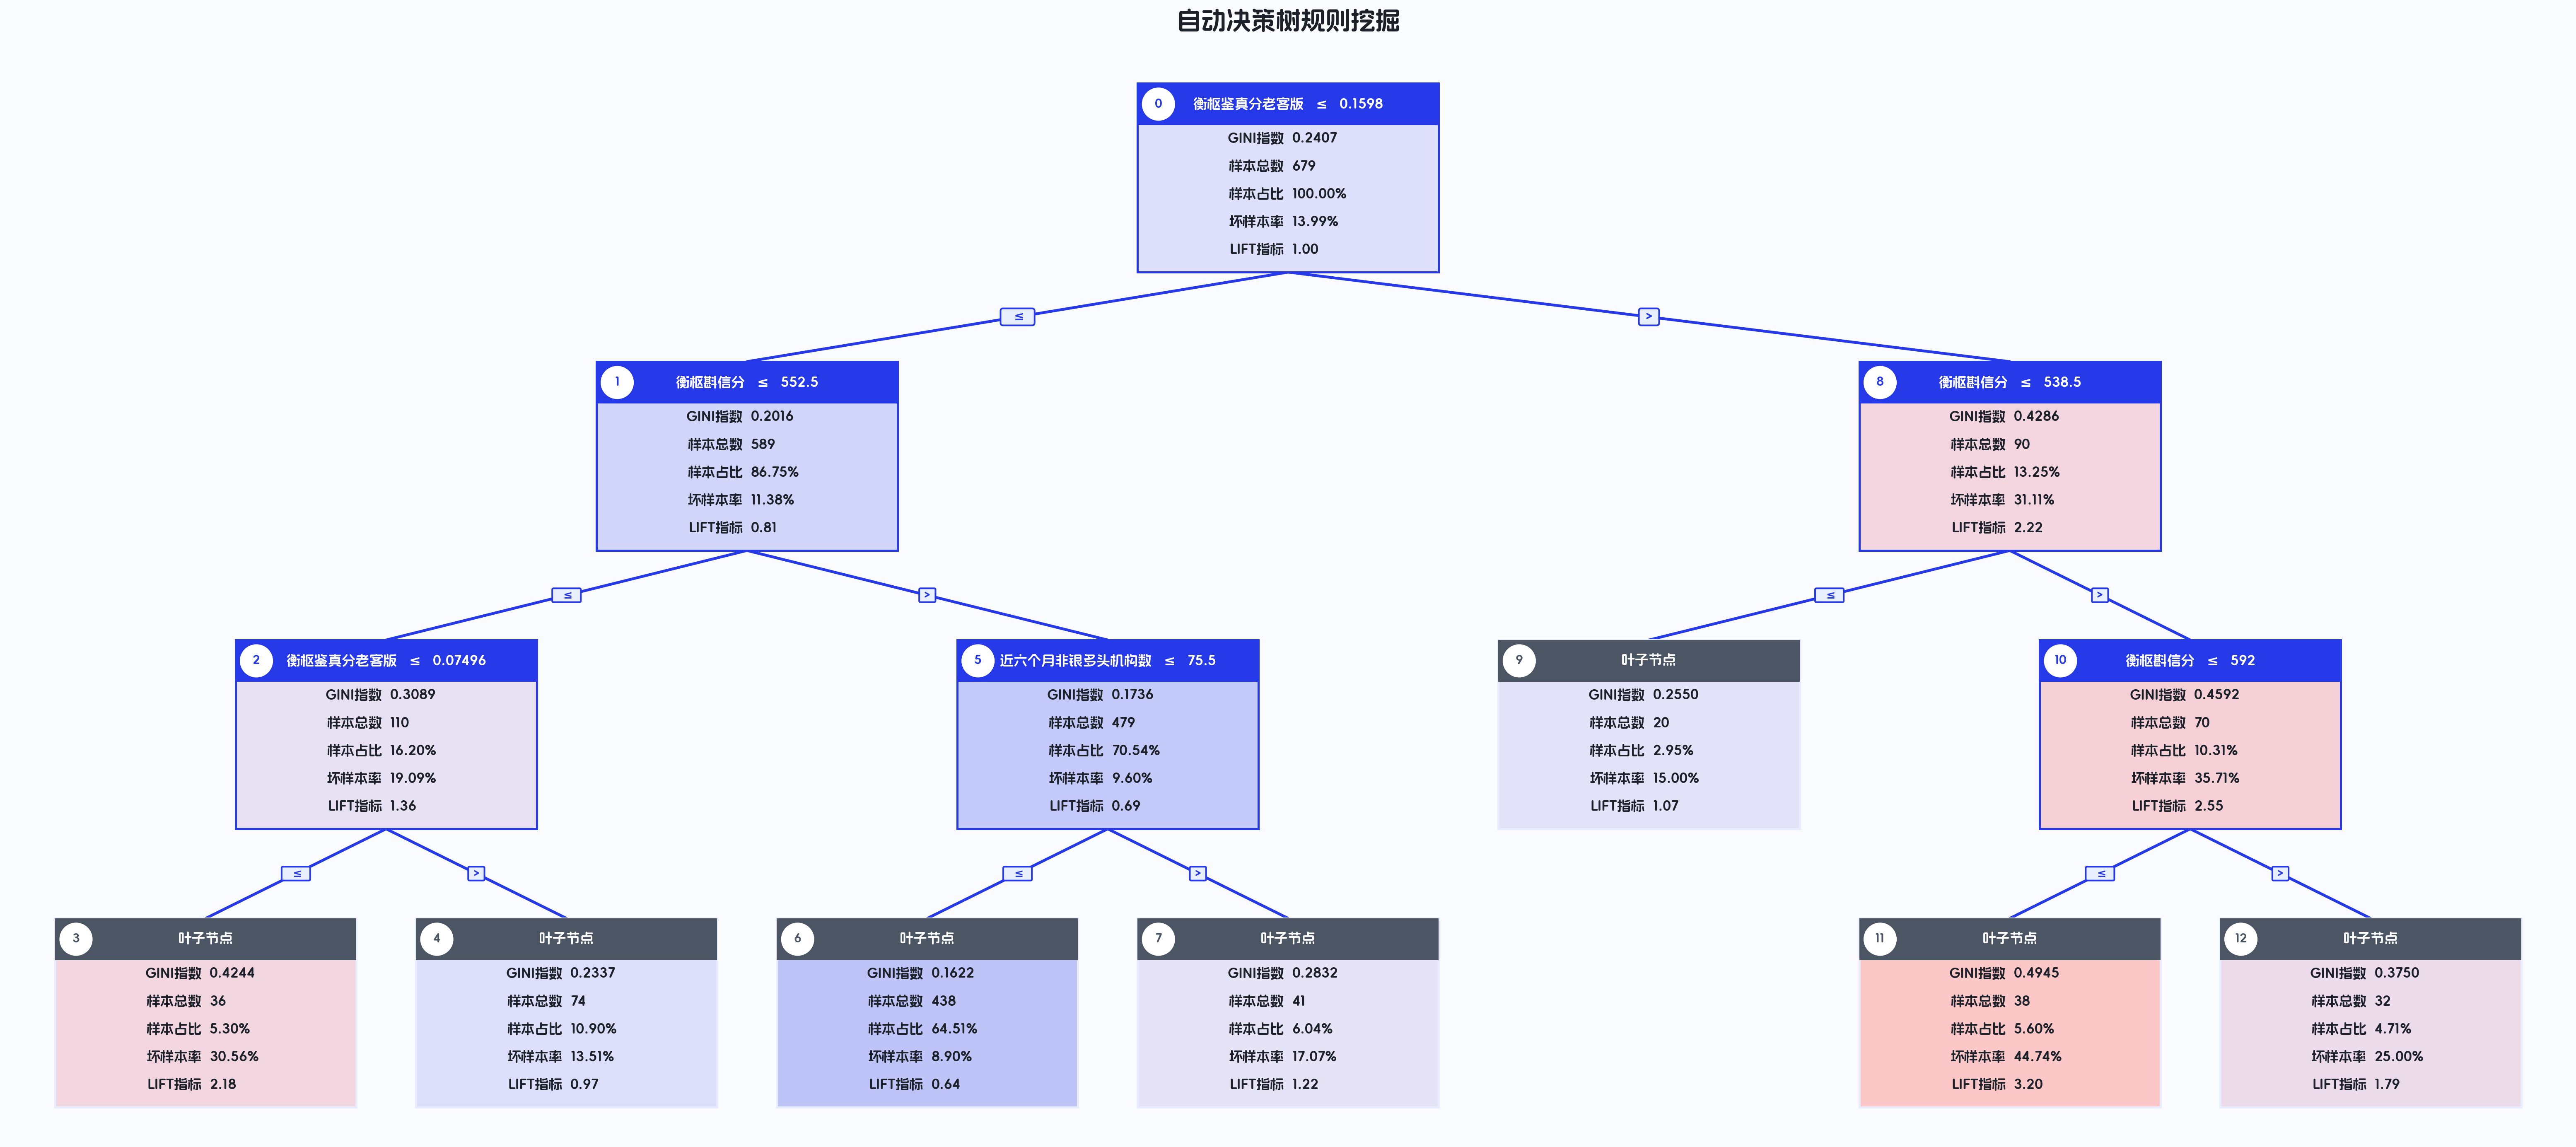

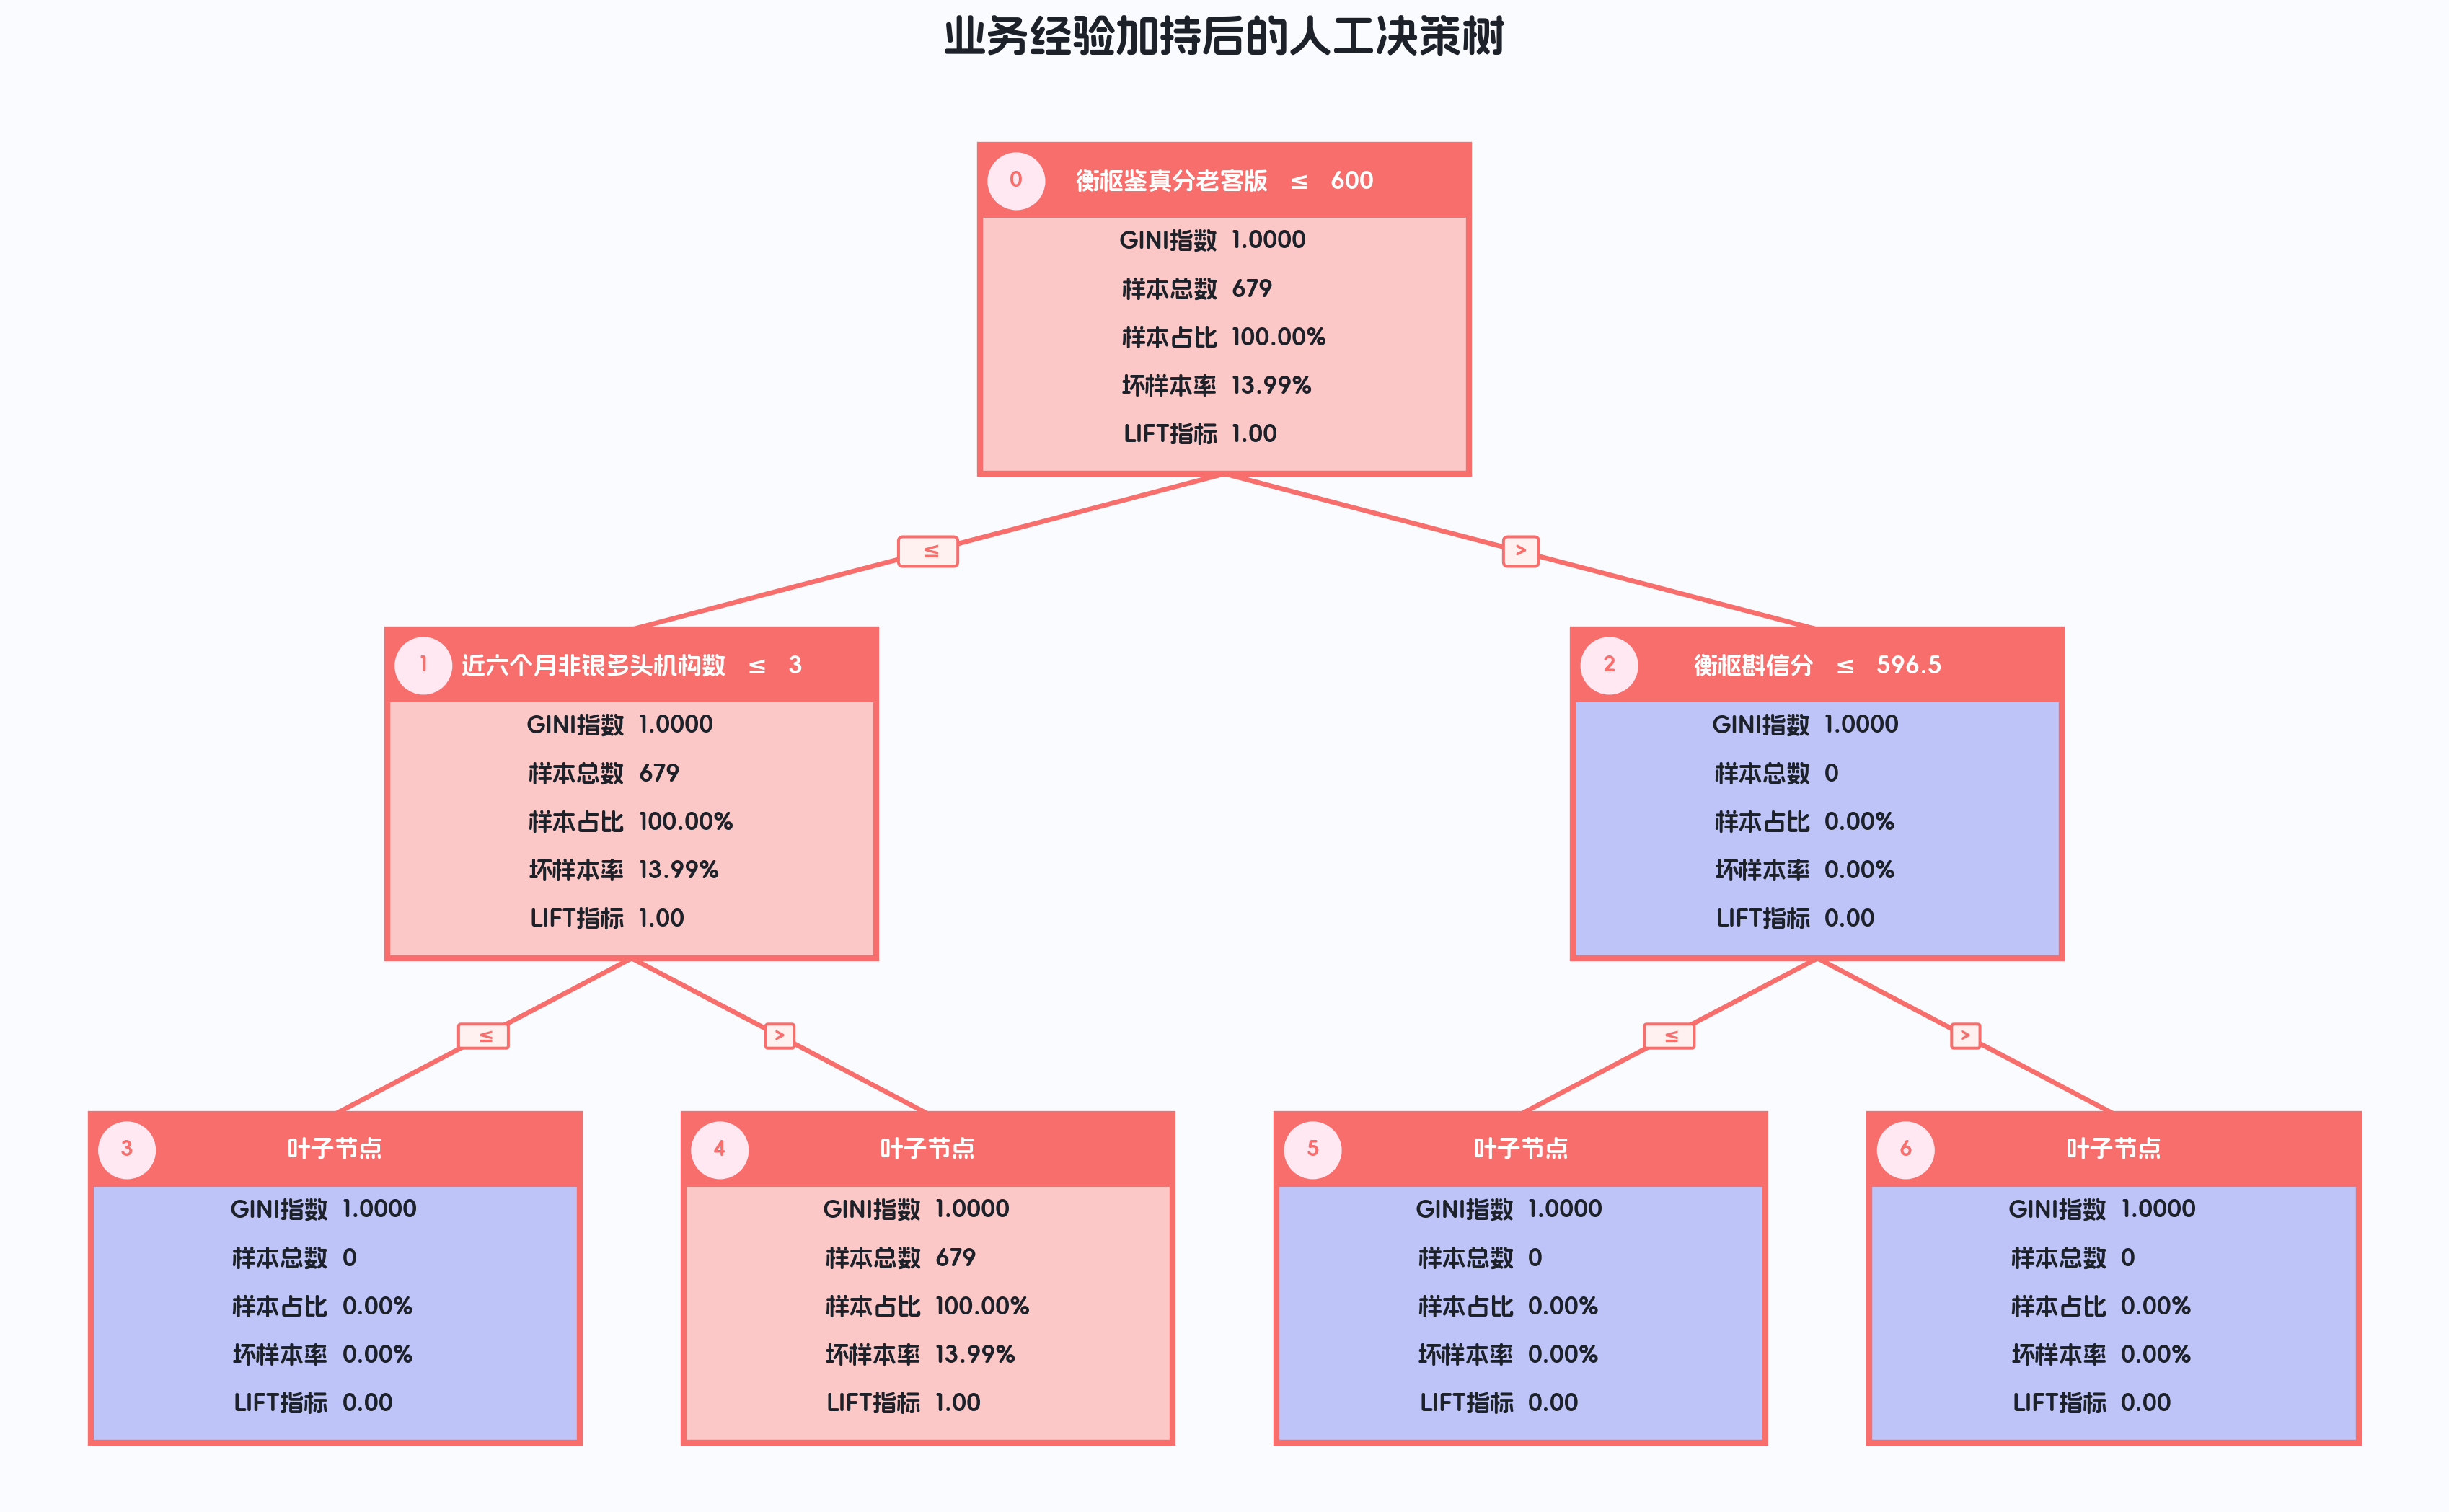

In [151]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

from hscredit.report.mining import ManualTreeExtractor
from hscredit.core.viz import plot_tree
from hscredit.core.models import RuleSet, RulesClassifier

DATA_PATH = "hscredit_yyp.xlsx"
OUTPUT_DIR = "model_report/manual_tree_article"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_excel(DATA_PATH).rename(columns={"青云24": "衡枢斟信分"})

target = "FPD"
features = [
    "衡枢鉴真分老客版",
    "近六个月非银多头机构数",
    "衡枢斟信分",
]

cols = features + [target, "MOB1", "放款金额"]
data = df[cols].dropna(subset=[target]).copy()

df_train, df_test = train_test_split(
    data,
    test_size=0.3,
    random_state=42,
    stratify=data[target],
)

# 1. 自动训练基础树
ext = ManualTreeExtractor(
    target=target,
    max_depth=3,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42,
)
ext.fit(df_train, features=features)

# 2. 看自动树规则效果
auto_train_table = ext.get_rule_table(leaf_only=True)
auto_test_table = ext.get_rule_table(df_test, leaf_only=True)

# 3. 保存自动树图
plot_tree(
    ext,
    backend="matplotlib",
    save=f"{OUTPUT_DIR}/01_auto_tree.png",
    title="自动决策树规则挖掘",
)

# 4. 人工调整根节点：使用业务认可的 600 分阈值
ext.manual_split(
    data=df_train,
    feature="衡枢鉴真分老客版",
    threshold=600,
    node=0,
)

# 5. 在低分节点继续按多头变量分裂
ext.manual_split(
    data=df_train,
    feature="近六个月非银多头机构数",
    threshold=3,
    node=1,
)

# 6. 在另一个节点让算法自动寻找衡枢斟信分阈值
ext.manual_split(
    data=df_train,
    feature="衡枢斟信分",
    threshold=None,
    node=2,
)

# 7. 保存人工调整后的树图
plot_tree(
    ext,
    backend="matplotlib",
    save=f"{OUTPUT_DIR}/02_manual_tree.png",
    title="业务经验加持后的人工决策树",
)

# 8. 训练集、测试集分别评估叶子规则
manual_reports = ext.report(
    {
        "训练集": df_train,
        "测试集": df_test,
    },
    target=target,
    leaf_only=True,
)

# 9. 多逾期口径评估
dpd_report = ext.report(
    df_test,
    overdue=["MOB1"],
    dpds=[7, 3, 0],
    leaf_only=True,
)

# 10. 筛选高风险叶子规则，并构造规则集分类器
leaf_table = ext.get_rule_table(df_train, leaf_only=True)
high_risk_nodes = (
    leaf_table.loc[
        (leaf_table["是否叶子"] == "是") & (leaf_table["LIFT值"] >= 1.5),
        "节点编号",
    ]
    .astype(int)
    .tolist()
)

all_tree_rules = ext.get_rules()
high_risk_rules = [
    rule for rule in all_tree_rules
    if int(rule.name.replace("TreeNode_", "")) in high_risk_nodes
]

tree_ruleset = RuleSet(
    name="人工决策树高风险叶子规则集",
    logic="or",
    rules=high_risk_rules,
)

rules_clf = RulesClassifier(
    rules=[tree_ruleset],
    logic="or",
    output_mode="both",
    target=target,
)
rules_clf.fit(df_train)

final_pred, detail_pred = rules_clf.predict(df_test)


如果你希望在 Jupyter 中快速展示当前树和美化规则表，可以用：


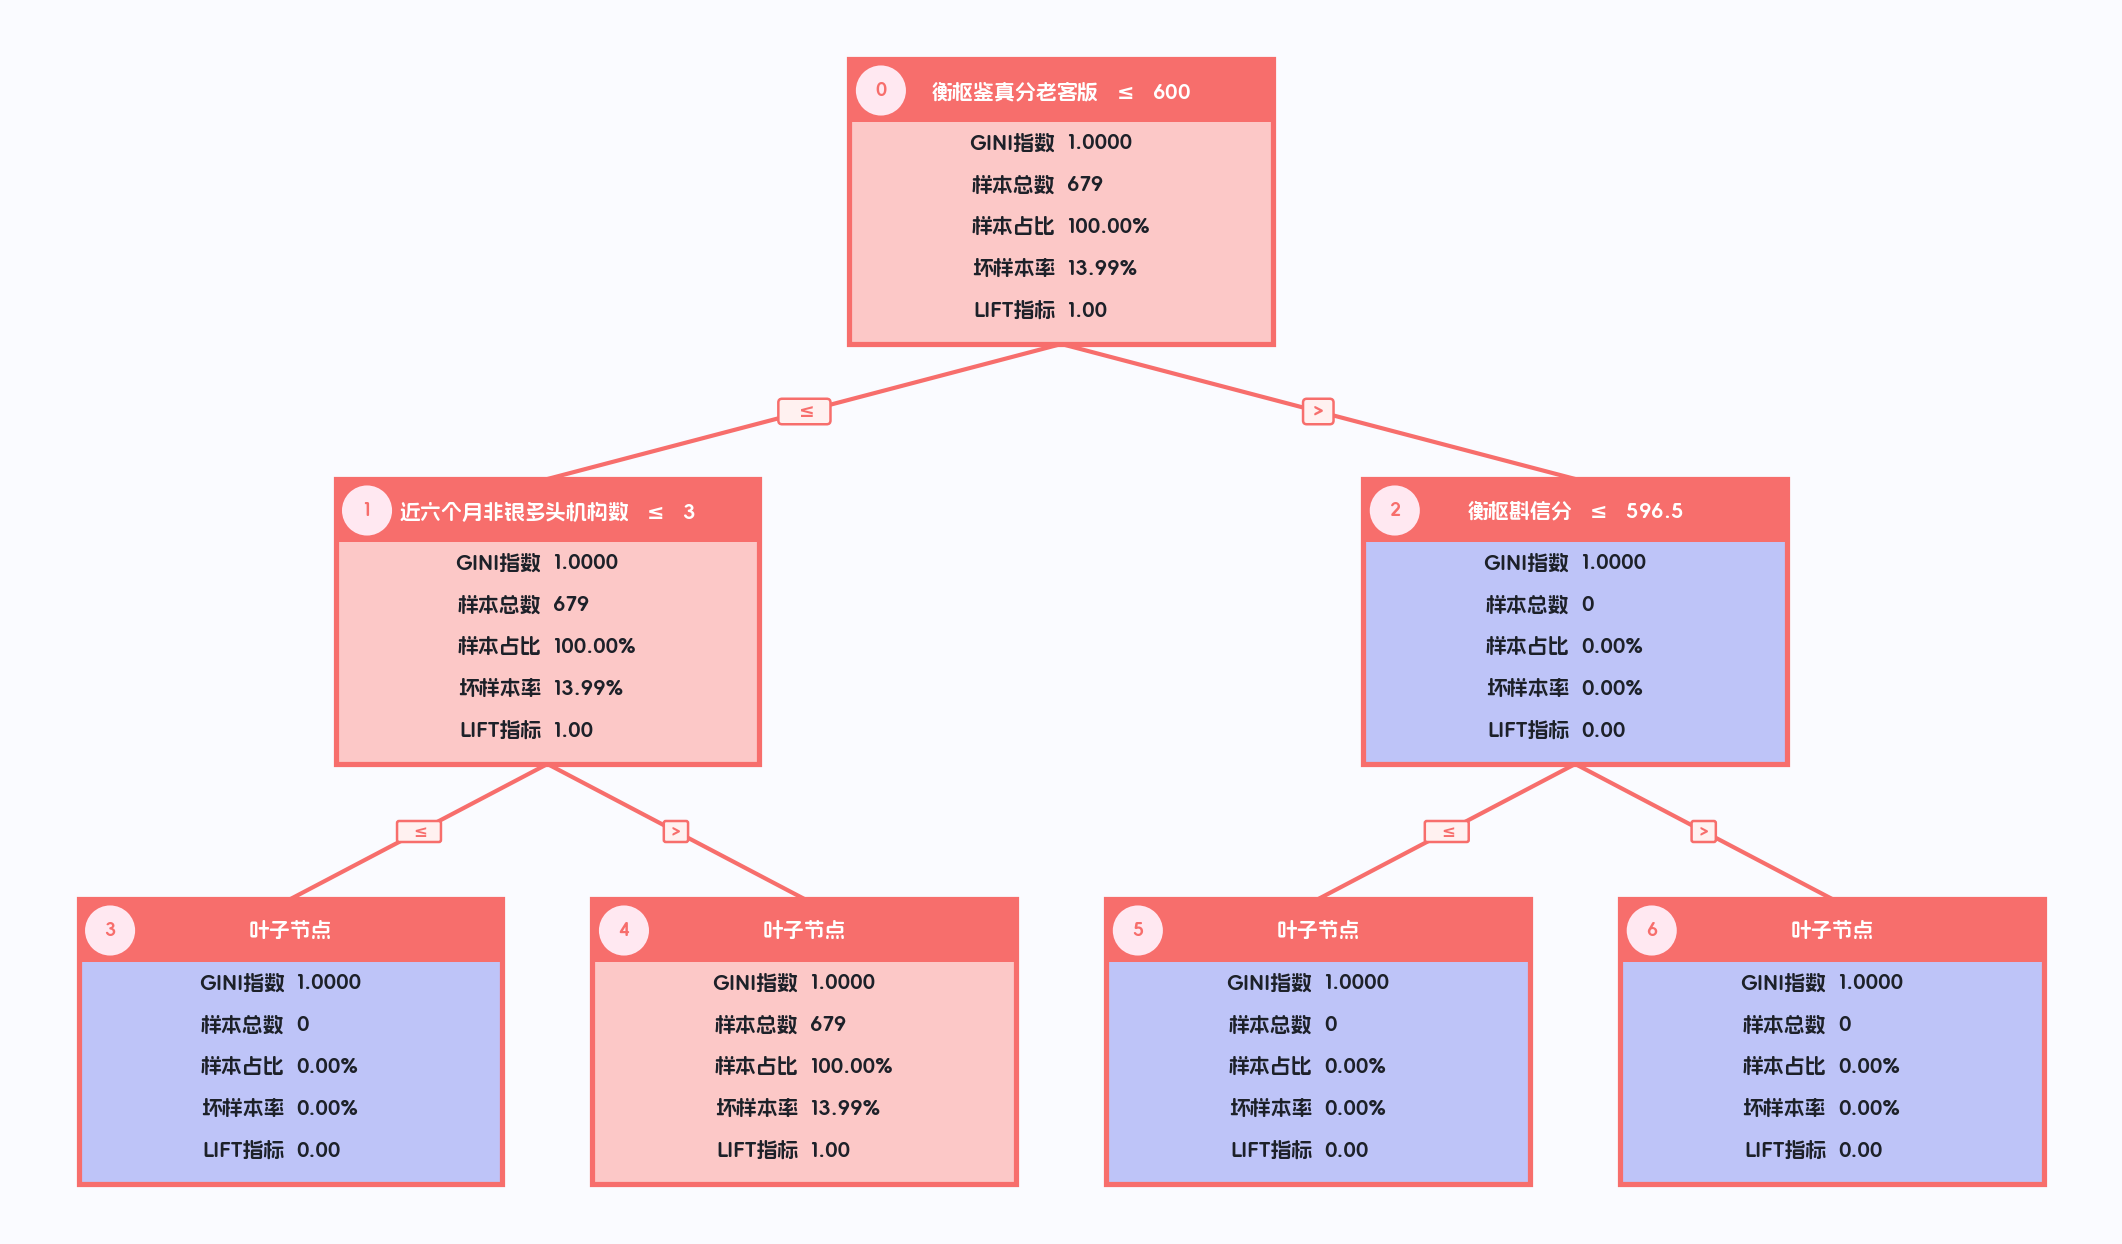

,节点编号,是否叶子,指标含义,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,1,否,衡枢鉴真分老客版 <= 600.0000,679,100.00%,584,100.00%,95,100.00%,13.99%,1.00,100.00%,100.00%,13.99%,13.99%,100.00%,24.55%
1,2,否,衡枢鉴真分老客版 > 600.0000(含缺失),0,0.00%,0,0.00%,0,0.00%,0.00%,0.00,0.00%,0.00%,86.01%,0.00%,0.00%,0.00%
2,3,是,衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 <= 3.0000,0,0.00%,0,0.00%,0,0.00%,0.00%,0.00,0.00%,0.00%,86.01%,0.00%,0.00%,0.00%
3,4,是,衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 > 3.0000(含缺失),679,100.00%,584,100.00%,95,100.00%,13.99%,1.00,100.00%,100.00%,13.99%,13.99%,100.00%,24.55%
4,5,是,衡枢斟信分 <= 596.5000 且 衡枢鉴真分老客版 > 600.0000(含缺失),0,0.00%,0,0.00%,0,0.00%,0.00%,0.00,0.00%,0.00%,86.01%,0.00%,0.00%,0.00%
5,6,是,衡枢斟信分 > 596.5000(含缺失) 且 衡枢鉴真分老客版 > 600.0000(含缺失),0,0.00%,0,0.00%,0,0.00%,0.00%,0.00,0.00%,0.00%,86.01%,0.00%,0.00%,0.00%


ManualTreeExtractor(target='FPD', features=['衡枢鉴真分老客版', '近六个月非银多头机构数', '衡枢斟信分'], samples=679, leaves=4)

In [152]:
ext.display()


## 十八、业务上怎么判断一棵规则树好不好

一棵好的信贷规则树，不是训练集 AUC 最高的树，而是能在业务上解释、在测试集稳定、在线上可执行的树。

建议从以下角度判断：

### 1. 根节点是不是业务主变量

根节点决定第一层客群分层。信贷策略中，根节点最好是稳定、可解释、有管理意义的变量，例如主评分、多头强度、历史逾期、收入负债类指标。

如果根节点是一个很冷门、很难解释、口径经常变化的变量，即使训练集效果好，也要谨慎。

### 2. 阈值是不是可沟通

`587.4321` 也许统计最优，但 `600` 更适合策略上线。

`ManualTreeExtractor` 的价值就在这里：你可以把自动阈值调整成业务阈值，然后立即看风险损失是否可以接受。如果效果差不多，优先选择可解释、可运营的阈值。

### 3. 叶子节点样本量够不够

样本量太小的叶子节点很容易虚高。建议结合 `min_samples_leaf` 控制叶子规模，并在 `get_rule_table(leaf_only=True)` 中检查 `样本总数` 和 `样本占比`。

### 4. 训练集和测试集方向是否一致

一条规则在训练集 LIFT=4，测试集 LIFT=1.1，基本不适合直接上线。

可以用：


In [153]:
ext.report({"训练集": df_train, "测试集": df_test}, target=target, leaf_only=True)

{'训练集':    节点编号 是否叶子  规则分类                                                                                  指标名称                                              指标含义  分箱  样本总数   样本占比  好样本数  好样本占比  坏样本数  坏样本占比   坏样本率  LIFT值   坏账改善  风险拒绝比    准确率    精确率    召回率   F1分数
 0     3    是  验证规则                                            (衡枢鉴真分老客版 <= 600.0) & (近六个月非银多头机构数 <= 3.0)      衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 <= 3.0000  命中     0 0.0000     0 0.0000     0 0.0000 0.0000 0.0000 0.0000 0.0000 0.8601 0.0000 0.0000 0.0000
 1     4    是  验证规则            (衡枢鉴真分老客版 <= 600.0) & ((近六个月非银多头机构数 > 3.0) | (近六个月非银多头机构数 != 近六个月非银多头机构数))  衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 > 3.0000(含缺失)  命中   679 1.0000   584 1.0000    95 1.0000 0.1399 1.0000 1.0000 1.0000 0.1399 0.1399 1.0000 0.2455
 2     5    是  验证规则                      (衡枢斟信分 <= 596.5) & ((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版))      衡枢斟信分 <= 596.5000 且 衡枢鉴真分老客版 > 600.0000(含缺失)  命中     0 0.0000     0 0.0000     0 0.0000 0.0000 0.0000 0.0000 0.0000 0


同时对比多个数据集。

### 5. DPD0、DPD3、DPD7 是否表现一致

轻微逾期和严重逾期不是同一种风险。规则如果只抓 DPD0，不抓 DPD7，可能更像还款习惯波动；如果 DPD7 也高，说明风险更实。


In [154]:
ext.report(df_test, overdue=["MOB1"], dpds=[7, 3, 0], leaf_only=True)

分箱详情                                                                                                                                                                    MOB1 7+                                                                            MOB1 3+                                                                            MOB1 0+                                                                           
  节点编号 是否叶子  规则分类                                                                                  指标名称                                              指标含义  分箱 样本总数   样本占比    好样本数  好样本占比 坏样本数  坏样本占比   坏样本率  LIFT值   坏账改善  风险拒绝比    准确率    精确率    召回率   F1分数    好样本数  好样本占比 坏样本数  坏样本占比   坏样本率  LIFT值   坏账改善  风险拒绝比    准确率    精确率    召回率   F1分数    好样本数  好样本占比 坏样本数  坏样本占比   坏样本率  LIFT值   坏账改善  风险拒绝比    准确率    精确率    召回率   F1分数
0    3    是  验证规则                                            (衡枢鉴真分老客版 <= 600.0) & (近六个月非银多头机构数 <= 3.0)      衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 <= 3.0000  命中    0 0.0000       0 0.0000    0 0.0000 0.0000 0.0000 0.0000 0.0000 0.8419 0.0000 0.0000 0.0000       0 0.0000    0 0.0000 0.0000 0.0000 0.0000 0.0000 0.8247 0.0000 0.0000 0.0000       0 0.0000    0 0.0000 0.0000 0.0000 0.0000 0.0000 0.7973 0.0000 0.0000 0.0000
1    4    是  验证规则            (衡枢鉴真分老客版 <= 600.0) & ((近六个月非银多头机构数 > 3.0) | (近六个月非银多头机构数 != 近六个月非银多头机构数))  衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 > 3.0000(含缺失)  命中  291 1.0000     245 1.0000   46 1.0000 0.1581 1.0000 1.0000 1.0000 0.1581 0.1581 1.0000 0.2730     240 1.0000   51 1.0000 0.1753 1.0000 1.0000 1.0000 0.1753 0.1753 1.0000 0.2982     232 1.0000   59 1.0000 0.2027 1.0000 1.0000 1.0000 0.2027 0.2027 1.0000 0.3371
2    5    是  验证规则                      (衡枢斟信分 <= 596.5) & ((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版))      衡枢斟信分 <= 596.5000 且 衡枢鉴真分老客版 > 600.0000(含缺失)  命中    0 0.0000       0 0.0000    0 0.0000 0.0000 0.0000 0.0000 0.0000 0.8419 0.0000 0.0000 0.0000       0 0.0000    0 0.0000 0.0000 0.0000 0.0000 0.0000 0.8247 0.0000 0.0000 0.0000       0 0.0000    0 0.0000 0.0000 0.0000 0.0000 0.0000 0.7973 0.0000 0.0000 0.0000
3    6    是  验证规则  ((衡枢斟信分 > 596.5) | (衡枢斟信分 != 衡枢斟信分)) & ((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版))  衡枢斟信分 > 596.5000(含缺失) 且 衡枢鉴真分老客版 > 600.0000(含缺失)  命中    0 0.0000       0 0.0000    0 0.0000 0.0000 0.0000 0.0000 0.0000 0.8419 0.0000 0.0000 0.0000       0 0.0000    0 0.0000 0.0000 0.0000 0.0000 0.0000 0.8247 0.0000 0.0000 0.0000       0 0.0000    0 0.0000 0.0000 0.0000 0.0000 0.0000 0.7973 0.0000 0.0000 0.0000


### 6. 样本口径和金额口径是否一致

命中人数不多但命中金额很大，仍然值得关注。


In [155]:
ext.report(df_test, target=target, amount="放款金额", leaf_only=True)

,节点编号,是否叶子,规则分类,指标名称,指标含义,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,3,是,验证规则,(衡枢鉴真分老客版 <= 600.0) & (近六个月非银多头机构数 <= 3.0),衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 <= 3.0000,命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8591,0.0000,0.0000,0.0000
1,4,是,验证规则,(衡枢鉴真分老客版 <= 600.0) & ((近六个月非银多头机构数 > 3.0) | (近六个月非银多头机构数 != 近六个月非银多头机构数)),衡枢鉴真分老客版 <= 600.0000 且 近六个月非银多头机构数 > 3.0000(含缺失),命中,1242339,1.0000,1055769,1.0000,186570,1.0000,0.1502,1.0000,1.0000,1.0000,0.1409,0.1409,1.0000,0.2470
2,5,是,验证规则,(衡枢斟信分 <= 596.5) & ((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),衡枢斟信分 <= 596.5000 且 衡枢鉴真分老客版 > 600.0000(含缺失),命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8591,0.0000,0.0000,0.0000
3,6,是,验证规则,((衡枢斟信分 > 596.5) | (衡枢斟信分 != 衡枢斟信分)) & ((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),衡枢斟信分 > 596.5000(含缺失) 且 衡枢鉴真分老客版 > 600.0000(含缺失),命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8591,0.0000,0.0000,0.0000



## 十九、为什么这套方法适合金融信贷从业者

`ManualTreeExtractor` 的核心不是“训练一棵树”，而是把决策树变成了一个策略工作台。

它解决了信贷规则开发中的几个痛点：

### 1. 自动挖掘，但不盲从算法

你可以先让算法找结构，再让业务专家调整结构。模型负责发现数据规律，专家负责保证规则可解释、可上线、可监控。

### 2. 人工调整后仍然有完整评估

很多团队手工改规则后，评估链路就断了，只能自己写 SQL 或 Excel 回算。`ManualTreeExtractor` 调整后仍然能直接 `get_rule_table()`、`report()`、`plot()`。

### 3. 规则、图、报告同口径

树图上的节点、规则表里的节点、`Rule.report()` 的命中结果，使用的是同一条规则路径。这减少了策略沟通中的口径不一致。

### 4. 规则可以继续进入规则分类器

挖掘出的叶子规则不是静态文本，而是 `Rule` 对象。它们可以组合成 `RuleSet`，再交给 `RulesClassifier` 做批量预测、命中原因输出和特征重要性统计。

### 5. 适合策略会和模型会共同使用

模型同学可以看统计指标，策略同学可以看阈值和客群解释，业务负责人可以看树图和拒绝效率。不同角色看到的是同一棵树、同一批规则、同一套指标。

## 二十、落地建议：别把树当模型，要把树当规则生成器

最后给几个实践建议。

### 1. 控制树深度

信贷规则树建议从 `max_depth=2` 或 `max_depth=3` 开始。树太深，解释成本会快速上升。

### 2. 用 `min_samples_leaf` 控制稳定性

如果叶子节点样本太少，规则很容易过拟合。可以提高 `min_samples_leaf`，例如 20、50、100，取决于样本量。

### 3. 先自动，再人工

不要一开始就完全手工写树。先让自动树给出候选变量和方向，再由业务专家调整阈值和结构。

### 4. 每次调整后立即看报告

人工分裂不是凭感觉。每次 `manual_split()` 后都应该：


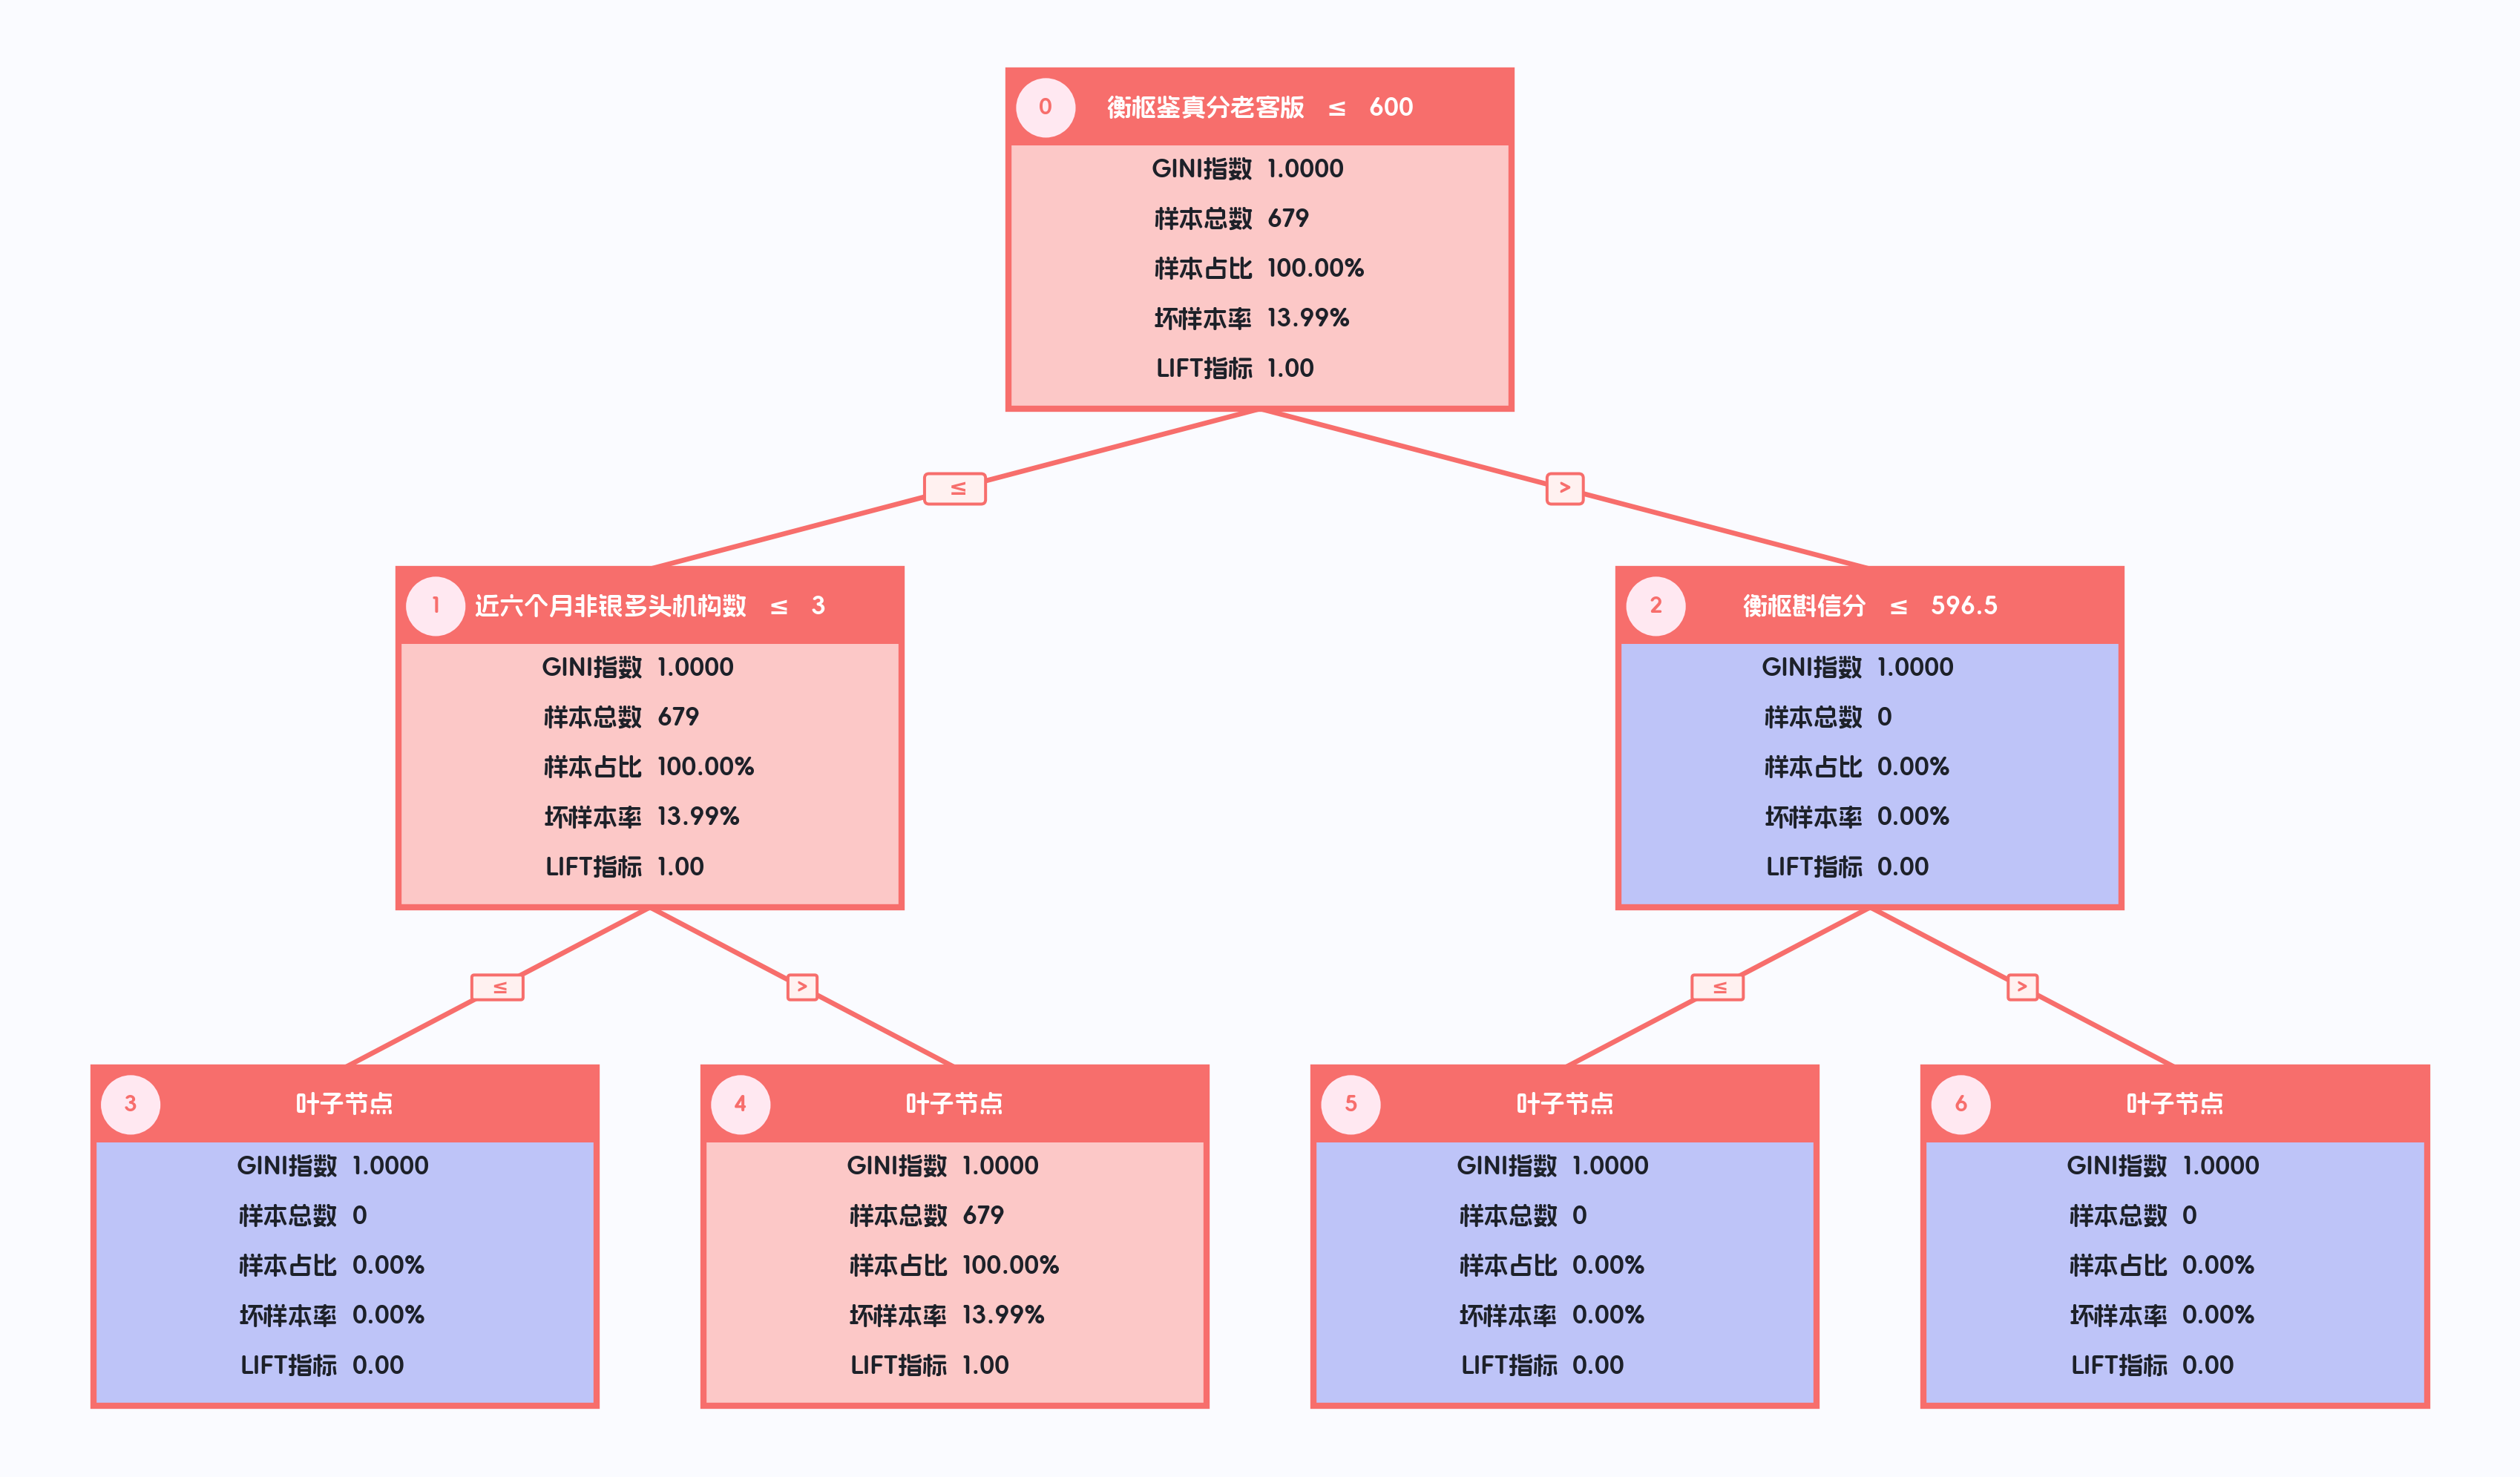

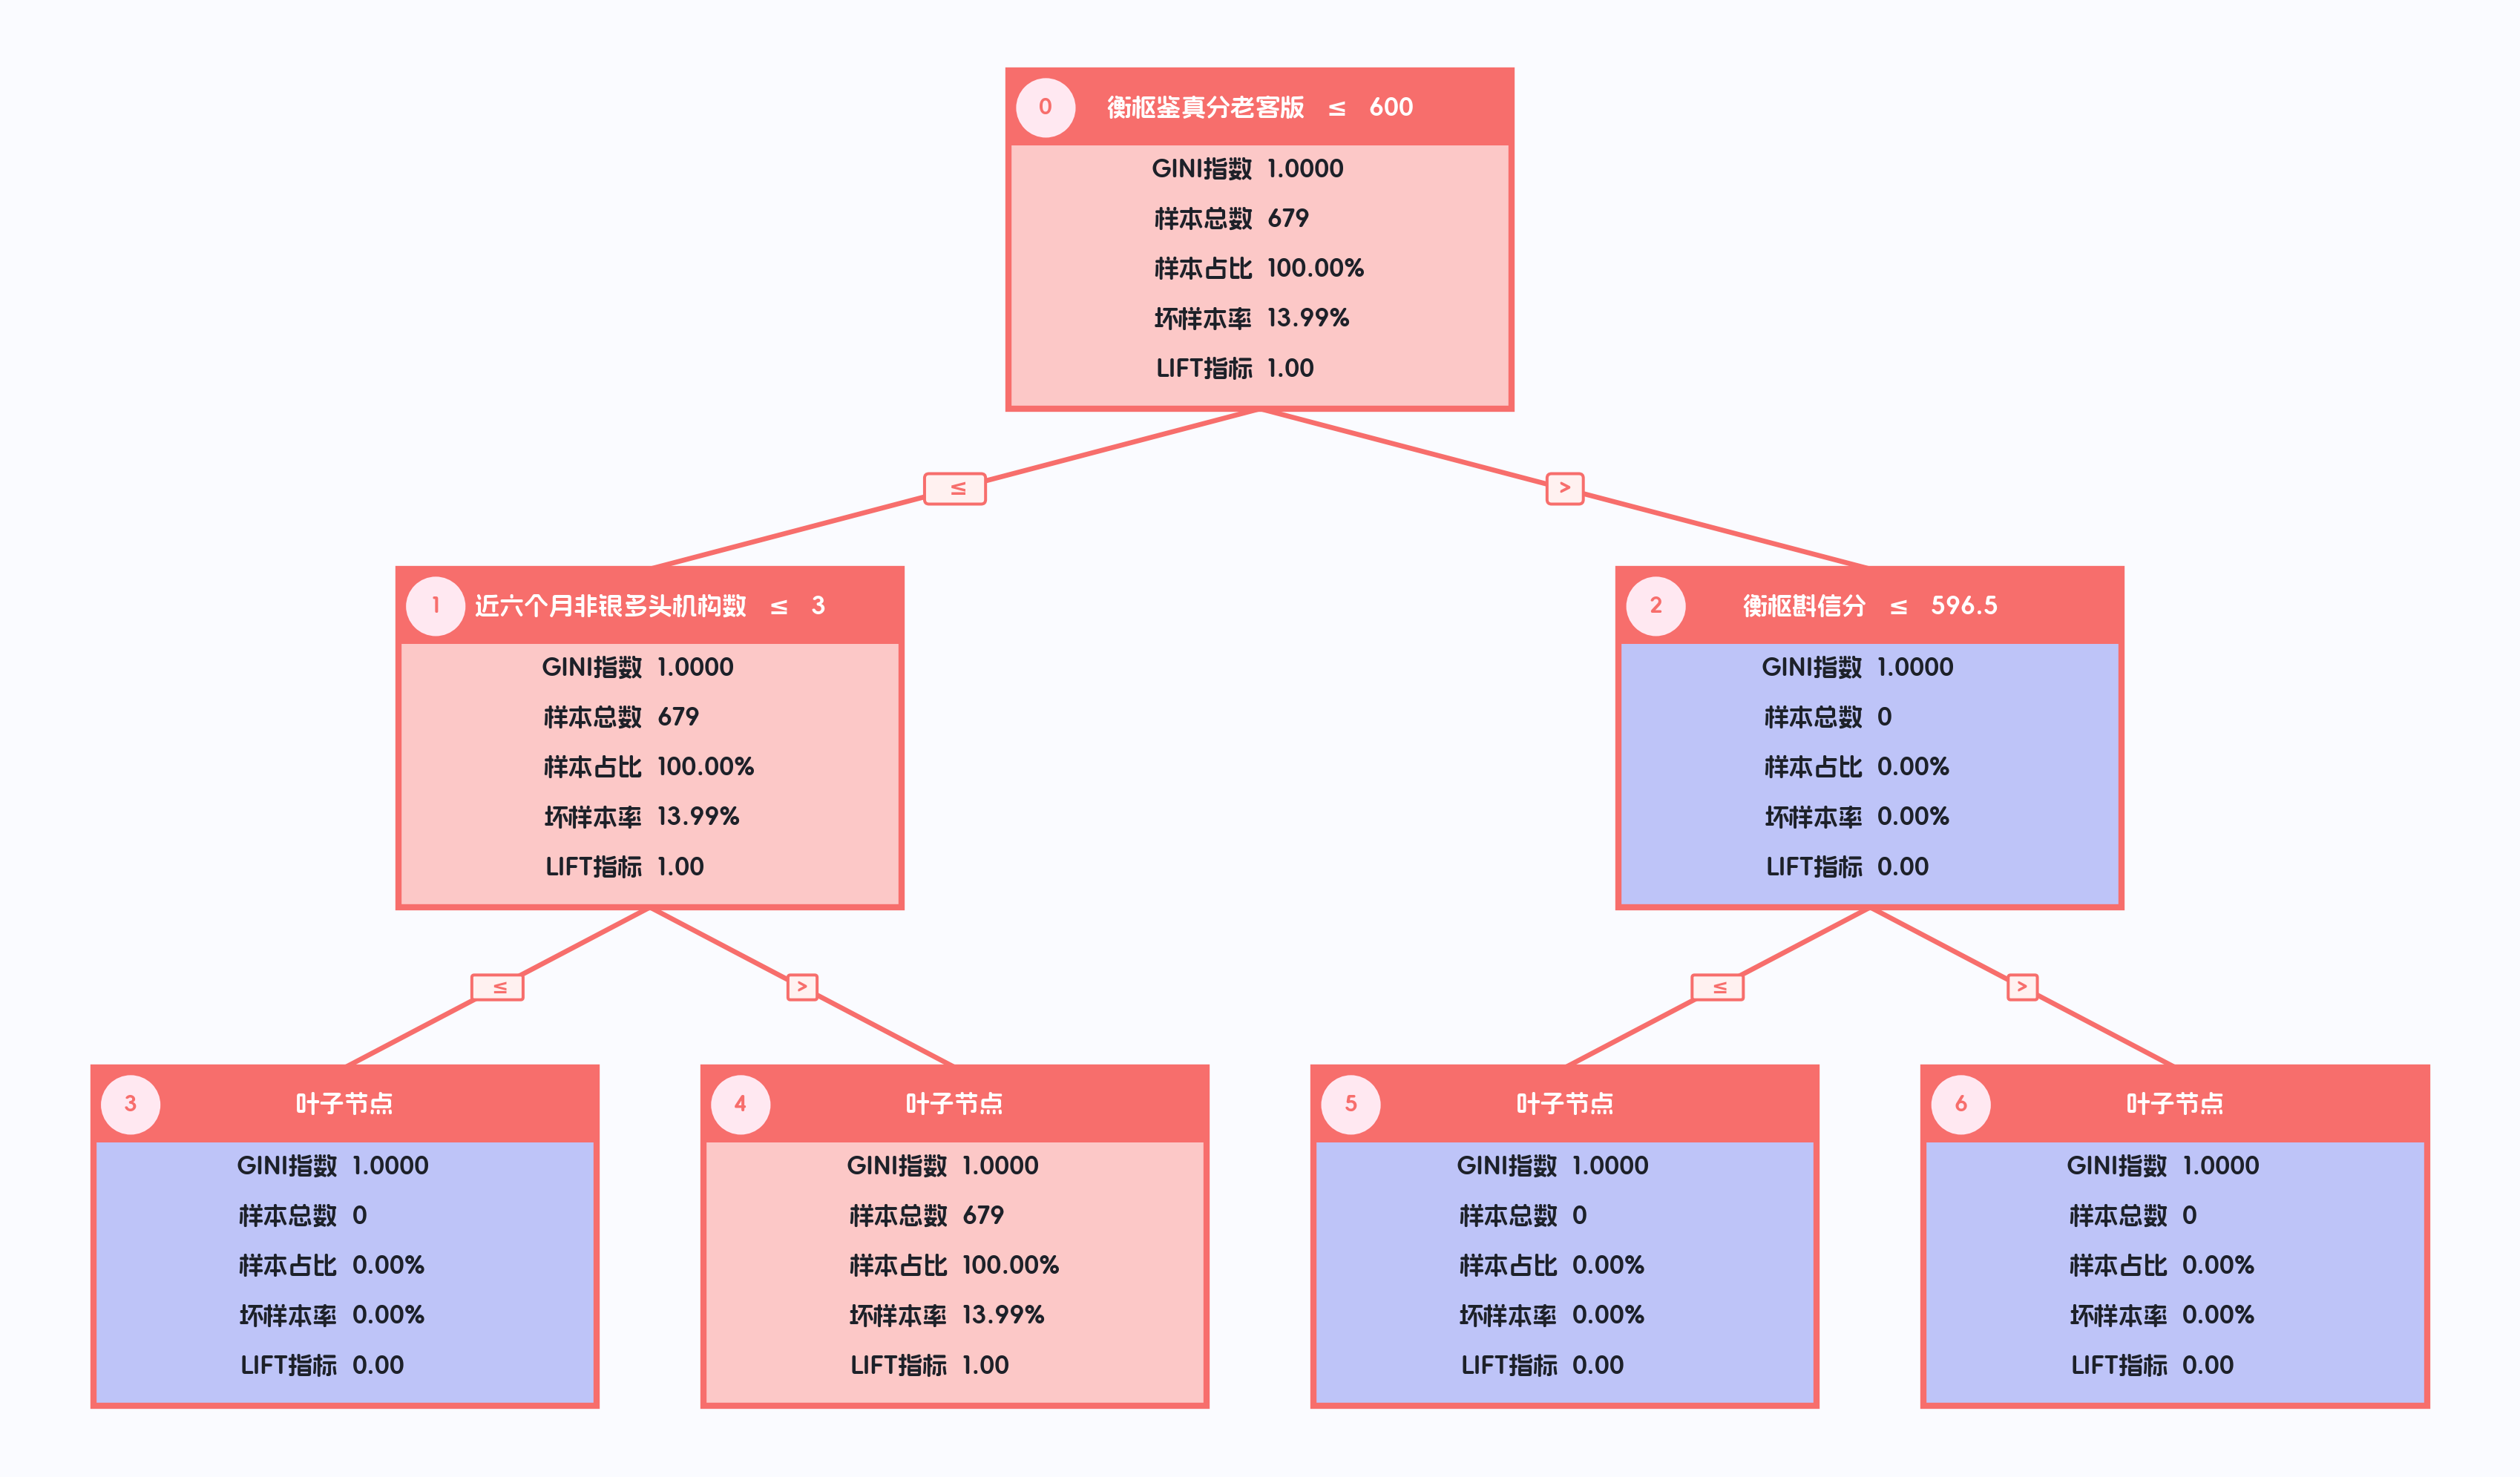

In [156]:
ext.get_rule_table(leaf_only=True)
ext.report({"训练集": df_train, "测试集": df_test}, target=target, leaf_only=True)
ext.plot(save="model_report/current_tree.png")


### 5. 把最终规则导出为 Rule 对象

上线前建议用 `get_rules()` 导出叶子规则，逐条 `Rule.report()` 验证，并通过 `RulesClassifier` 统一预测。


In [157]:
for rule in ext.get_rules():
    display(rule.report(df_test, target=target))

,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,(衡枢鉴真分老客版 <= 600.0) & (近六个月非银多头机构数 <= 3.0),命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8591,0.0000,0.0000,0.0000
1,验证规则,(衡枢鉴真分老客版 <= 600.0) & (近六个月非银多头机构数 <= 3.0),未命中,291,1.0000,250,1.0000,41,1.0000,0.1409,1.0000,1.0000,1.0000,0.1409,0.1409,1.0000,0.2470


,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,(衡枢鉴真分老客版 <= 600.0) & ((近六个月非银多头机构数 > 3.0) | (近六个月非银多头机构数 != 近六个月非银多头机构数)),命中,291,1.0000,250,1.0000,41,1.0000,0.1409,1.0000,1.0000,1.0000,0.1409,0.1409,1.0000,0.2470
1,验证规则,(衡枢鉴真分老客版 <= 600.0) & ((近六个月非银多头机构数 > 3.0) | (近六个月非银多头机构数 != 近六个月非银多头机构数)),未命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8591,0.0000,0.0000,0.0000


,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,(衡枢斟信分 <= 596.5) & ((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8591,0.0000,0.0000,0.0000
1,验证规则,(衡枢斟信分 <= 596.5) & ((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),未命中,291,1.0000,250,1.0000,41,1.0000,0.1409,1.0000,1.0000,1.0000,0.1409,0.1409,1.0000,0.2470


,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,((衡枢斟信分 > 596.5) | (衡枢斟信分 != 衡枢斟信分)) & ((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),命中,0,0.0000,0,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.8591,0.0000,0.0000,0.0000
1,验证规则,((衡枢斟信分 > 596.5) | (衡枢斟信分 != 衡枢斟信分)) & ((衡枢鉴真分老客版 > 600.0) | (衡枢鉴真分老客版 != 衡枢鉴真分老客版)),未命中,291,1.0000,250,1.0000,41,1.0000,0.1409,1.0000,1.0000,1.0000,0.1409,0.1409,1.0000,0.2470



### 6. 保留图和规则表作为策略档案

每一次策略版本都应该保存：

- 决策树图。
- 叶子规则表。
- 训练集/测试集效果。
- 多 DPD 口径效果。
- 金额口径效果。
- 最终规则表达式。

这对后续复盘、审计、策略迭代都很有价值。

## 结语

在金融信贷场景中，规则开发从来不是纯算法问题，也不是纯经验问题。

纯算法容易不可解释，纯经验容易缺少数据验证。真正好用的方法，应该让模型发现规律，让业务修正结构，让指标验证结果，让图表完成沟通。

`hscredit` 的 `ManualTreeExtractor` 把这条链路打通了：



这也是它区别于普通决策树工具的地方。它不是只给你一棵树，而是给你一个可解释、可调整、可评估、可落地的信贷规则挖掘工作流。

对于信贷行业从业者来说，这类工具的价值不只在建模效率，更在于让策略讨论变得有证据、让业务经验被量化、让规则上线前就能被充分验证。
